In [1]:
!pip install transformers transformer-lens torch scikit-learn matplotlib seaborn pandas tqdm

INFO: pip is looking at multiple versions of transformer-lens to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 117.7 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=05b36b573e41c4d4e40c40d920ddc0564bf1d28ad18a01266a1a768ed2a851e6
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: numpy
    Found existing insta

#HSCS and CKA



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import json
import torch
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple
import pandas as pd
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt
import gc

# ==========================================
# 1. MATHEMATICAL METRICS (ROBUST)
# ==========================================

def linear_cka(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Compute debiased linear CKA (Centered Kernel Alignment).
    ROBUST VERSION: Forces float64 to prevent overflow on FP16 data.
    """
    # Force Double Precision
    X = X.astype(np.float64)
    Y = Y.astype(np.float64)

    n = X.shape[0]

    # Center
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)

    # Gram matrices
    K = X @ X.T
    L = Y @ Y.T

    # Unbiased HSIC estimator
    K_bar = K - np.diag(np.diag(K))
    L_bar = L - np.diag(np.diag(L))

    hsic = (np.sum(K_bar * L_bar) - 2 * np.trace(K_bar @ L_bar) / (n - 2) +
            np.trace(K_bar) * np.trace(L_bar) / ((n - 1) * (n - 2)))
    hsic = hsic / (n * (n - 3))

    # Normalization terms
    var_x = (np.sum(K_bar ** 2) - 2 * np.trace(K_bar @ K_bar) / (n - 2) +
             (np.trace(K_bar) ** 2) / ((n - 1) * (n - 2))) / (n * (n - 3))
    var_y = (np.sum(L_bar ** 2) - 2 * np.trace(L_bar @ L_bar) / (n - 2) +
             (np.trace(L_bar) ** 2) / ((n - 1) * (n - 2))) / (n * (n - 3))

    var_x = max(var_x, 1e-16)
    var_y = max(var_y, 1e-16)

    return hsic / (np.sqrt(var_x * var_y))

# ==========================================
# 2. ANALYSIS CLASS FOR GPT-2 vs DistilGPT-2
# ==========================================

class GPT2vsDistilGPT2Analyzer:
    def __init__(
        self,
        output_dir: str = "gpt2_vs_distilgpt2_results",
        n_samples: int = 100,
        max_length: int = 256
    ):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True, parents=True)
        self.n_samples = n_samples
        self.max_length = max_length
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.gpt2_tokenizer = self.load_tokenizer("gpt2")

        print(f"Using device: {self.device}")

        # Model identifiers from HuggingFace
        self.gpt2_id = "gpt2"
        self.distilgpt2_id = "distilgpt2"

    def load_tokenizer(self, model_id: str):
        """Load tokenizer for specified model."""
        print(f"Loading tokenizer for {model_id}...")
        tokenizer = AutoTokenizer.from_pretrained(model_id)

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        return tokenizer

    # def load_tinystories_samples(self):
    #     """Load sample texts from TinyStories dataset."""
    #     print("Loading TinyStories dataset...")
    #     try:
    #         dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
    #         samples = []
    #         for i, example in enumerate(dataset):
    #             if i >= self.n_samples:
    #                 break
    #             samples.append(example["text"][:1000])
    #         return samples
    #     except Exception as e:
    #         print(f"Dataset load failed: {e}. Using dummy data.")
    #         return ["This is a test sentence." for _ in range(self.n_samples)]
    def load_tinystories_samples(
        #
        self,
        min_tokens: int = 64,
        max_tokens: int = 256,
        seed: int = 42):


      """Load sample texts from TinyStories dataset with token length filtering."""
      print("Loading TinyStories dataset...")
      random.seed(seed)

      try:
          dataset = load_dataset(
              "roneneldan/TinyStories",
              split="validation",
              streaming=True
          ).shuffle(seed=seed)

          samples = []
          stories_iter = iter(dataset)
          examined = 0

          print(f"Sampling {self.n_samples} prompts with token length in [{min_tokens}, {max_tokens}]...")

          while len(samples) < self.n_samples:
              try:
                  story = next(stories_iter)["text"]
                  examined += 1
                  if examined % 1000 == 0:
                      print(f"  Examined {examined} stories, found {len(samples)} so far...")

                  tokens = self.gpt2_tokenizer.encode(story, add_special_tokens=False)
                  if min_tokens <= len(tokens) <= max_tokens:
                      prompt = self.gpt2_tokenizer.decode(
                          tokens,
                          clean_up_tokenization_spaces=True
                      ).strip()
                      samples.append(prompt)

              except StopIteration:
                  print(f"⚠️ Only {len(samples)} stories available within the token range")
                  break

          print(f"✓ Sampled {len(samples)} prompts within token range")
          return samples

      except Exception as e:
          print(f"Dataset load failed: {e}. Using dummy data.")
          return ["This is a test sentence." for _ in range(self.n_samples)]

    def load_model(self, model_id: str):
        """Load model from HuggingFace."""
        try:
            print(f"Loading {model_id} model...")
            model = AutoModelForCausalLM.from_pretrained(model_id)
            model.to(self.device)
            model.eval()

            # Print model info
            num_params = sum(p.numel() for p in model.parameters())
            print(f"   Model loaded: {num_params:,} parameters")

            return model
        except Exception as e:
            print(f"   Error loading model: {e}")
            return None

    def get_hidden_states(
        self,
        model,
        tokenizer,
        input_texts: List[str],
        batch_size: int = 8
    ) -> Dict[int, torch.Tensor]:
        """Extract hidden states from all layers."""
        if model is None:
            raise ValueError("Model is None")

        model_device = next(model.parameters()).device
        all_layer_states = {}

        for i in tqdm(range(0, len(input_texts), batch_size), desc="   Extracting states"):
            batch_texts = input_texts[i:i+batch_size]

            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=self.max_length
            ).to(model_device)

            with torch.no_grad():
                outputs = model(**inputs, output_hidden_states=True)

            hidden_states = outputs.hidden_states

            if not all_layer_states:
                all_layer_states = {idx: [] for idx in range(len(hidden_states))}

            mask = inputs.attention_mask.unsqueeze(-1)

            for layer_idx, layer_tensor in enumerate(hidden_states):
                layer_tensor = layer_tensor * mask
                sum_embeddings = layer_tensor.sum(dim=1)
                token_counts = mask.sum(dim=1).clamp(min=1)
                avg_embeddings = sum_embeddings / token_counts
                all_layer_states[layer_idx].append(avg_embeddings.cpu())

            del outputs, inputs

        final_states = {}
        for idx, batches in all_layer_states.items():
            final_states[idx] = torch.cat(batches, dim=0)

        return final_states

    def compare_models(
        self,
        gpt2_states: Dict[int, torch.Tensor],
        distilgpt2_states: Dict[int, torch.Tensor],
        comparison_type: str = "layer_to_layer"
    ) -> Dict:
        """
        Compare hidden states between GPT-2 and DistilGPT-2.

        comparison_type options:
        - "layer_to_layer": Compare layers at same indices (where they exist)
        - "proportional": Map DistilGPT-2 layers proportionally to GPT-2 layers
        """
        print(f"\nComparing models (method: {comparison_type})...")
        print(f"GPT-2 layers: {len(gpt2_states)}")
        print(f"DistilGPT-2 layers: {len(distilgpt2_states)}")

        results = {
            "comparison_type": comparison_type,
            "gpt2_n_layers": len(gpt2_states),
            "distilgpt2_n_layers": len(distilgpt2_states),
            "gpt2_d_model": gpt2_states[0].shape[1],
            "distilgpt2_d_model": distilgpt2_states[0].shape[1],
            "layer_similarities": {},
            "cka_similarity": {}
        }

        if comparison_type == "layer_to_layer":
            # Compare layers with same indices
            common_layers = sorted(list(set(gpt2_states.keys()) & set(distilgpt2_states.keys())))
            layer_pairs = [(i, i) for i in common_layers]

        elif comparison_type == "proportional":
            # Map DistilGPT-2 layers proportionally to GPT-2 layers
            n_gpt2 = len(gpt2_states)
            n_distil = len(distilgpt2_states)

            layer_pairs = []
            for distil_idx in range(n_distil):
                # Map distil layer to corresponding GPT-2 layer
                gpt2_idx = int(distil_idx * (n_gpt2 - 1) / (n_distil - 1))
                layer_pairs.append((gpt2_idx, distil_idx))

        print(f"Comparing {len(layer_pairs)} layer pairs...")

        for gpt2_idx, distil_idx in layer_pairs:
            gpt2_vec = gpt2_states[gpt2_idx]
            distil_vec = distilgpt2_states[distil_idx]

            # Handle dimension mismatch if any
            if gpt2_vec.shape[1] != distil_vec.shape[1]:
                print(f"   Warning: Dimension mismatch at layers {gpt2_idx}/{distil_idx}")
                print(f"   GPT-2: {gpt2_vec.shape[1]}, DistilGPT-2: {distil_vec.shape[1]}")
                # Project to common dimension (PCA-style)
                min_dim = min(gpt2_vec.shape[1], distil_vec.shape[1])
                gpt2_vec = gpt2_vec[:, :min_dim]
                distil_vec = distil_vec[:, :min_dim]

            # 1. Cosine Similarity
            g_norm = torch.nn.functional.normalize(gpt2_vec, p=2, dim=1)
            d_norm = torch.nn.functional.normalize(distil_vec, p=2, dim=1)
            cosine_sim = (g_norm * d_norm).sum(dim=1).numpy()

            layer_key = f"gpt2_{gpt2_idx}_distil_{distil_idx}"
            results["layer_similarities"][layer_key] = {
                "gpt2_layer": gpt2_idx,
                "distil_layer": distil_idx,
                "mean": float(np.mean(cosine_sim)),
                "std": float(np.std(cosine_sim)),
                "median": float(np.median(cosine_sim)),
                "q25": float(np.percentile(cosine_sim, 25)),
                "q75": float(np.percentile(cosine_sim, 75)),
                "raw_similarities": cosine_sim.tolist()
            }

            # 2. CKA Similarity
            cka_score = linear_cka(gpt2_vec.numpy(), distil_vec.numpy())
            results["cka_similarity"][layer_key] = float(cka_score)

        return results

    def visualize_comparison(self, results: Dict, save_dir: Path):
        """Create comprehensive visualizations."""
        layer_sims = results["layer_similarities"]

        # Extract data
        pairs = []
        gpt2_layers = []
        distil_layers = []
        means = []
        stds = []
        medians = []
        q25 = []
        q75 = []
        cka_scores = []

        for key in sorted(layer_sims.keys(), key=lambda x: layer_sims[x]["gpt2_layer"]):
            sim = layer_sims[key]
            gpt2_layers.append(sim["gpt2_layer"])
            distil_layers.append(sim["distil_layer"])
            means.append(sim["mean"])
            stds.append(sim["std"])
            medians.append(sim["median"])
            q25.append(sim["q25"])
            q75.append(sim["q75"])
            cka_scores.append(results["cka_similarity"][key])
            pairs.append(f"{sim['gpt2_layer']}/{sim['distil_layer']}")

        # Create figure
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle("GPT-2 vs DistilGPT-2 Hidden State Similarity", fontsize=16)

        # Plot 1: Mean similarity with std
        ax1 = axes[0, 0]
        x_pos = np.arange(len(means))
        ax1.plot(x_pos, means, marker='o', linewidth=2, label='Mean Cosine Sim')
        ax1.fill_between(x_pos,
                         np.array(means) - np.array(stds),
                         np.array(means) + np.array(stds),
                         alpha=0.3)
        ax1.set_xlabel("Layer Pair Index")
        ax1.set_ylabel("Cosine Similarity")
        ax1.set_title("Mean Similarity per Layer Pair")
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        ax1.set_ylim([-0.1, 1.1])

        # Plot 2: CKA scores
        ax2 = axes[0, 1]
        ax2.plot(x_pos, cka_scores, marker='s', linewidth=2, color='green', label='CKA')
        ax2.set_xlabel("Layer Pair Index")
        ax2.set_ylabel("CKA Score")
        ax2.set_title("CKA Similarity per Layer Pair")
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        ax2.set_ylim([-0.1, 1.1])

        # Plot 3: Layer mapping visualization
        ax3 = axes[0, 2]
        ax3.scatter(gpt2_layers, distil_layers, c=means, cmap='viridis', s=100, alpha=0.7)
        ax3.plot(gpt2_layers, distil_layers, 'r--', alpha=0.3)
        ax3.set_xlabel("GPT-2 Layer")
        ax3.set_ylabel("DistilGPT-2 Layer")
        ax3.set_title("Layer Mapping (colored by similarity)")
        ax3.grid(True, alpha=0.3)
        cbar = plt.colorbar(ax3.collections[0], ax=ax3)
        cbar.set_label("Cosine Similarity")

        # Plot 4: Distribution for selected pairs
        ax4 = axes[1, 0]
        n_pairs = len(pairs)
        pairs_to_show_idx = []
        if n_pairs > 0: pairs_to_show_idx.append(0)
        if n_pairs > 2: pairs_to_show_idx.append(n_pairs//2)
        if n_pairs > 1: pairs_to_show_idx.append(-1)

        for idx in pairs_to_show_idx:
            key = list(layer_sims.keys())[idx]
            raw_sims = layer_sims[key]["raw_similarities"]
            ax4.hist(raw_sims, bins=50, alpha=0.5, label=f"{pairs[idx]}")

        ax4.set_xlabel("Cosine Similarity")
        ax4.set_ylabel("Frequency")
        ax4.set_title("Similarity Distributions (Selected Pairs)")
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # Plot 5: Median with quartiles
        ax5 = axes[1, 1]
        ax5.plot(x_pos, medians, marker='s', linewidth=2, label='Median', color='orange')
        ax5.fill_between(x_pos, q25, q75, alpha=0.3, color='orange')
        ax5.set_xlabel("Layer Pair Index")
        ax5.set_ylabel("Cosine Similarity")
        ax5.set_title("Median Similarity (with IQR)")
        ax5.grid(True, alpha=0.3)
        ax5.legend()
        ax5.set_ylim([-0.1, 1.1])

        # Plot 6: Combined comparison
        ax6 = axes[1, 2]
        ax6.plot(x_pos, means, marker='o', label='Cosine (mean)', linewidth=2)
        ax6.plot(x_pos, cka_scores, marker='s', label='CKA', linewidth=2)
        ax6.set_xlabel("Layer Pair Index")
        ax6.set_ylabel("Similarity Score")
        ax6.set_title("Cosine vs CKA Comparison")
        ax6.grid(True, alpha=0.3)
        ax6.legend()
        ax6.set_ylim([-0.1, 1.1])

        plt.tight_layout()
        plt.savefig(save_dir / "comparison_visualization.png", dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved visualization to {save_dir / 'comparison_visualization.png'}")

    def create_summary(self, results: Dict):
        """Create summary statistics."""
        print("\n" + "="*60)
        print("COMPARISON SUMMARY")
        print("="*60)

        layer_sims = results["layer_similarities"]
        cka_sims = results["cka_similarity"]

        means = [layer_sims[k]["mean"] for k in layer_sims.keys()]
        medians = [layer_sims[k]["median"] for k in layer_sims.keys()]
        cka_values = list(cka_sims.values())

        n = len(means)
        q1 = n // 4
        q3 = 3 * n // 4

        summary = {
            "comparison_type": results["comparison_type"],
            "gpt2_layers": results["gpt2_n_layers"],
            "distilgpt2_layers": results["distilgpt2_n_layers"],
            "gpt2_d_model": results["gpt2_d_model"],
            "distilgpt2_d_model": results["distilgpt2_d_model"],
            "n_layer_pairs_compared": len(means),

            "overall_mean_cosine": np.mean(means),
            "overall_median_cosine": np.median(medians),
            "overall_std_cosine": np.std(means),
            "min_cosine": np.min(means),
            "max_cosine": np.max(means),

            "early_layers_cosine": np.mean(means[:q1]) if q1 > 0 else None,
            "middle_layers_cosine": np.mean(means[q1:q3]) if q3 > q1 else None,
            "late_layers_cosine": np.mean(means[q3:]) if len(means) > q3 else None,

            "overall_mean_cka": np.mean(cka_values),
            "overall_median_cka": np.median(cka_values),
            "overall_std_cka": np.std(cka_values),
            "min_cka": np.min(cka_values),
            "max_cka": np.max(cka_values),

            "early_layers_cka": np.mean(cka_values[:q1]) if q1 > 0 else None,
            "middle_layers_cka": np.mean(cka_values[q1:q3]) if q3 > q1 else None,
            "late_layers_cka": np.mean(cka_values[q3:]) if len(cka_values) > q3 else None,
        }

        # Print summary
        print(f"\nComparison Type: {summary['comparison_type']}")
        print(f"GPT-2: {summary['gpt2_layers']} layers, d_model={summary['gpt2_d_model']}")
        print(f"DistilGPT-2: {summary['distilgpt2_layers']} layers, d_model={summary['distilgpt2_d_model']}")
        print(f"Layer pairs compared: {summary['n_layer_pairs_compared']}")

        print(f"\n--- Cosine Similarity ---")
        print(f"Overall Mean: {summary['overall_mean_cosine']:.4f} ± {summary['overall_std_cosine']:.4f}")
        print(f"Overall Median: {summary['overall_median_cosine']:.4f}")
        print(f"Range: [{summary['min_cosine']:.4f}, {summary['max_cosine']:.4f}]")

        if summary['early_layers_cosine'] is not None:
            print(f"\nBy Depth:")
            print(f"  Early layers:  {summary['early_layers_cosine']:.4f}")
            print(f"  Middle layers: {summary['middle_layers_cosine']:.4f}")
            print(f"  Late layers:   {summary['late_layers_cosine']:.4f}")

        print(f"\n--- CKA Similarity ---")
        print(f"Overall Mean: {summary['overall_mean_cka']:.4f} ± {summary['overall_std_cka']:.4f}")
        print(f"Overall Median: {summary['overall_median_cka']:.4f}")
        print(f"Range: [{summary['min_cka']:.4f}, {summary['max_cka']:.4f}]")

        if summary['early_layers_cka'] is not None:
            print(f"\nBy Depth:")
            print(f"  Early layers:  {summary['early_layers_cka']:.4f}")
            print(f"  Middle layers: {summary['middle_layers_cka']:.4f}")
            print(f"  Late layers:   {summary['late_layers_cka']:.4f}")

        # Save summary
        with open(self.output_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        print(f"\n✓ Summary saved to {self.output_dir / 'summary.json'}")

        return summary



    def run_analysis(self, comparison_type: str = "proportional"):
        """
        Run full comparison analysis.

        Args:
            comparison_type: "layer_to_layer" or "proportional"
        """
        print("="*60)
        print("GPT-2 vs DistilGPT-2 Analysis")
        print("="*60)

        # Load samples
        samples = self.load_tinystories_samples()

        # Load GPT-2
        print(f"\n--- Loading GPT-2 ---")
        gpt2_tokenizer = self.load_tokenizer(self.gpt2_id)
        gpt2_model = self.load_model(self.gpt2_id)
        if gpt2_model is None:
            print("CRITICAL ERROR: Could not load GPT-2")
            return

        gpt2_states = self.get_hidden_states(gpt2_model, gpt2_tokenizer, samples)
        del gpt2_model
        torch.cuda.empty_cache()
        gc.collect()

        # Load DistilGPT-2
        print(f"\n--- Loading DistilGPT-2 ---")
        distilgpt2_tokenizer = self.load_tokenizer(self.distilgpt2_id)
        distilgpt2_model = self.load_model(self.distilgpt2_id)
        if distilgpt2_model is None:
            print("CRITICAL ERROR: Could not load DistilGPT-2")
            return

        distilgpt2_states = self.get_hidden_states(
            distilgpt2_model,
            distilgpt2_tokenizer,
            samples
        )
        del distilgpt2_model
        torch.cuda.empty_cache()
        gc.collect()

        # Compare models
        results = self.compare_models(
            gpt2_states,
            distilgpt2_states,
            comparison_type=comparison_type
        )

        # Save raw results
        save_results = results.copy()
        save_results["layer_similarities"] = {
            k: {k2: v2 for k2, v2 in v.items() if k2 != "raw_similarities"}
            for k, v in results["layer_similarities"].items()
        }

        with open(self.output_dir / "detailed_results.json", "w") as f:
            json.dump(save_results, f, indent=2)

        # Save raw similarities separately
        np.save(
            self.output_dir / "raw_similarities.npy",
            {k: v["raw_similarities"] for k, v in results["layer_similarities"].items()}
        )

        # Visualize
        self.visualize_comparison(results, self.output_dir)

        # Create summary
        summary = self.create_summary(results)

        print("\n" + "="*60)
        print("Analysis Complete!")
    #
    def _run_single(self, samples: List[str], comparison_type: str) -> Dict:
      """Run a single analysis pass on the given samples."""
      gpt2_tokenizer = self.load_tokenizer(self.gpt2_id)
      gpt2_model = self.load_model(self.gpt2_id)
      gpt2_states = self.get_hidden_states(gpt2_model, gpt2_tokenizer, samples)
      del gpt2_model
      torch.cuda.empty_cache()
      gc.collect()

      distilgpt2_tokenizer = self.load_tokenizer(self.distilgpt2_id)
      distilgpt2_model = self.load_model(self.distilgpt2_id)
      distilgpt2_states = self.get_hidden_states(distilgpt2_model, distilgpt2_tokenizer, samples)
      del distilgpt2_model
      torch.cuda.empty_cache()
      gc.collect()

      return self.compare_models(gpt2_states, distilgpt2_states, comparison_type)

    def _report_ci(self, all_cka_results, all_cos_results):
      #
      print("\n--- CKA: Mean ± Std across seeds ---")
      for layer_key in sorted(all_cka_results.keys()):
          vals = np.array(all_cka_results[layer_key])
          print(f"  {layer_key}: {vals.mean():.4f} ± {vals.std():.4f}")

      print("\n--- Cosine: Mean ± Std across seeds ---")
      for layer_key in sorted(all_cos_results.keys()):
          vals = np.array(all_cos_results[layer_key])
          print(f"  {layer_key}: {vals.mean():.4f} ± {vals.std():.4f}")

      # Save to JSON
      summary = {
          "seeds": list(all_cka_results.keys()),
          "cka": {k: {"mean": float(np.mean(v)), "std": float(np.std(v))}
                  for k, v in all_cka_results.items()},
          "cosine": {k: {"mean": float(np.mean(v)), "std": float(np.std(v))}
                    for k, v in all_cos_results.items()}
      }
      with open(self.output_dir / "ci_summary.json", "w") as f:
          json.dump(summary, f, indent=2)
      print(f"\n✓ Saved CI summary to {self.output_dir / 'ci_summary.json'}")


    def run_multi_seed_analysis(
        #
        self,
        seeds: List[int] = [42, 123, 7],
        comparison_type: str = "proportional"):
      #
      all_cka_results = {}   # layer_key -> list of CKA scores across seeds
      all_cos_results = {}   # layer_key -> list of mean cosine scores across seeds

      for seed in seeds:
          print(f"\n{'='*60}")
          print(f"RUNNING SEED {seed}")
          print(f"{'='*60}")

          # Set seed everywhere
          torch.manual_seed(seed)
          np.random.seed(seed)
          random.seed(seed)

          # Sample differently per seed
          samples = self.load_tinystories_samples(seed=seed)

          # ... rest of your existing run_analysis logic ...
          results = self._run_single(samples, comparison_type)

          # Accumulate
          for layer_key, cka_val in results["cka_similarity"].items():
              all_cka_results.setdefault(layer_key, []).append(cka_val)
          for layer_key, sim in results["layer_similarities"].items():
             all_cos_results.setdefault(layer_key, []).append(sim["mean"])

      # Compute mean ± std across seeds
      self._report_ci(all_cka_results, all_cos_results)


In [ ]:
analyzer = GPT2vsDistilGPT2Analyzer(
    output_dir="/content/drive/MyDrive/IRP/GPT-2/gpt2_vs_distilgpt2_results_hscs_cka_publication",
    n_samples=1000,
    max_length=256
)

for comparison_type in ["proportional", "layer_to_layer"]:
    analyzer.output_dir = Path(f"/content/drive/MyDrive/IRP/GPT-2/gpt2_vs_distilgpt2_results_hscs_cka_publication_{comparison_type}")
    analyzer.output_dir.mkdir(exist_ok=True, parents=True)
    analyzer.run_analysis(comparison_type=comparison_type)

Loading tokenizer for gpt2...
Using device: cuda
GPT-2 vs DistilGPT-2 Analysis
Loading TinyStories dataset...
Sampling 1000 prompts with token length in [64, 256]...


Token indices sequence length is longer than the specified maximum sequence length for this model (1045 > 1024). Running this sequence through the model will result in indexing errors


  Examined 1000 stories, found 938 so far...
✓ Sampled 1000 prompts within token range

--- Loading GPT-2 ---
Loading tokenizer for gpt2...
Loading gpt2 model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Model loaded: 81,912,576 parameters


   Extracting states: 100%|██████████| 125/125 [00:05<00:00, 24.10it/s]



Comparing models (method: layer_to_layer)...
GPT-2 layers: 13
DistilGPT-2 layers: 7
Comparing 7 layer pairs...
✓ Saved visualization to /content/drive/MyDrive/IRP/GPT-2/gpt2_vs_distilgpt2_results_hscs_cka_publication_layer_to_layer/comparison_visualization.png

COMPARISON SUMMARY

Comparison Type: layer_to_layer
GPT-2: 13 layers, d_model=768
DistilGPT-2: 7 layers, d_model=768
Layer pairs compared: 7

--- Cosine Similarity ---
Overall Mean: 0.7842 ± 0.3095
Overall Median: 0.9268
Range: [0.0574, 0.9977]

By Depth:
  Early layers:  0.9977
  Middle layers: 0.9304
  Late layers:   0.3851

--- CKA Similarity ---
Overall Mean: 0.7515 ± 0.2976
Overall Median: 0.9213
Range: [0.1654, 0.9998]

By Depth:
  Early layers:  0.9998
  Middle layers: 0.9082
  Late layers:   0.3138

✓ Summary saved to /content/drive/MyDrive/IRP/GPT-2/gpt2_vs_distilgpt2_results_hscs_cka_publication_layer_to_layer/summary.json

Analysis Complete!


#Logit Lens

Loading tokenizer...
Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  GPT-2 loaded: 124,439,808 parameters, 12 layers
Loading DistilGPT-2...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

✓ Sampled 1000 prompts within token range
✓ Saved prompts to gpt2_vs_distilgpt2_logit_lens_results/sampled_prompts.txt

LOGIT LENS ANALYSIS: PROPORTIONAL COMPARISON

Processing 1000 prompts in 250 batches...
Comparison type: proportional

ANALYZING GPT-2 (12 layers)


GPT-2 batches:   0%|          | 0/250 [00:00<?, ?it/s]

✓ GPT-2 analysis complete

ANALYZING DistilGPT-2 (6 layers)


DistilGPT-2 batches:   0%|          | 0/250 [00:00<?, ?it/s]

✓ DistilGPT-2 analysis complete

CREATING LAYER MAPPINGS

Proportional mapping:
  Emb
  D0→G0
  D1→G2
  D2→G4
  D3→G6
  D4→G8
  D5→G11

✓ Saved results to gpt2_vs_distilgpt2_logit_lens_results/proportional

CREATING VISUALIZATIONS (proportional)
✓ Saved to gpt2_vs_distilgpt2_logit_lens_results/proportional/logit_lens_accuracy.png


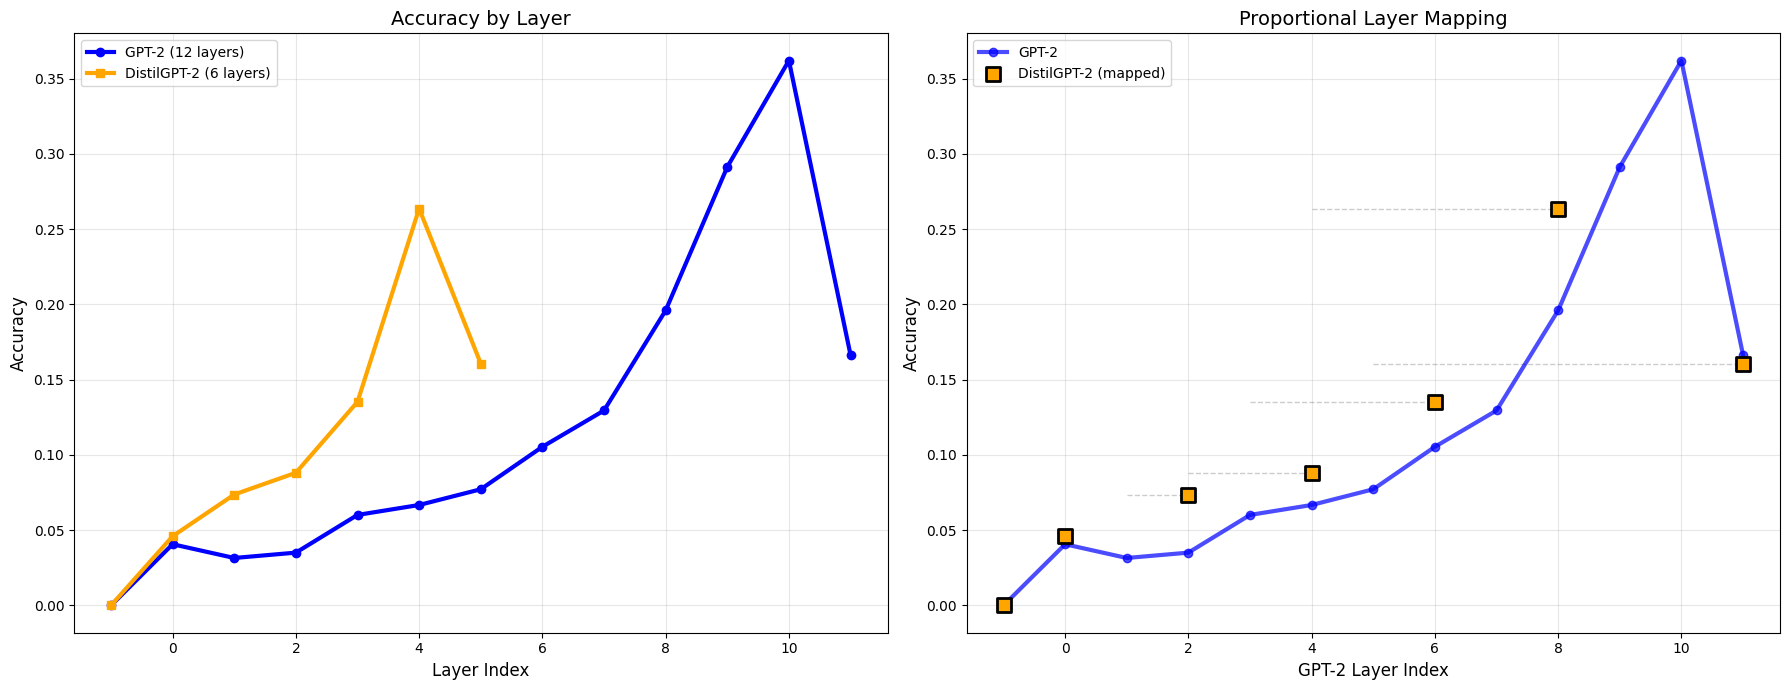

✓ Saved to gpt2_vs_distilgpt2_logit_lens_results/proportional/logit_lens_relative_accuracy.png


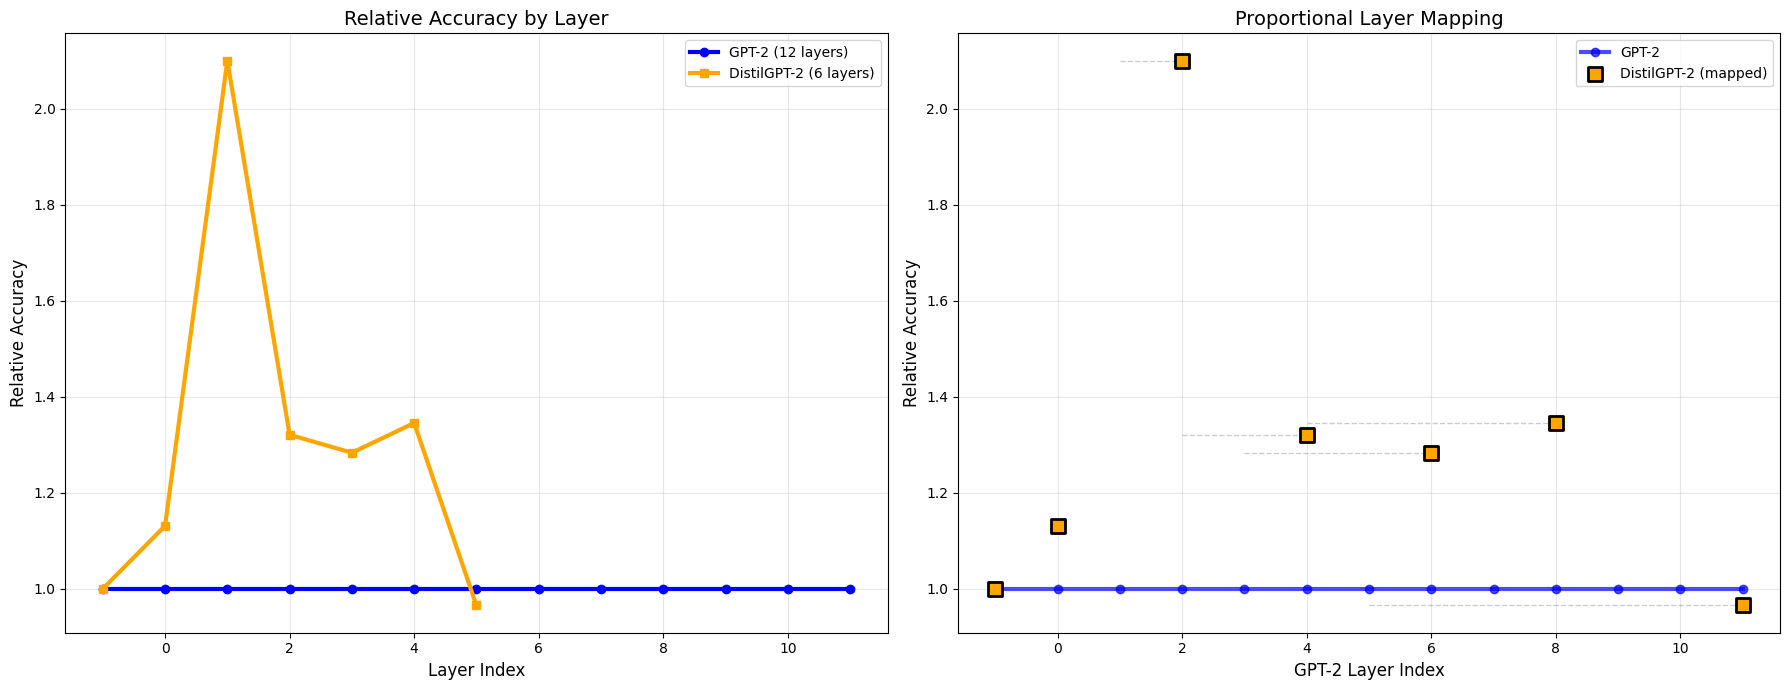

✓ Saved to gpt2_vs_distilgpt2_logit_lens_results/proportional/attention_analysis.png


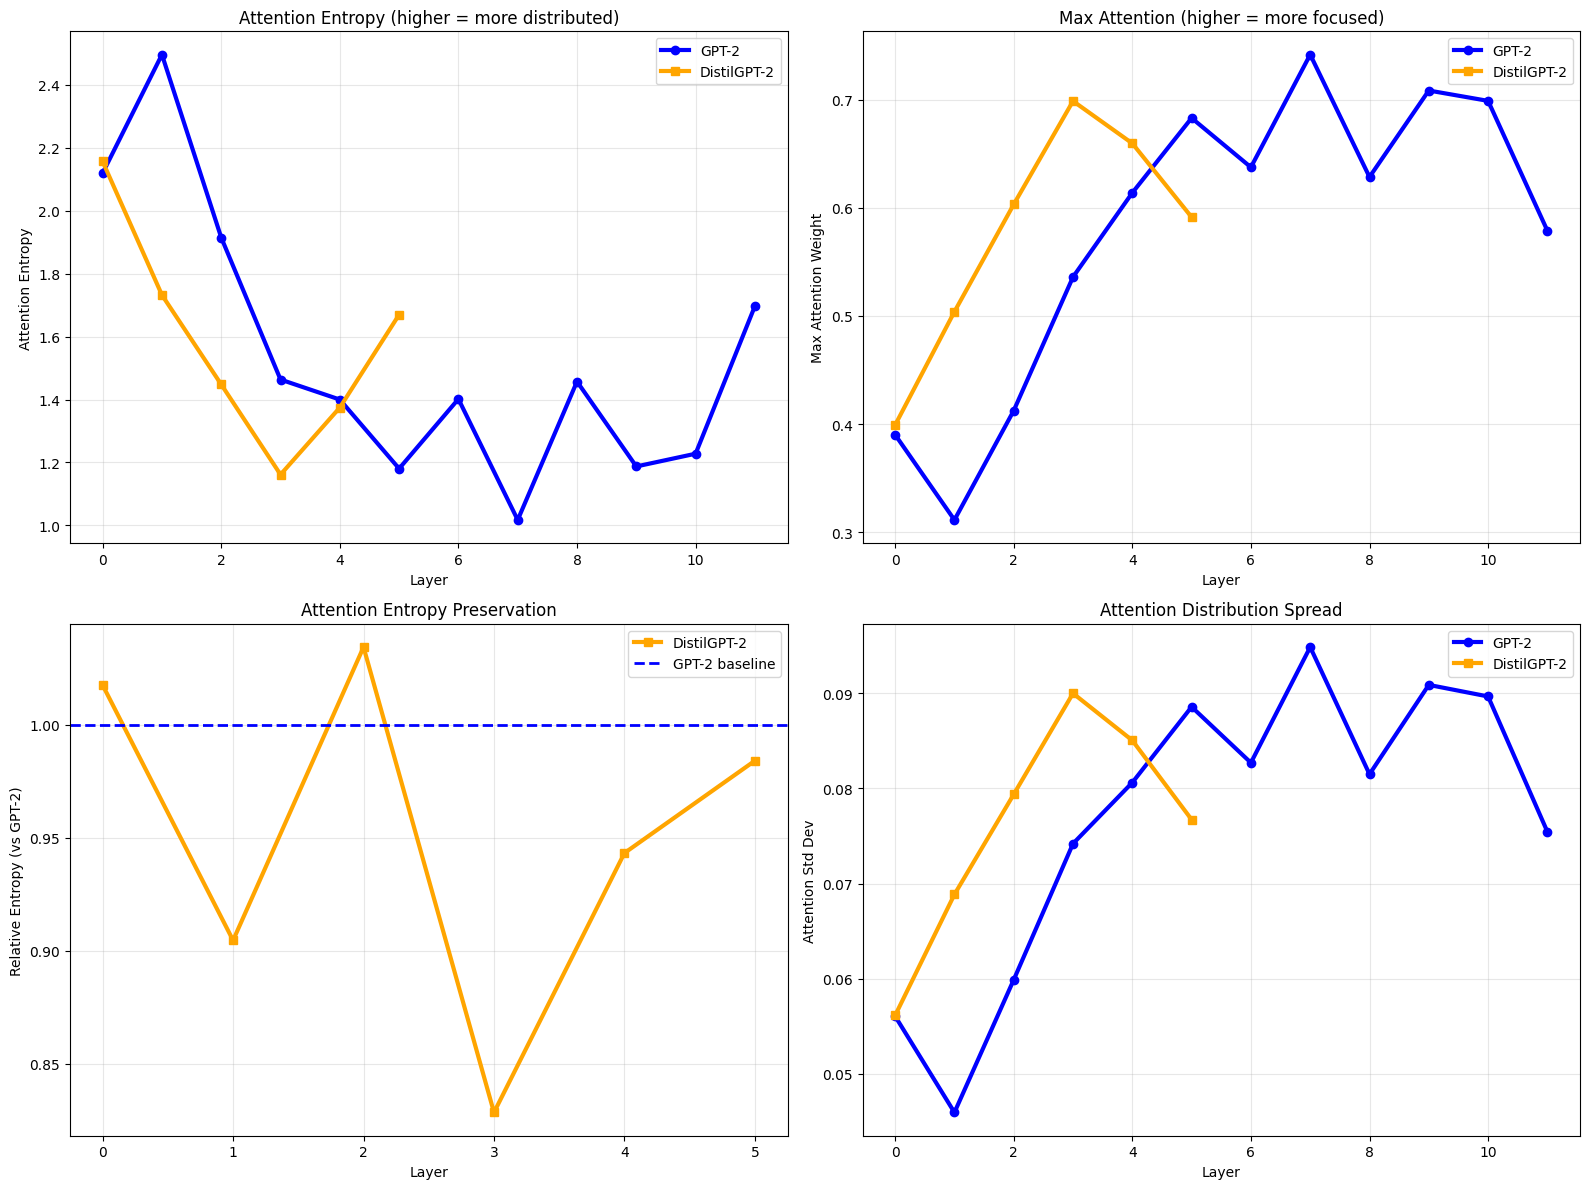


COMPARISON SUMMARY: GPT-2 vs DistilGPT-2

--- ACCURACY METRICS ---

GPT-2:
  Mean accuracy: 0.1202
  Min accuracy:  0.0000
  Max accuracy:  0.3620

DistilGPT-2:
  Mean accuracy: 0.1097
  Min accuracy:  0.0000
  Max accuracy:  0.2637

--- LAYER-WISE COMPARISON ---
DistilGPT-2 Layer    → GPT-2 Layer   Accuracy Diff   Relative Acc   
-----------------------------------------------------------------
Emb                  → L-1.0         +0.0000          1.0000
L0                   → L0.0          -0.0053          1.1311
L1                   → L2.0          -0.0386          2.0999
L2                   → L4.0          -0.0214          1.3207
L3                   → L6.0          -0.0299          1.2833
L4                   → L8.0          -0.0677          1.3453
L5                   → L11.0         +0.0058          0.9653

--- ATTENTION METRICS ---

GPT-2:
  Mean entropy:      1.5470
  Mean max attention: 0.5785

DistilGPT-2:
  Mean entropy:      1.5905
  Mean max attention: 0.5760

LOGIT LEN

GPT-2 batches:   0%|          | 0/250 [00:00<?, ?it/s]

✓ GPT-2 analysis complete

ANALYZING DistilGPT-2 (6 layers)


DistilGPT-2 batches:   0%|          | 0/250 [00:00<?, ?it/s]

✓ DistilGPT-2 analysis complete

CREATING LAYER MAPPINGS

Layer-to-layer mapping (layers 0-5 only):
  Emb
  L0
  L1
  L2
  L3
  L4
  L5

✓ Saved results to gpt2_vs_distilgpt2_logit_lens_results/layer_to_layer

CREATING VISUALIZATIONS (layer_to_layer)
✓ Saved to gpt2_vs_distilgpt2_logit_lens_results/layer_to_layer/logit_lens_accuracy.png


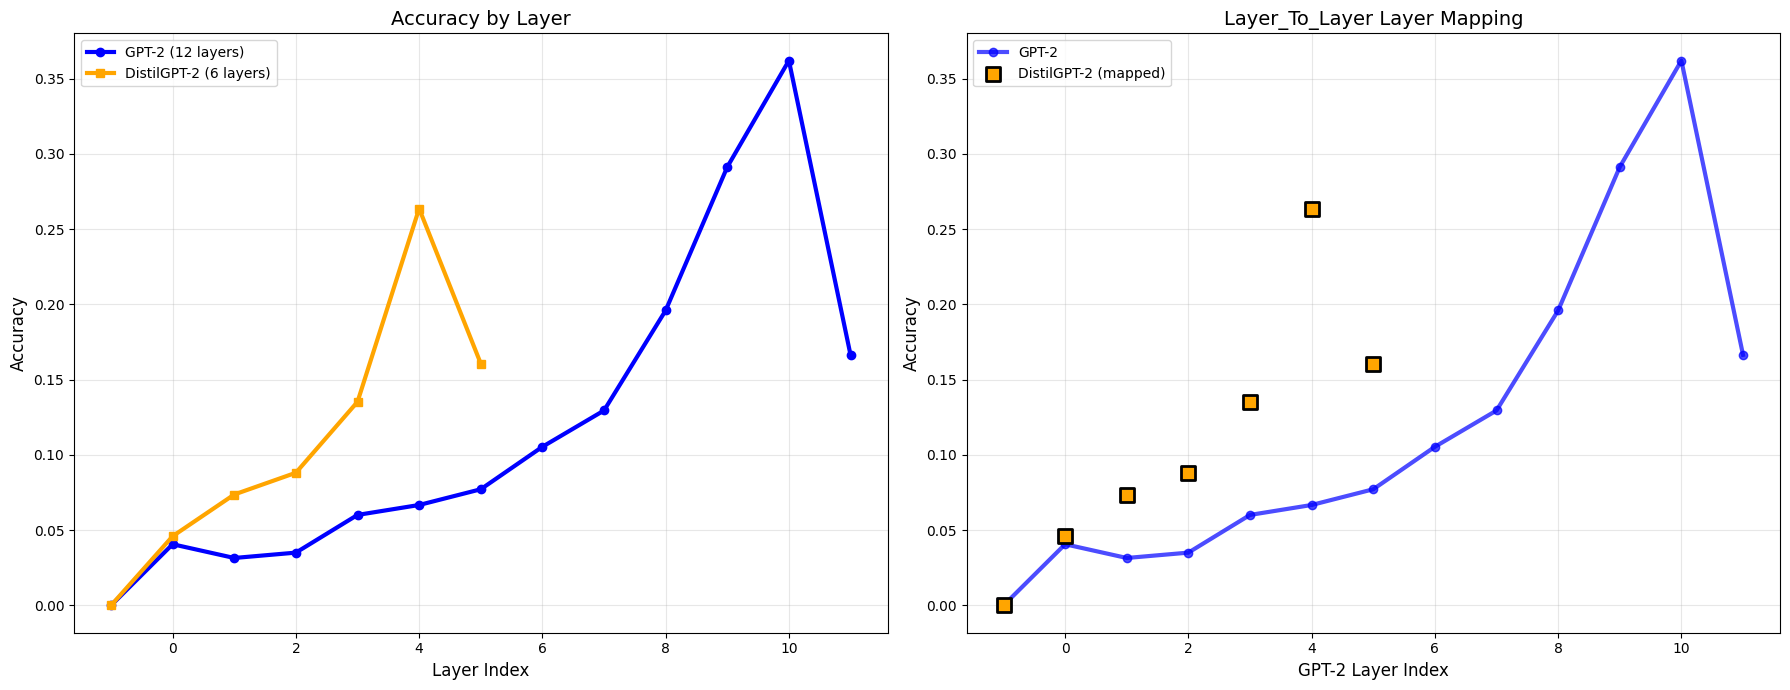

✓ Saved to gpt2_vs_distilgpt2_logit_lens_results/layer_to_layer/logit_lens_relative_accuracy.png


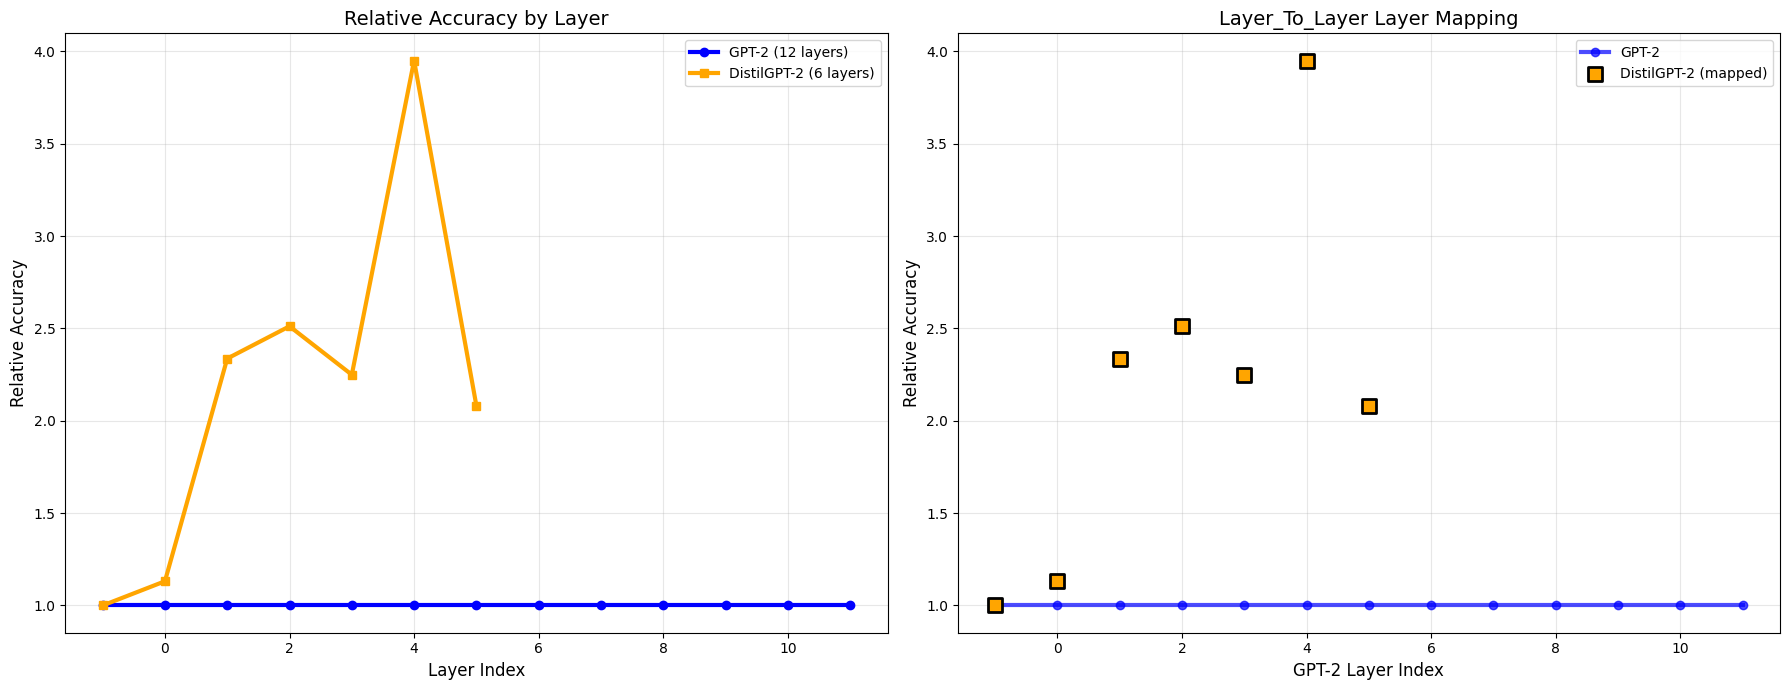

✓ Saved to gpt2_vs_distilgpt2_logit_lens_results/layer_to_layer/attention_analysis.png


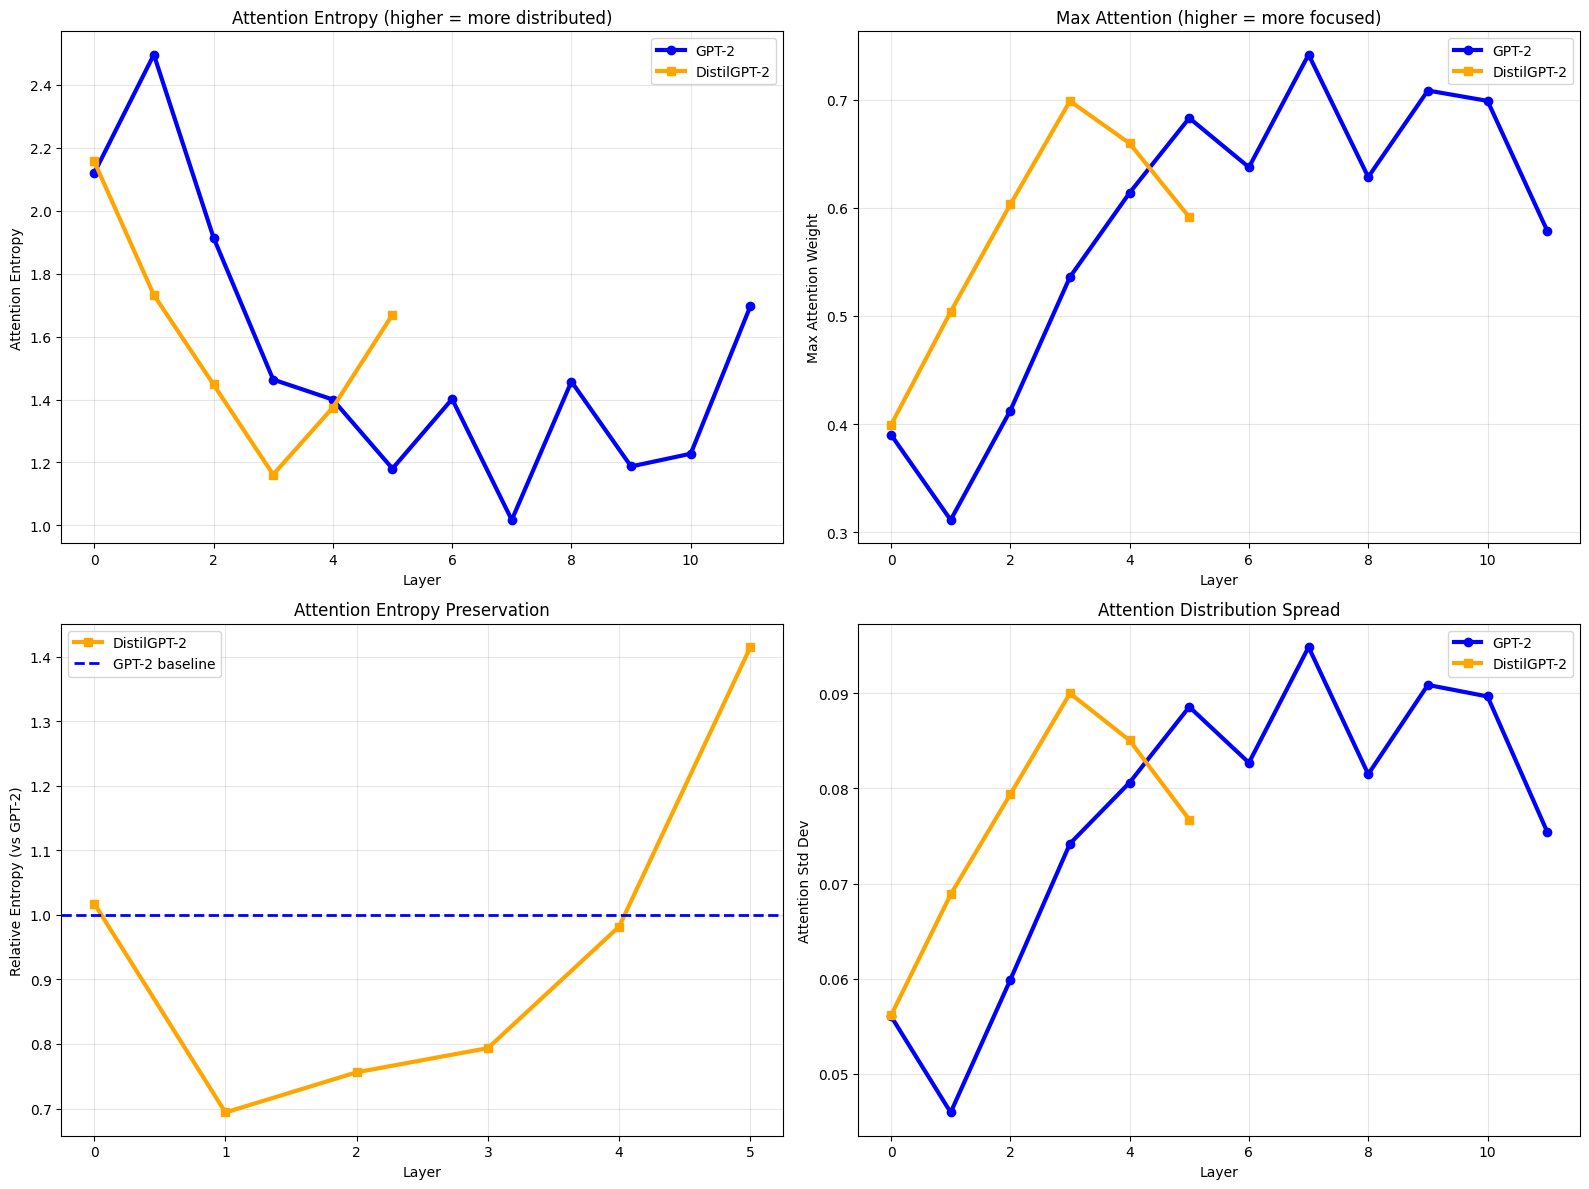


COMPARISON SUMMARY: GPT-2 vs DistilGPT-2

--- ACCURACY METRICS ---

GPT-2:
  Mean accuracy: 0.1202
  Min accuracy:  0.0000
  Max accuracy:  0.3620

DistilGPT-2:
  Mean accuracy: 0.1097
  Min accuracy:  0.0000
  Max accuracy:  0.2637

--- LAYER-WISE COMPARISON ---
DistilGPT-2 Layer    → GPT-2 Layer   Accuracy Diff   Relative Acc   
-----------------------------------------------------------------
Emb                  → L-1.0         +0.0000          1.0000
L0                   → L0.0          -0.0053          1.1311
L1                   → L1.0          -0.0422          2.3365
L2                   → L2.0          -0.0531          2.5113
L3                   → L3.0          -0.0751          2.2491
L4                   → L4.0          -0.1969          3.9496
L5                   → L5.0          -0.0835          2.0816

--- ATTENTION METRICS ---

GPT-2:
  Mean entropy:      1.5470
  Mean max attention: 0.5785

DistilGPT-2:
  Mean entropy:      1.5905
  Mean max attention: 0.5760

ANALYSIS 

In [ ]:
import torch
import numpy as np
import pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from tqdm.auto import tqdm
import random

class LogitLensAnalyzer_GPT2vsDistilGPT2:
    """
    Analyze how intermediate layer representations differ between GPT-2 and DistilGPT-2
    using logit lens and attention pattern analysis.
    """

    def __init__(
        self,
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        self.device = device

        # Load tokenizer (same for both models)
        print("Loading tokenizer...")
        self.tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
        self.tokenizer.pad_token = self.tokenizer.eos_token

        # Load GPT-2
        print(f"Loading GPT-2...")
        self.gpt2_model = GPT2LMHeadModel.from_pretrained(
            "gpt2",
            output_attentions=True,
            output_hidden_states=True
        ).to(device)
        self.gpt2_model.eval()
        gpt2_params = sum(p.numel() for p in self.gpt2_model.parameters())
        print(f"  GPT-2 loaded: {gpt2_params:,} parameters, {self.gpt2_model.config.n_layer} layers")

        # Load DistilGPT-2
        print(f"Loading DistilGPT-2...")
        self.distilgpt2_model = GPT2LMHeadModel.from_pretrained(
            "distilgpt2",
            output_attentions=True,
            output_hidden_states=True
        ).to(device)
        self.distilgpt2_model.eval()
        distil_params = sum(p.numel() for p in self.distilgpt2_model.parameters())
        print(f"  DistilGPT-2 loaded: {distil_params:,} parameters, {self.distilgpt2_model.config.n_layer} layers")

        print(f"\n✓ Models loaded on {device}")

    def get_layer_predictions(
        self,
        model: GPT2LMHeadModel,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor
    ) -> Tuple[Dict[int, Dict], torch.Tensor]:
        """
        Get predictions at each layer using logit lens.
        Returns both layer predictions and attention patterns.
        """
        layer_predictions = {}

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
                output_attentions=True
            )

            hidden_states = outputs.hidden_states
            attention_patterns = outputs.attentions
            lm_head = model.lm_head
            ln_f = model.transformer.ln_f

            # For each layer's hidden state, project through LM head
            for idx, hidden_state in enumerate(hidden_states):
                layer_idx = idx - 1  # -1 for embedding, 0-11 for layers

                # Project hidden state to vocabulary
                # logits = lm_head(hidden_state)
                normed = ln_f(hidden_state)  # ← change this
                logits = lm_head(normed)
                probs = torch.softmax(logits, dim=-1)
                top_probs, top_tokens = probs.max(dim=-1)

                # Calculate accuracy on next-token prediction
                if input_ids.size(1) > 1:
                    target_ids = input_ids[:, 1:]
                    pred_probs = probs[:, :-1, :]
                    mask = attention_mask[:, 1:].bool()

                    correct_probs = torch.gather(
                        pred_probs,
                        dim=2,
                        index=target_ids.unsqueeze(-1)
                    ).squeeze(-1)

                    masked_probs = correct_probs * mask.float()
                    avg_correct_prob = masked_probs.sum() / mask.sum()
                    avg_correct_prob = avg_correct_prob.item()
                else:
                    avg_correct_prob = None

                layer_predictions[layer_idx] = {
                    'logits': logits,
                    'top_tokens': top_tokens,
                    'top_probs': top_probs,
                    'correct_prob': avg_correct_prob
                }

        return layer_predictions, attention_patterns

    def compute_prediction_accuracy(
        self,
        predictions: Dict[int, Dict],
        target_ids: torch.Tensor,
        attention_mask: torch.Tensor
    ) -> Dict[int, float]:
        """Compute per-layer prediction accuracy with proper masking."""
        accuracies = {}

        # Create mask for valid (non-padding) positions
        mask = attention_mask[:, 1:].bool()

        for layer_idx in sorted(predictions.keys()):
            top_tokens = predictions[layer_idx]['top_tokens'][:, :-1]

            # Compute accuracy only on non-padding positions
            correct = (top_tokens == target_ids).float() * mask.float()
            accuracy = correct.sum() / mask.sum()
            accuracies[layer_idx] = accuracy.item()

        return accuracies

    def compute_attention_metrics(
        self,
        attention_patterns: Tuple[torch.Tensor],
        attention_mask: torch.Tensor
    ) -> Dict[int, Dict[str, float]]:
        """
        Compute attention-based metrics:
        - Entropy: How distributed is attention?
        - Max attention: Maximum attention weight per head
        - Uniformity: How uniform is the attention distribution?
        """
        if attention_patterns is None or len(attention_patterns) == 0:
            print("⚠️ Warning: No attention patterns found. Skipping attention metrics.")
            # Return dummy metrics for all possible layers
            return {i: {'entropy': 0.0, 'max_attention': 0.0, 'attention_std': 0.0} for i in range(12)}

        metrics = {}

        for layer_idx, attn in enumerate(attention_patterns):
            # Check if this specific layer's attention is None
            if attn is None:
                print(f"⚠️ Warning: Layer {layer_idx} attention is None")
                metrics[layer_idx] = {
                    'entropy': 0.0,
                    'max_attention': 0.0,
                    'attention_std': 0.0
                }
                continue

            # attn shape: (batch, n_heads, seq_len, seq_len)

            # Mask out padding in attention
            mask = attention_mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq)
            masked_attn = attn * mask.float()

            # Compute entropy (lower = more collapsed attention)
            eps = 1e-10
            attn_entropy = -(masked_attn * torch.log(masked_attn + eps)).sum(dim=-1)  # (batch, head, seq)

            # Average across batch, heads, and positions
            valid_mask = attention_mask.unsqueeze(1)  # (batch, 1, seq)
            masked_entropy = attn_entropy * valid_mask.float()
            avg_entropy = masked_entropy.sum() / (valid_mask.sum() * attn.size(1))

            # Max attention value
            max_attn = masked_attn.max(dim=-1)[0]  # (batch, head, seq)
            avg_max_attn = (max_attn * valid_mask.float()).sum() / (valid_mask.sum() * attn.size(1))

            # Standard deviation
            attn_std = masked_attn.std(dim=-1)  # (batch, head, seq)
            avg_std = (attn_std * valid_mask.float()).sum() / (valid_mask.sum() * attn.size(1))

            metrics[layer_idx] = {
                'entropy': avg_entropy.item(),
                'max_attention': avg_max_attn.item(),
                'attention_std': avg_std.item()
            }

        return metrics

    def compare_models(
        self,
        prompts: List[str],
        batch_size: int = 4,
        comparison_type: str = "proportional"
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Compare GPT-2 and DistilGPT-2 using logit lens.

        comparison_type:
            - "proportional": Map DistilGPT-2 layers proportionally to GPT-2
            - "layer_to_layer": Compare same layer indices (where they exist)

        Returns:
            (accuracy_df, attention_df): DataFrames with metrics
        """
        accuracy_results = []
        attention_results = []

        n_batches = (len(prompts) + batch_size - 1) // batch_size
        print(f"\nProcessing {len(prompts)} prompts in {n_batches} batches...")
        print(f"Comparison type: {comparison_type}")

        # ===================================================================
        # ANALYZE GPT-2 (12 layers)
        # ===================================================================
        print("\n" + "="*80)
        print("ANALYZING GPT-2 (12 layers)")
        print("="*80)

        gpt2_accuracies_all = {i: [] for i in range(-1, 12)}
        gpt2_attn_metrics_all = {i: {'entropy': [], 'max_attention': [], 'attention_std': []} for i in range(12)}

        for batch_idx in tqdm(range(n_batches), desc="GPT-2 batches"):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(prompts))
            batch_prompts = prompts[start_idx:end_idx]

            inputs = self.tokenizer(
                batch_prompts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=64
            ).to(self.device)

            target_ids = inputs.input_ids[:, 1:]

            with torch.no_grad():
                gpt2_preds, gpt2_attn = self.get_layer_predictions(
                    self.gpt2_model,
                    inputs.input_ids,
                    inputs.attention_mask
                )
                gpt2_acc = self.compute_prediction_accuracy(
                    gpt2_preds,
                    target_ids,
                    inputs.attention_mask
                )
                gpt2_metrics = self.compute_attention_metrics(
                    gpt2_attn,
                    inputs.attention_mask
                )

            # Accumulate results
            for layer_idx in gpt2_acc.keys():
                gpt2_accuracies_all[layer_idx].append(gpt2_acc[layer_idx])

            for layer_idx in gpt2_metrics.keys():
                gpt2_attn_metrics_all[layer_idx]['entropy'].append(gpt2_metrics[layer_idx]['entropy'])
                gpt2_attn_metrics_all[layer_idx]['max_attention'].append(gpt2_metrics[layer_idx]['max_attention'])
                gpt2_attn_metrics_all[layer_idx]['attention_std'].append(gpt2_metrics[layer_idx]['attention_std'])

            del inputs, target_ids, gpt2_preds, gpt2_attn, gpt2_acc, gpt2_metrics

        # Average GPT-2 metrics
        gpt2_accuracies = {layer: np.mean(vals) for layer, vals in gpt2_accuracies_all.items()}
        gpt2_attn_metrics = {
            layer: {
                'entropy': np.mean(gpt2_attn_metrics_all[layer]['entropy']),
                'max_attention': np.mean(gpt2_attn_metrics_all[layer]['max_attention']),
                'attention_std': np.mean(gpt2_attn_metrics_all[layer]['attention_std'])
            }
            for layer in gpt2_attn_metrics_all.keys()
        }

        print(f"✓ GPT-2 analysis complete")

        # ===================================================================
        # ANALYZE DistilGPT-2 (6 layers)
        # ===================================================================
        print("\n" + "="*80)
        print("ANALYZING DistilGPT-2 (6 layers)")
        print("="*80)

        distil_accuracies_all = {i: [] for i in range(-1, 6)}
        distil_attn_metrics_all = {i: {'entropy': [], 'max_attention': [], 'attention_std': []} for i in range(6)}

        for batch_idx in tqdm(range(n_batches), desc="DistilGPT-2 batches"):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(prompts))
            batch_prompts = prompts[start_idx:end_idx]

            inputs = self.tokenizer(
                batch_prompts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=64
            ).to(self.device)

            target_ids = inputs.input_ids[:, 1:]

            with torch.no_grad():
                distil_preds, distil_attn = self.get_layer_predictions(
                    self.distilgpt2_model,
                    inputs.input_ids,
                    inputs.attention_mask
                )
                distil_acc = self.compute_prediction_accuracy(
                    distil_preds,
                    target_ids,
                    inputs.attention_mask
                )
                distil_metrics = self.compute_attention_metrics(
                    distil_attn,
                    inputs.attention_mask
                )

            # Accumulate results
            for layer_idx in distil_acc.keys():
                distil_accuracies_all[layer_idx].append(distil_acc[layer_idx])

            for layer_idx in distil_metrics.keys():
                distil_attn_metrics_all[layer_idx]['entropy'].append(distil_metrics[layer_idx]['entropy'])
                distil_attn_metrics_all[layer_idx]['max_attention'].append(distil_metrics[layer_idx]['max_attention'])
                distil_attn_metrics_all[layer_idx]['attention_std'].append(distil_metrics[layer_idx]['attention_std'])

            del inputs, target_ids, distil_preds, distil_attn, distil_acc, distil_metrics

        # Average DistilGPT-2 metrics
        distil_accuracies = {layer: np.mean(vals) for layer, vals in distil_accuracies_all.items()}
        distil_attn_metrics = {
            layer: {
                'entropy': np.mean(distil_attn_metrics_all[layer]['entropy']),
                'max_attention': np.mean(distil_attn_metrics_all[layer]['max_attention']),
                'attention_std': np.mean(distil_attn_metrics_all[layer]['attention_std'])
            }
            for layer in distil_attn_metrics_all.keys()
        }

        print(f"✓ DistilGPT-2 analysis complete")

        # ===================================================================
        # CREATE LAYER MAPPINGS
        # ===================================================================
        print(f"\n" + "="*80)
        print("CREATING LAYER MAPPINGS")
        print("="*80)

        if comparison_type == "proportional":
            # Map DistilGPT-2 layers proportionally to GPT-2
            # DistilGPT-2: Emb, L0-L5 (7 total)
            # GPT-2: Emb, L0-L11 (13 total)

            layer_pairs = []

            # Embedding layer
            layer_pairs.append((-1, -1, "Emb"))

            # Map 6 DistilGPT-2 layers to 12 GPT-2 layers
            for distil_idx in range(6):
                gpt2_idx = int(distil_idx * 11 / 5)  # Map 0-5 to 0-11
                layer_pairs.append((gpt2_idx, distil_idx, f"D{distil_idx}→G{gpt2_idx}"))

            print(f"\nProportional mapping:")
            for g_idx, d_idx, label in layer_pairs:
                print(f"  {label}")

        elif comparison_type == "layer_to_layer":
            # Compare same indices (where they exist)
            layer_pairs = [(-1, -1, "Emb")]  # Embedding
            for idx in range(6):
                layer_pairs.append((idx, idx, f"L{idx}"))

            print(f"\nLayer-to-layer mapping (layers 0-5 only):")
            for g_idx, d_idx, label in layer_pairs:
                print(f"  {label}")

        # ===================================================================
        # STORE RESULTS WITH MAPPINGS
        # ===================================================================

        # Store GPT-2 results
        for layer_idx in sorted(gpt2_accuracies.keys()):
            layer_name = "Emb" if layer_idx == -1 else f"L{layer_idx}"
            accuracy_results.append({
                'model': 'GPT-2',
                'layer': layer_idx,
                'layer_name': layer_name,
                'accuracy': gpt2_accuracies[layer_idx],
                'correct_prob': gpt2_accuracies[layer_idx],
                'relative_accuracy': 1.0,
                'accuracy_diff': 0.0
            })

        for layer_idx in sorted(gpt2_attn_metrics.keys()):
            attention_results.append({
                'model': 'GPT-2',
                'layer': layer_idx,
                'layer_name': f"L{layer_idx}",
                'entropy': gpt2_attn_metrics[layer_idx]['entropy'],
                'max_attention': gpt2_attn_metrics[layer_idx]['max_attention'],
                'attention_std': gpt2_attn_metrics[layer_idx]['attention_std'],
                'relative_entropy': 1.0
            })

        # Store DistilGPT-2 results WITH comparison to corresponding GPT-2 layers
        for gpt2_idx, distil_idx, label in layer_pairs:
            if distil_idx not in distil_accuracies:
                continue

            gpt2_acc = gpt2_accuracies.get(gpt2_idx, None)
            distil_acc = distil_accuracies[distil_idx]

            if gpt2_acc is not None and gpt2_acc > 0.01:
                rel_acc = distil_acc / gpt2_acc
                acc_diff = gpt2_acc - distil_acc
            else:
                rel_acc = 1.0
                acc_diff = 0.0

            layer_name = "Emb" if distil_idx == -1 else f"L{distil_idx}"

            accuracy_results.append({
                'model': 'DistilGPT-2',
                'layer': distil_idx,
                'layer_name': layer_name,
                'mapped_to_gpt2_layer': gpt2_idx,
                'accuracy': distil_acc,
                'correct_prob': distil_acc,
                'relative_accuracy': rel_acc,
                'accuracy_diff': acc_diff
            })

        # Store DistilGPT-2 attention results
        for gpt2_idx, distil_idx, label in layer_pairs[1:]:  # Skip embedding
            if distil_idx not in distil_attn_metrics:
                continue

            gpt2_entropy = gpt2_attn_metrics.get(gpt2_idx, {}).get('entropy', None)
            distil_entropy = distil_attn_metrics[distil_idx]['entropy']

            if gpt2_entropy is not None and gpt2_entropy > 1e-10:
                rel_entropy = distil_entropy / gpt2_entropy
            else:
                rel_entropy = 1.0

            attention_results.append({
                'model': 'DistilGPT-2',
                'layer': distil_idx,
                'layer_name': f"L{distil_idx}",
                'mapped_to_gpt2_layer': gpt2_idx,
                'entropy': distil_entropy,
                'max_attention': distil_attn_metrics[distil_idx]['max_attention'],
                'attention_std': distil_attn_metrics[distil_idx]['attention_std'],
                'relative_entropy': rel_entropy
            })

        accuracy_df = pd.DataFrame(accuracy_results)
        attention_df = pd.DataFrame(attention_results)

        return accuracy_df, attention_df

    def visualize_logit_lens(
        self,
        df: pd.DataFrame,
        metric: str = 'accuracy',
        comparison_type: str = "proportional",
        save_path: str = None
    ):
        """Visualize layer-by-layer predictions."""
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))

        # Plot 1: Absolute values
        ax1 = axes[0]

        # GPT-2 (all layers)
        gpt2_data = df[df['model'] == 'GPT-2'].sort_values('layer')
        ax1.plot(
            gpt2_data['layer'],
            gpt2_data[metric],
            label='GPT-2 (12 layers)',
            linewidth=3,
            color='blue',
            marker='o',
            markersize=6
        )

        # DistilGPT-2
        distil_data = df[df['model'] == 'DistilGPT-2'].sort_values('layer')
        ax1.plot(
            distil_data['layer'],
            distil_data[metric],
            label='DistilGPT-2 (6 layers)',
            linewidth=3,
            color='orange',
            marker='s',
            markersize=6
        )

        ax1.set_xlabel('Layer Index', fontsize=12)
        ax1.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
        ax1.set_title(f'{metric.replace("_", " ").title()} by Layer', fontsize=14)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)

        # Plot 2: Mapped comparison
        ax2 = axes[1]

        # GPT-2
        ax2.plot(
            gpt2_data['layer'],
            gpt2_data[metric],
            label='GPT-2',
            linewidth=3,
            color='blue',
            marker='o',
            markersize=6,
            alpha=0.7
        )

        # DistilGPT-2 mapped to GPT-2 layers
        if 'mapped_to_gpt2_layer' in distil_data.columns:
            for _, row in distil_data.iterrows():
                ax2.scatter(
                    row['mapped_to_gpt2_layer'],
                    row[metric],
                    color='orange',
                    s=100,
                    marker='s',
                    edgecolors='black',
                    linewidths=2,
                    zorder=10
                )
                # Draw line to show mapping
                ax2.plot(
                    [row['layer'], row['mapped_to_gpt2_layer']],
                    [row[metric], row[metric]],
                    'k--',
                    alpha=0.2,
                    linewidth=1
                )

        ax2.scatter([], [], color='orange', s=100, marker='s',
                   edgecolors='black', linewidths=2, label='DistilGPT-2 (mapped)')

        ax2.set_xlabel('GPT-2 Layer Index', fontsize=12)
        ax2.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
        ax2.set_title(f'{comparison_type.title()} Layer Mapping', fontsize=14)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Saved to {save_path}")

        plt.show()

    def visualize_attention_analysis(
        self,
        attention_df: pd.DataFrame,
        save_path: str = None
    ):
        """Visualize attention metrics across models."""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Plot 1: Attention Entropy
        ax = axes[0, 0]
        for model_name in ['GPT-2', 'DistilGPT-2']:
            model_data = attention_df[attention_df['model'] == model_name].sort_values('layer')

            if model_name == 'GPT-2':
                ax.plot(model_data['layer'], model_data['entropy'],
                       label=model_name, linewidth=3, color='blue',
                       marker='o', markersize=6)
            else:
                ax.plot(model_data['layer'], model_data['entropy'],
                       label=model_name, linewidth=3, color='orange',
                       marker='s', markersize=6)

        ax.set_xlabel('Layer')
        ax.set_ylabel('Attention Entropy')
        ax.set_title('Attention Entropy (higher = more distributed)')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

        # Plot 2: Max Attention
        ax = axes[0, 1]
        for model_name in ['GPT-2', 'DistilGPT-2']:
            model_data = attention_df[attention_df['model'] == model_name].sort_values('layer')

            if model_name == 'GPT-2':
                ax.plot(model_data['layer'], model_data['max_attention'],
                       label=model_name, linewidth=3, color='blue',
                       marker='o', markersize=6)
            else:
                ax.plot(model_data['layer'], model_data['max_attention'],
                       label=model_name, linewidth=3, color='orange',
                       marker='s', markersize=6)

        ax.set_xlabel('Layer')
        ax.set_ylabel('Max Attention Weight')
        ax.set_title('Max Attention (higher = more focused)')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

        # Plot 3: Relative Entropy (DistilGPT-2 only)
        ax = axes[1, 0]
        distil_data = attention_df[attention_df['model'] == 'DistilGPT-2'].sort_values('layer')
        ax.plot(distil_data['layer'], distil_data['relative_entropy'],
               label='DistilGPT-2', linewidth=3, color='orange',
               marker='s', markersize=6)
        ax.axhline(y=1.0, color='blue', linestyle='--', linewidth=2, label='GPT-2 baseline')

        ax.set_xlabel('Layer')
        ax.set_ylabel('Relative Entropy (vs GPT-2)')
        ax.set_title('Attention Entropy Preservation')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

        # Plot 4: Attention Std Dev
        ax = axes[1, 1]
        for model_name in ['GPT-2', 'DistilGPT-2']:
            model_data = attention_df[attention_df['model'] == model_name].sort_values('layer')

            if model_name == 'GPT-2':
                ax.plot(model_data['layer'], model_data['attention_std'],
                       label=model_name, linewidth=3, color='blue',
                       marker='o', markersize=6)
            else:
                ax.plot(model_data['layer'], model_data['attention_std'],
                       label=model_name, linewidth=3, color='orange',
                       marker='s', markersize=6)

        ax.set_xlabel('Layer')
        ax.set_ylabel('Attention Std Dev')
        ax.set_title('Attention Distribution Spread')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Saved to {save_path}")

        plt.show()

    def create_comparison_summary(
        self,
        accuracy_df: pd.DataFrame,
        attention_df: pd.DataFrame,
        save_path: str = None
    ):
        """Create comprehensive comparison summary."""
        print("\n" + "="*80)
        print("COMPARISON SUMMARY: GPT-2 vs DistilGPT-2")
        print("="*80)

        # Accuracy summary
        print("\n--- ACCURACY METRICS ---")
        for model in ['GPT-2', 'DistilGPT-2']:
            model_data = accuracy_df[accuracy_df['model'] == model]
            mean_acc = model_data['accuracy'].mean()
            min_acc = model_data['accuracy'].min()
            max_acc = model_data['accuracy'].max()

            print(f"\n{model}:")
            print(f"  Mean accuracy: {mean_acc:.4f}")
            print(f"  Min accuracy:  {min_acc:.4f}")
            print(f"  Max accuracy:  {max_acc:.4f}")

        # Compare mapped layers
        distil_data = accuracy_df[accuracy_df['model'] == 'DistilGPT-2']
        if 'mapped_to_gpt2_layer' in distil_data.columns:
            print("\n--- LAYER-WISE COMPARISON ---")
            print(f"{'DistilGPT-2 Layer':<20} {'→ GPT-2 Layer':<15} {'Accuracy Diff':<15} {'Relative Acc':<15}")
            print("-" * 65)

            for _, row in distil_data.iterrows():
                layer_name = row['layer_name']
                gpt2_layer = row.get('mapped_to_gpt2_layer', 'N/A')
                acc_diff = row.get('accuracy_diff', 0)
                rel_acc = row.get('relative_accuracy', 1.0)

                print(f"{layer_name:<20} {'→ L' + str(gpt2_layer) if gpt2_layer != 'N/A' else 'N/A':<15} "
                      f"{acc_diff:+.4f}{'':9} {rel_acc:.4f}")

        # Attention summary
        print("\n--- ATTENTION METRICS ---")
        for model in ['GPT-2', 'DistilGPT-2']:
            model_data = attention_df[attention_df['model'] == model]
            mean_entropy = model_data['entropy'].mean()
            mean_max_attn = model_data['max_attention'].mean()

            print(f"\n{model}:")
            print(f"  Mean entropy:      {mean_entropy:.4f}")
            print(f"  Mean max attention: {mean_max_attn:.4f}")


# def sample_tinystories_prompts(
#     tokenizer,
#     n_samples: int = 200,
#     max_tokens: int = 64,
#     seed: int = 42
# ) -> List[str]:
#     """Sample token-truncated prompts from TinyStories."""
#     print("\nLoading TinyStories dataset...")
#     random.seed(seed)
#     dataset = load_dataset(
#         "roneneldan/TinyStories",
#         split="train",
#         streaming=True
#     ).shuffle(seed=seed)

#     prompts = []
#     stories_iter = iter(dataset)

#     print(f"Sampling {n_samples} prompts...")
#     for _ in tqdm(range(n_samples), desc="Sampling stories"):
#         try:
#             story = next(stories_iter)["text"]
#             tokens = tokenizer.encode(story, add_special_tokens=False)

#             if len(tokens) <= max_tokens:
#                 sampled = tokens
#             else:
#                 start = random.randint(0, len(tokens) - max_tokens)
#                 sampled = tokens[start:start + max_tokens]

#             prompt = tokenizer.decode(sampled, clean_up_tokenization_spaces=True).strip()
#             prompts.append(prompt)
#         except StopIteration:
#             print(f"⚠️ Only {len(prompts)} stories available")
#             break

#     print(f"✓ Sampled {len(prompts)} prompts")
#     return prompts
def sample_tinystories_prompts(
    tokenizer,
    n_samples: int = 500,
    min_tokens: int = 64,
    max_tokens: int = 256,
    seed: int = 42) -> List[str]:

    """
    Sample TinyStories prompts with token lengths within [min_tokens, max_tokens].

    Args:
        tokenizer: GPT2Tokenizer instance
        n_samples: Number of prompts to sample
        min_tokens: Minimum number of tokens per prompt
        max_tokens: Maximum number of tokens per prompt
        seed: Random seed for reproducibility

    Returns:
        List of sampled prompts
    """
    print("\nLoading TinyStories dataset...")
    random.seed(seed)
    dataset = load_dataset(
        "roneneldan/TinyStories",
        split="validation",
        streaming=True
    ).shuffle(seed=seed)

    prompts = []
    stories_iter = iter(dataset)

    print(f"Sampling {n_samples} prompts with token length in [{min_tokens}, {max_tokens}]...")
    while len(prompts) < n_samples:
        try:
            story = next(stories_iter)["text"]
            tokens = tokenizer.encode(story, add_special_tokens=False)
            if min_tokens <= len(tokens) <= max_tokens:
                prompt = tokenizer.decode(
                    tokens,
                    clean_up_tokenization_spaces=True
                ).strip()
                prompts.append(prompt)
        except StopIteration:
            print(f"⚠️ Only {len(prompts)} stories available within the token range")
            break

    print(f"✓ Sampled {len(prompts)} prompts within token range")
    return prompts


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    # Initialize analyzer
    analyzer = LogitLensAnalyzer_GPT2vsDistilGPT2(
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    # Sample prompts from TinyStories
    test_prompts = sample_tinystories_prompts(
        tokenizer=analyzer.tokenizer,
        n_samples=1000,
        max_tokens=256,
        seed=42
    )

    # Create output directory
    output_dir = Path("gpt2_vs_distilgpt2_logit_lens_results")
    output_dir.mkdir(exist_ok=True, parents=True)

    # Save sampled prompts
    with open(output_dir / "sampled_prompts.txt", "w") as f:
        for i, prompt in enumerate(test_prompts, 1):
            f.write(f"{i}. {prompt}\n\n")
    print(f"✓ Saved prompts to {output_dir / 'sampled_prompts.txt'}")

    # =========================================================================
    # RUN BOTH COMPARISON TYPES
    # =========================================================================

    for comparison_type in ["proportional", "layer_to_layer"]:
        print("\n" + "="*80)
        print(f"LOGIT LENS ANALYSIS: {comparison_type.upper()} COMPARISON")
        print("="*80)

        # Run analysis
        accuracy_df, attention_df = analyzer.compare_models(
            prompts=test_prompts,
            batch_size=4,
            comparison_type=comparison_type
        )

        # Create subdirectory for this comparison type
        comparison_dir = output_dir / comparison_type
        comparison_dir.mkdir(exist_ok=True)

        # Save results
        accuracy_df.to_csv(comparison_dir / "logit_lens_accuracy.csv", index=False)
        attention_df.to_csv(comparison_dir / "attention_metrics.csv", index=False)
        print(f"\n✓ Saved results to {comparison_dir}")

        # Visualizations
        print("\n" + "="*80)
        print(f"CREATING VISUALIZATIONS ({comparison_type})")
        print("="*80)

        analyzer.visualize_logit_lens(
            accuracy_df,
            metric='accuracy',
            comparison_type=comparison_type,
            save_path=comparison_dir / "logit_lens_accuracy.png"
        )

        analyzer.visualize_logit_lens(
            accuracy_df,
            metric='relative_accuracy',
            comparison_type=comparison_type,
            save_path=comparison_dir / "logit_lens_relative_accuracy.png"
        )

        analyzer.visualize_attention_analysis(
            attention_df,
            save_path=comparison_dir / "attention_analysis.png"
        )

        # Summary
        analyzer.create_comparison_summary(
            accuracy_df,
            attention_df
        )

        # Clear GPU memory between runs
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    print(f"\nAll results saved to: {output_dir}")

#Attention Pattern Analysis

Loading tokenizer...
✓ Using device: cuda
ATTENTION PATTERN ANALYSIS: GPT-2 vs DistilGPT-2
Loading gpt2 with TransformerLens...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model config: 12 layers, 12 heads, d_model=768
  ✓ Loaded successfully
Loading distilgpt2 with TransformerLens...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model config: 6 layers, 12 heads, d_model=768
  ✓ Loaded successfully
Loading TinyStories dataset...
Sampling 1000 prompts with token length in [64, 256]...


Token indices sequence length is longer than the specified maximum sequence length for this model (1045 > 1024). Running this sequence through the model will result in indexing errors


  Examined 1000 stories, found 938 so far...
✓ Sampled 1000 prompts within token range

RUNNING: PROPORTIONAL


Processing samples: 100%|██████████| 1000/1000 [18:10<00:00,  1.09s/it]


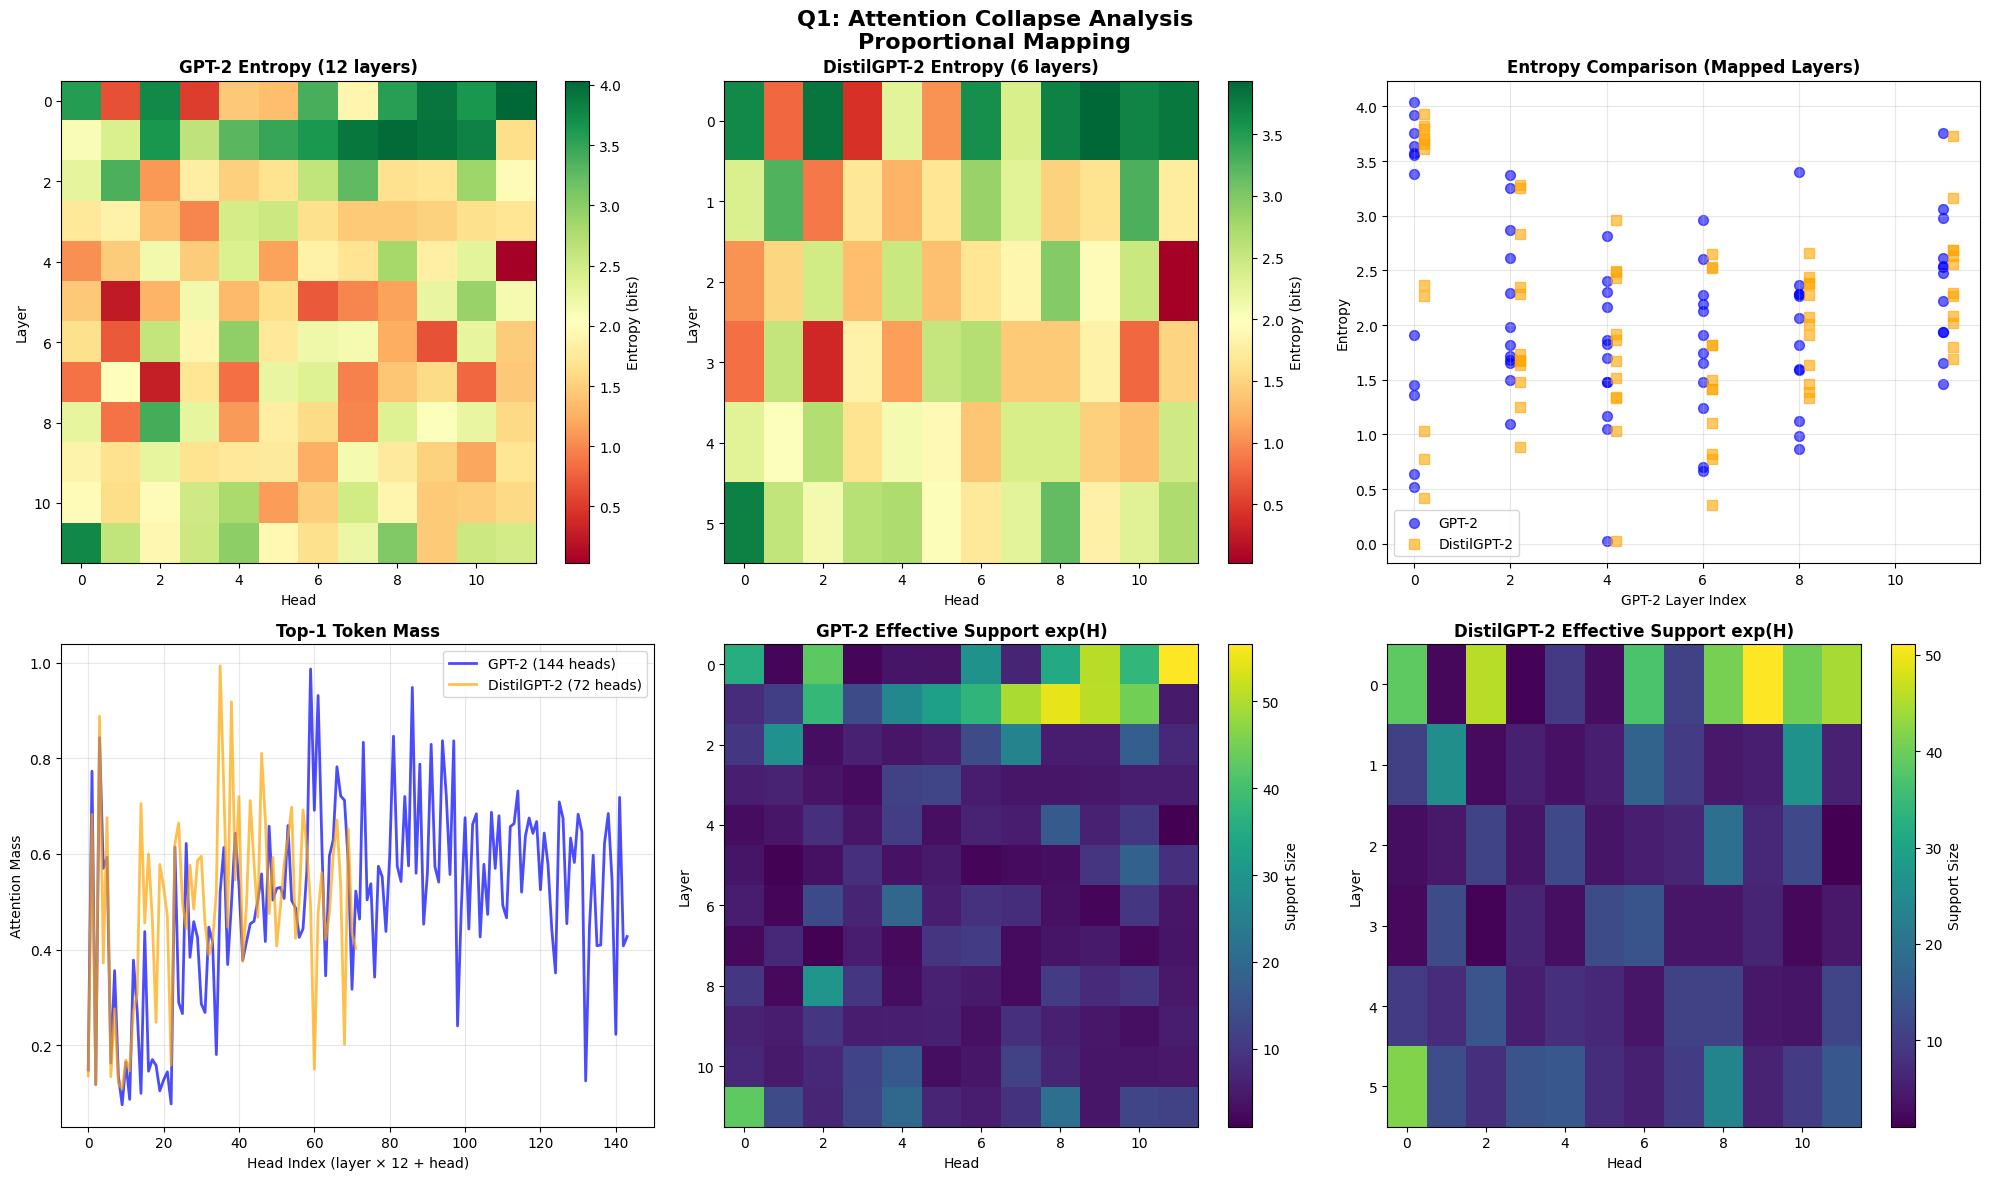

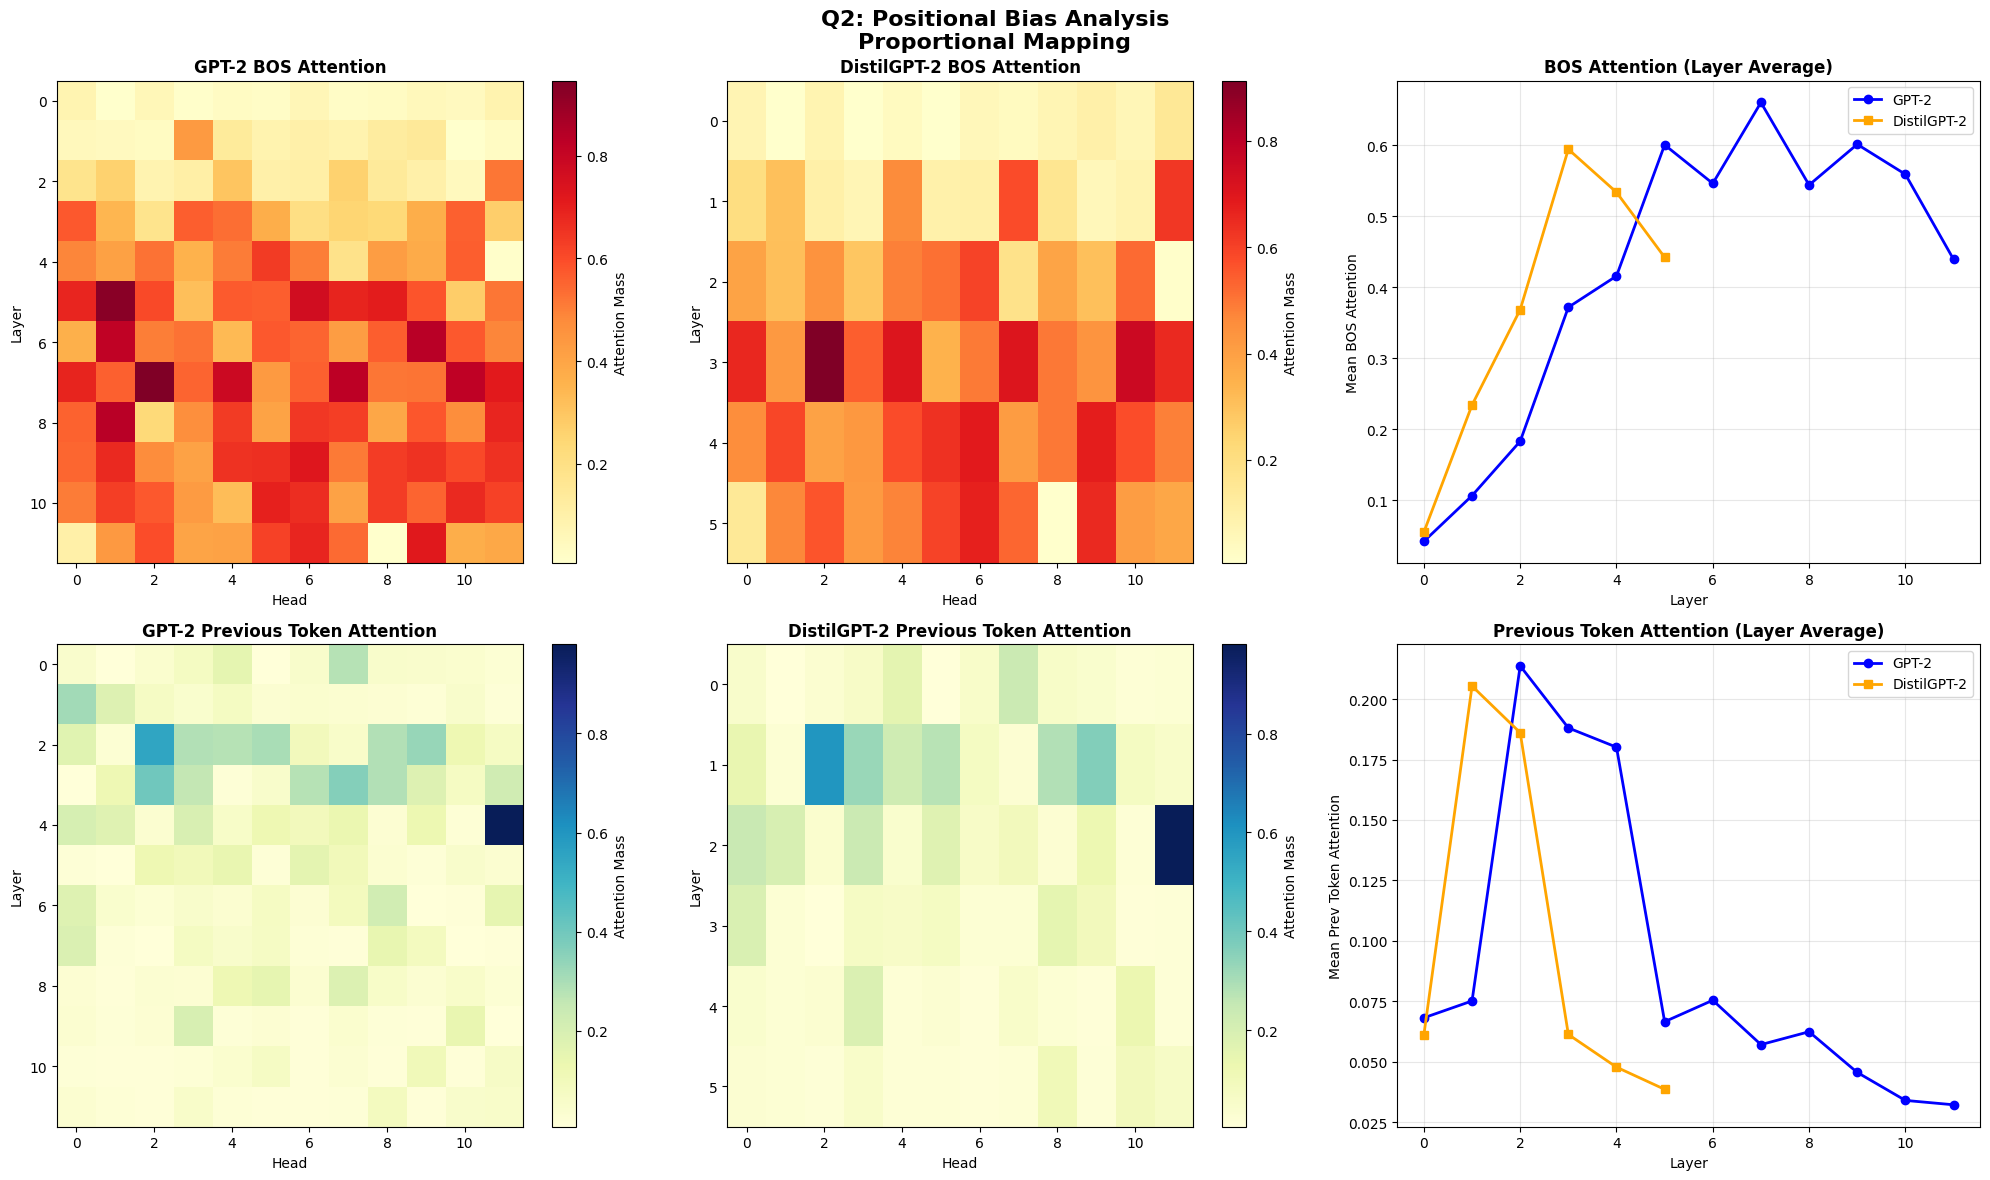

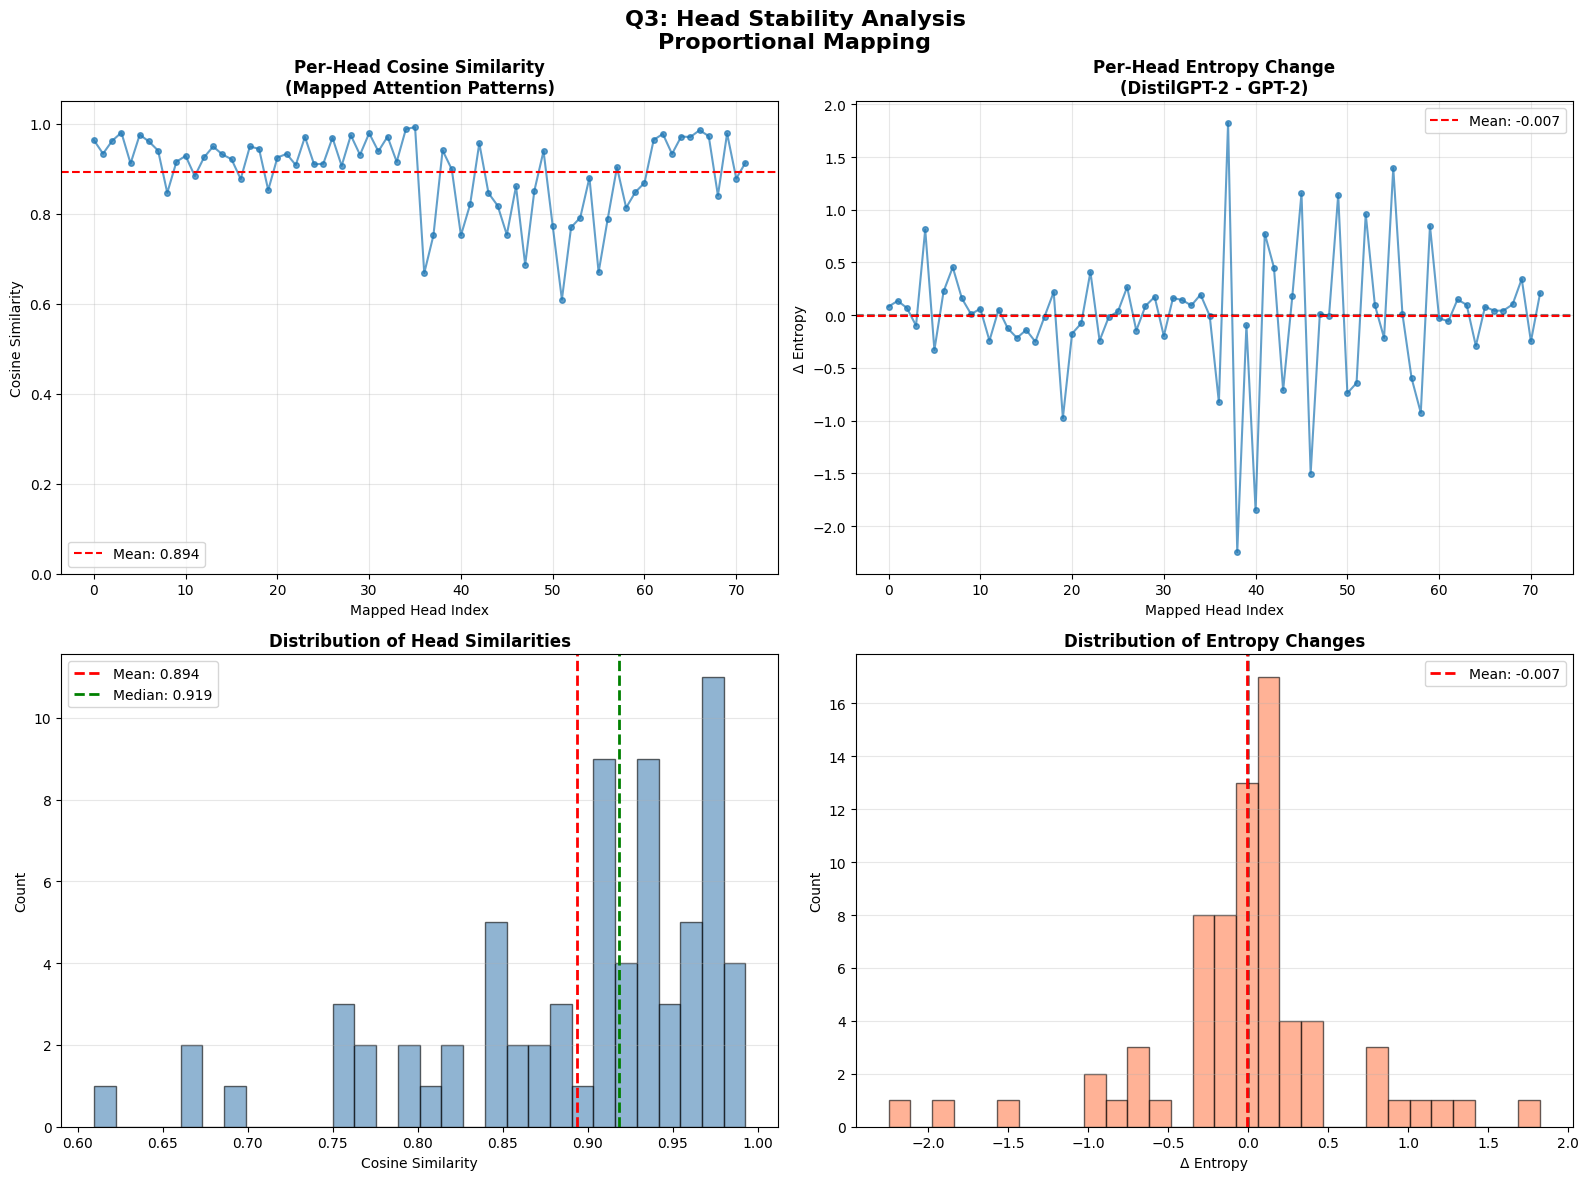


SUMMARY: PROPORTIONAL COMPARISON

GPT-2 (12 layers, 144 heads):
  Mean Entropy: 2.0010
  Mean Effective Support: 11.1930
  Mean Top-1 Mass: 0.5069

DistilGPT-2 (6 layers, 72 heads):
  Mean Entropy: 2.0943
  Mean Effective Support: 12.1360
  Mean Top-1 Mass: 0.4930

Comparison (Mapped Heads):
  Mean Head Similarity: 0.8935 ± 0.0857
  Range: [0.6095, 0.9927]
  Mean Entropy Change: -0.0065 ± 0.6209

RUNNING: LAYER_TO_LAYER


Processing samples: 100%|██████████| 1000/1000 [18:21<00:00,  1.10s/it]


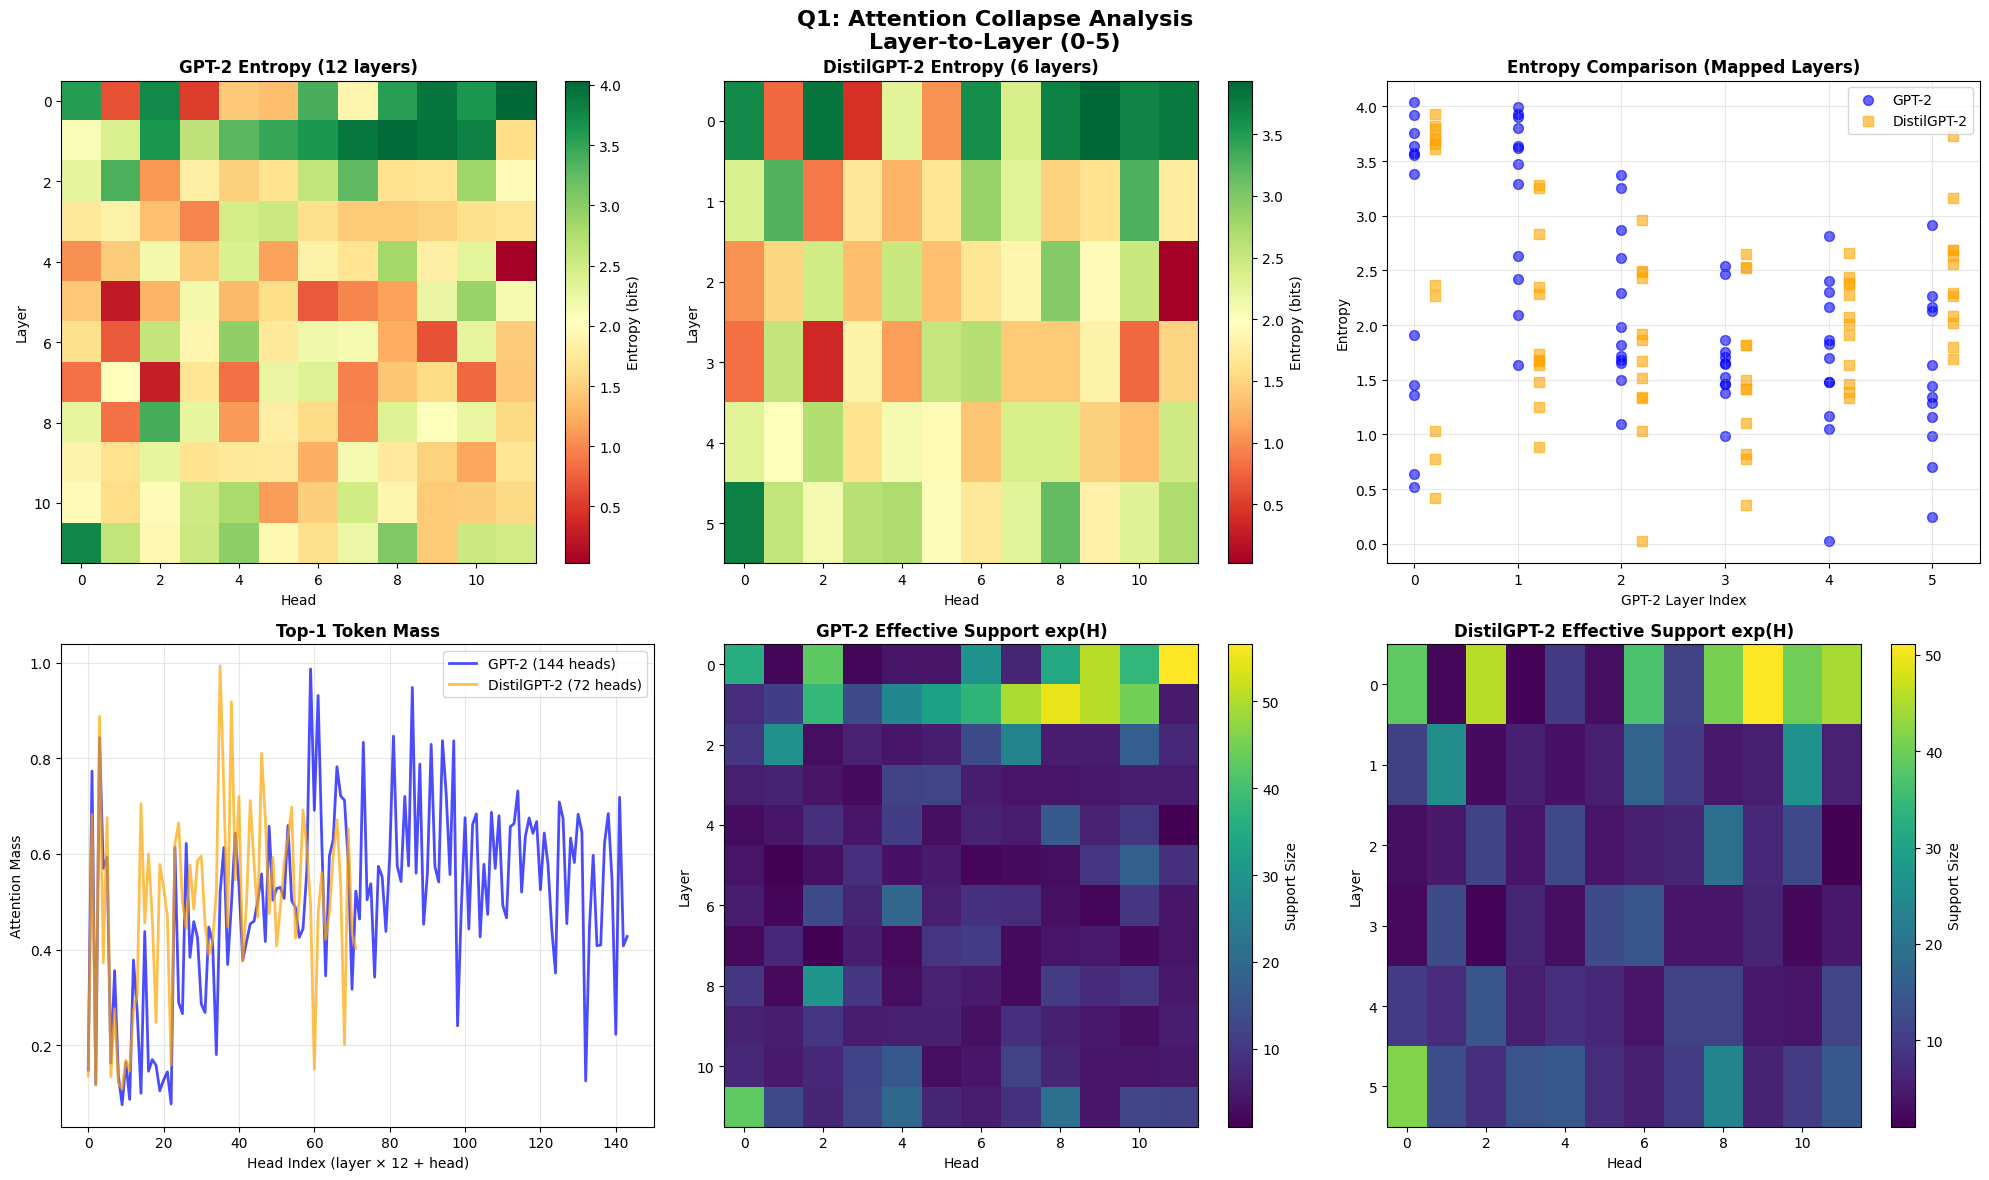

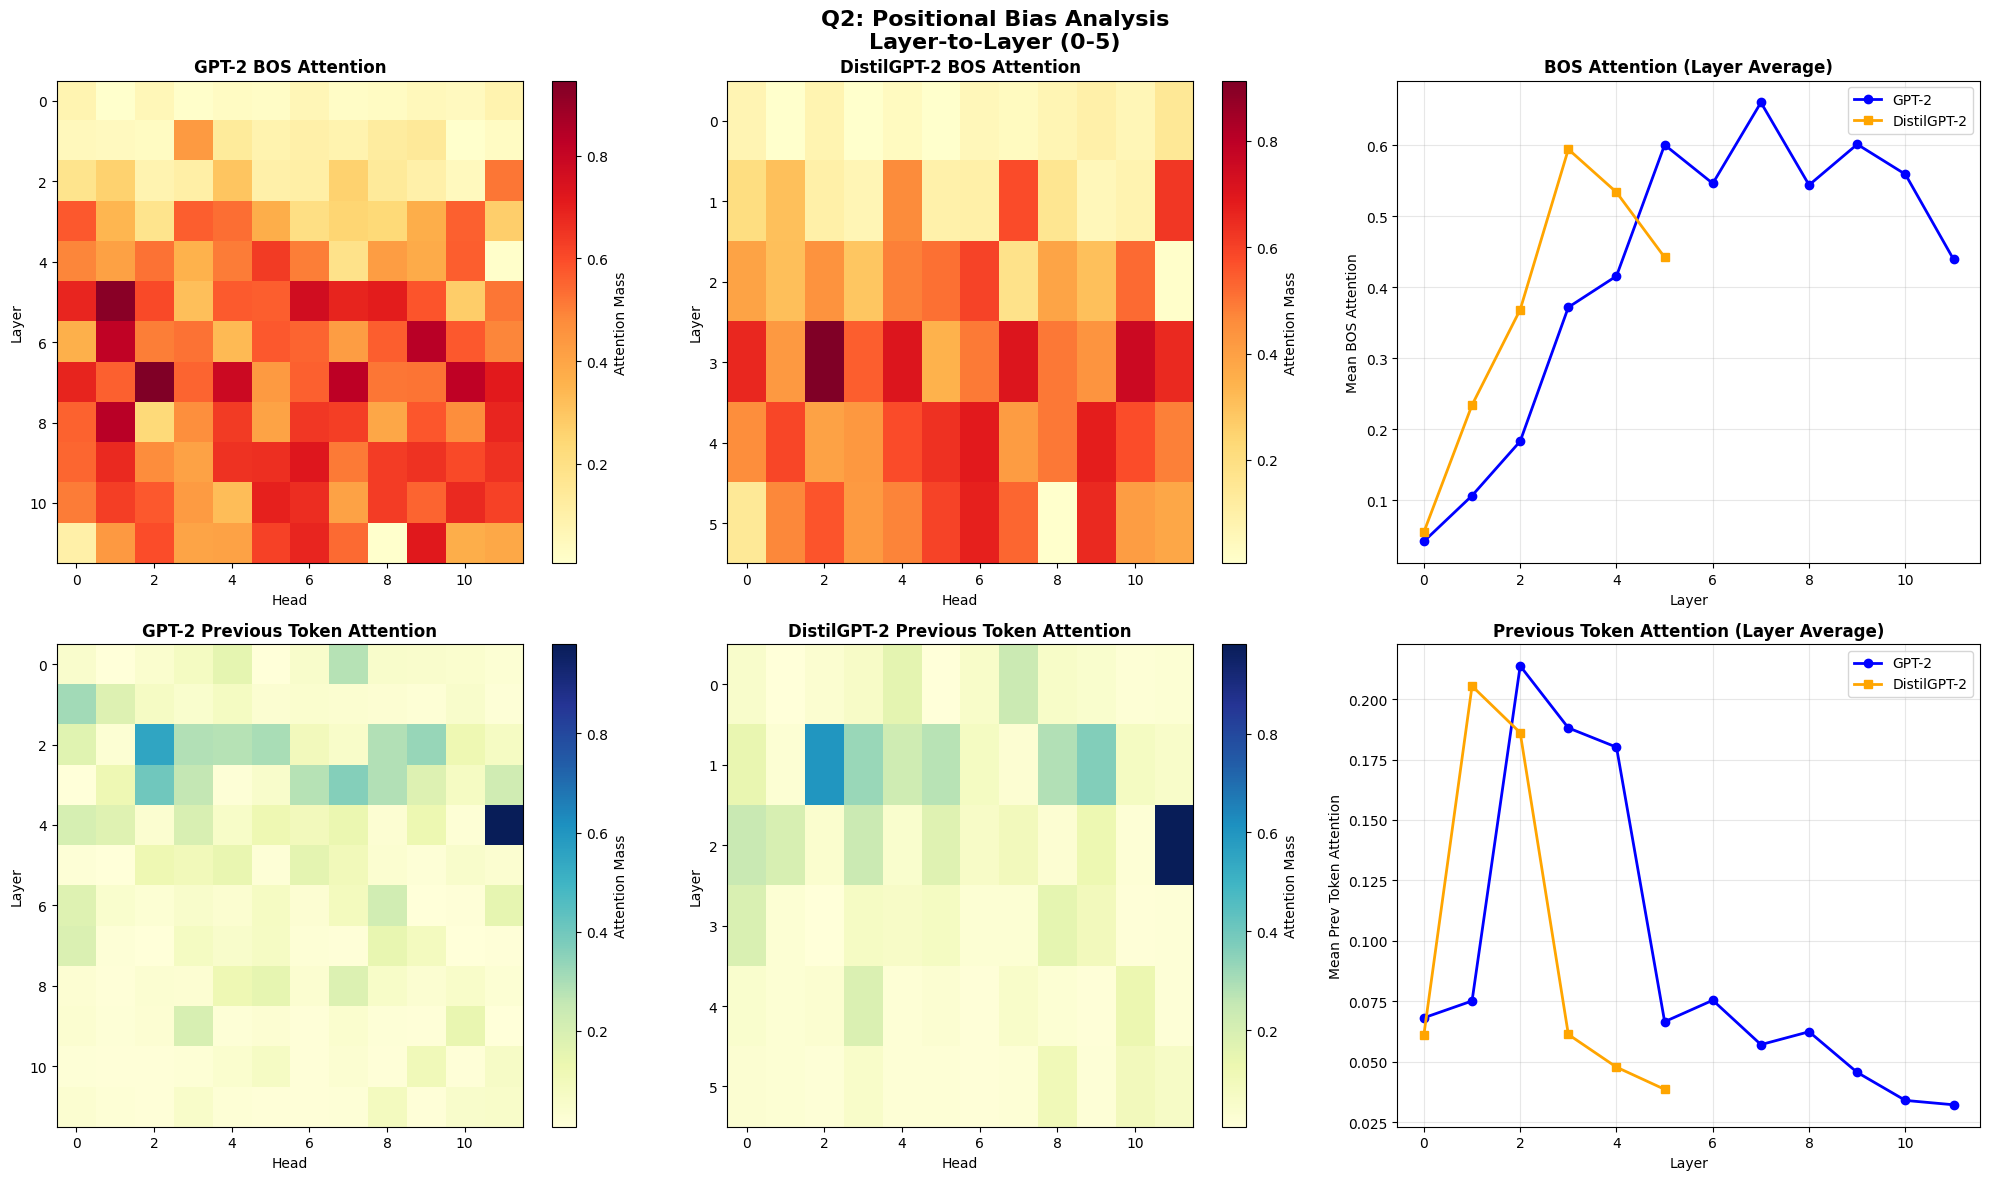

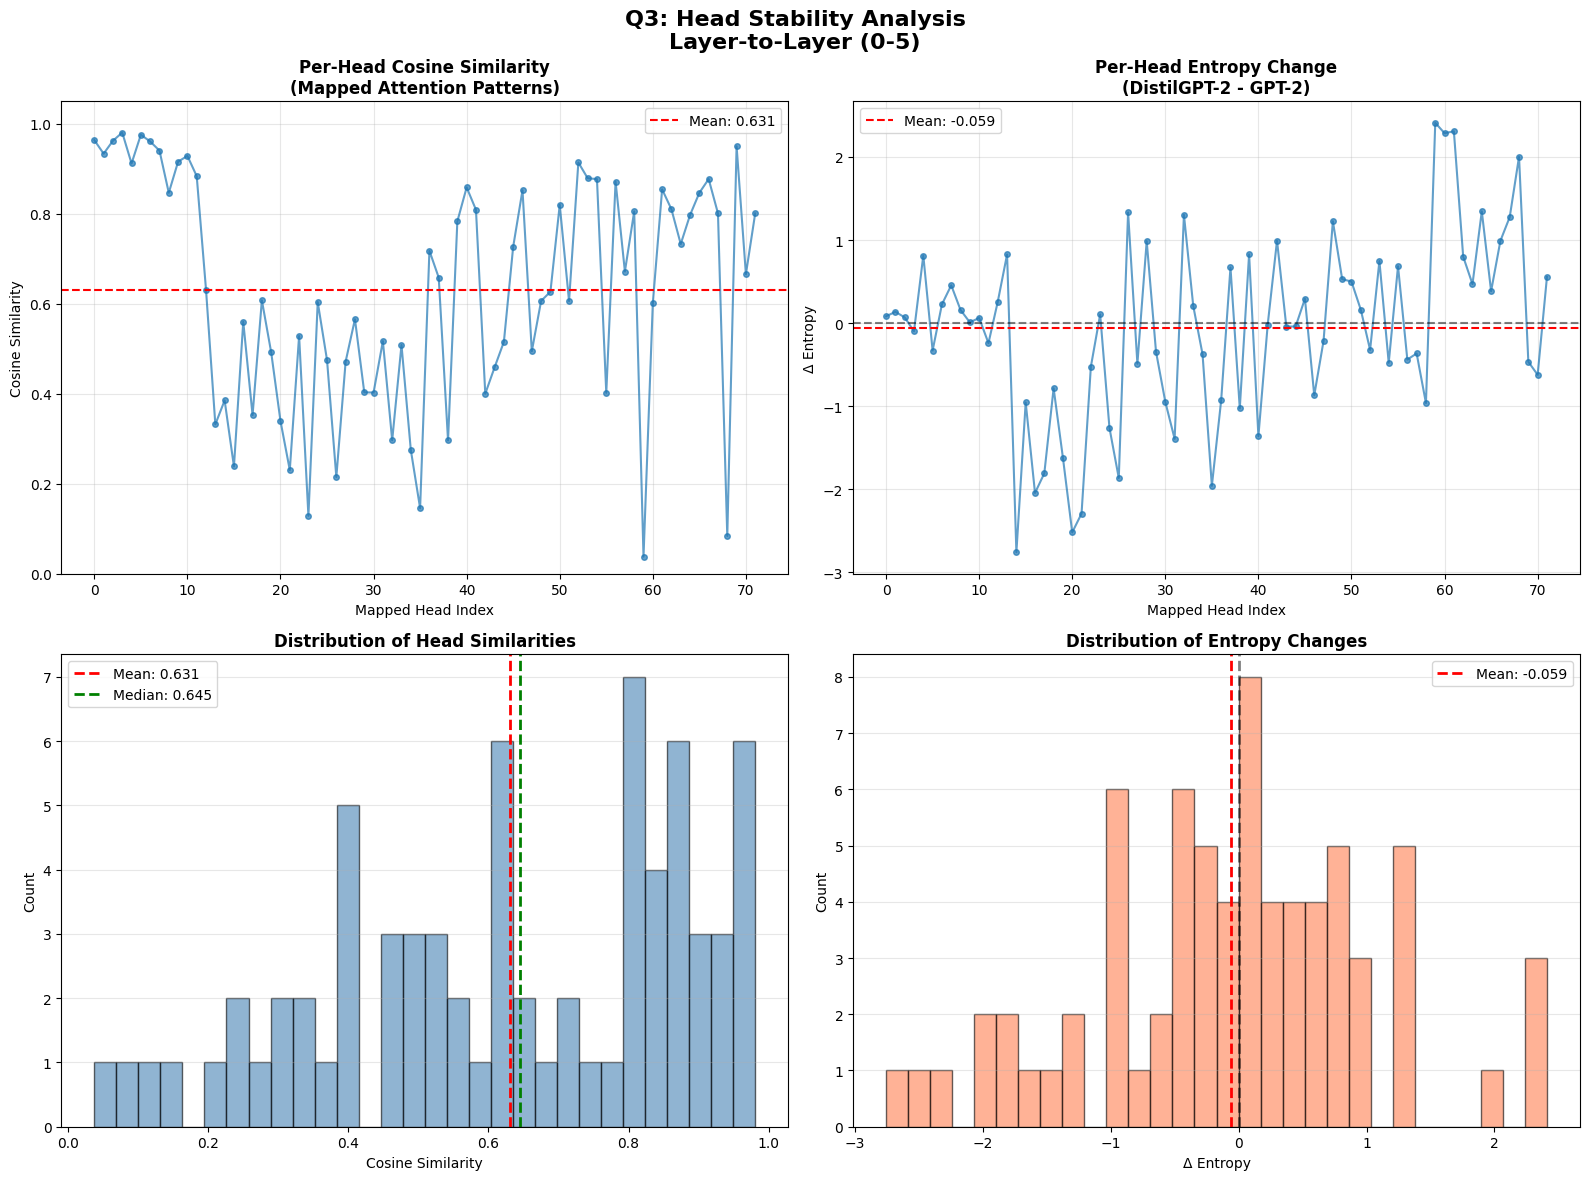


SUMMARY: LAYER_TO_LAYER COMPARISON

GPT-2 (12 layers, 144 heads):
  Mean Entropy: 2.0010
  Mean Effective Support: 11.1930
  Mean Top-1 Mass: 0.5069

DistilGPT-2 (6 layers, 72 heads):
  Mean Entropy: 2.0943
  Mean Effective Support: 12.1360
  Mean Top-1 Mass: 0.4930

Comparison (Mapped Heads):
  Mean Head Similarity: 0.6309 ± 0.2551
  Range: [0.0379, 0.9806]
  Mean Entropy Change: -0.0593 ± 1.1031

ANALYSIS COMPLETE!
Results saved to: gpt2_vs_distilgpt2_attention_analysis


In [2]:
import torch
import numpy as np
from pathlib import Path
from transformer_lens import HookedTransformer, HookedTransformerConfig
from transformer_lens.loading_from_pretrained import convert_gpt2_weights
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import json
from tqdm import tqdm
import torch.nn.functional as F
import random
from datasets import load_dataset

@dataclass
class AttentionMetrics:
    """Store attention pattern metrics for a single model."""
    entropy: np.ndarray  # [n_layers, n_heads]
    effective_support: np.ndarray  # exp(entropy)
    top1_mass: np.ndarray  # % of mass in top-1 token
    top3_mass: np.ndarray  # % of mass in top-3 tokens
    argmax_positions: List[np.ndarray]  # List of argmax positions per head
    relative_positions: List[np.ndarray]  # Relative positions (argmax - current)
    bos_attention: np.ndarray  # Attention to BOS token
    prev_token_attention: np.ndarray  # Attention to previous token
    eos_attention: np.ndarray  # Attention to EOS token
    attention_patterns: Dict[Tuple[int, int], List[torch.Tensor]]  # (layer, head) -> patterns


class AttentionPatternAnalyzer_GPT2vsDistilGPT2:
    """Analyze attention patterns comparing GPT-2 vs DistilGPT-2."""

    def __init__(
        self,
        output_dir: str = "/content/drive/MyDrive/IRP/GPT-2/gpt2_vs_distilgpt2_attention_analysis",
        device: str = "cuda" if torch.cuda.is_available() else "cpu",
        n_samples: int = 200,
        max_length: int = 256
    ):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.device = device
        self.n_samples = n_samples
        self.max_length = max_length

        # Initialize tokenizer (same for both models)
        print("Loading tokenizer...")
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token

        print(f"✓ Using device: {device}")

    def load_model_with_tl(self, model_name: str) -> Tuple[HookedTransformer, int, int]:
        """
        Load GPT-2 or DistilGPT-2 with TransformerLens.

        Returns:
            (model, n_layers, n_heads)
        """
        print(f"Loading {model_name} with TransformerLens...")

        # Load HuggingFace model
        hf_model = GPT2LMHeadModel.from_pretrained(model_name)

        # Get model config
        n_layers = hf_model.config.n_layer
        n_heads = hf_model.config.n_head
        d_model = hf_model.config.n_embd

        print(f"  Model config: {n_layers} layers, {n_heads} heads, d_model={d_model}")

        # Create TransformerLens config
        cfg = HookedTransformerConfig(
            n_layers=n_layers,
            d_model=d_model,
            n_heads=n_heads,
            d_head=d_model // n_heads,
            d_mlp=d_model * 4,
            d_vocab=hf_model.config.vocab_size,
            n_ctx=hf_model.config.n_ctx,
            act_fn="gelu_new",
            normalization_type="LN",
            device=str(self.device)
        )

        # Initialize blank TransformerLens model
        tl_model = HookedTransformer(cfg)

        # Convert weights
        tl_state_dict = convert_gpt2_weights(hf_model, cfg)
        tl_model.load_state_dict(tl_state_dict, strict=False)

        # Clean up HF model
        del hf_model
        torch.cuda.empty_cache()

        print(f"  ✓ Loaded successfully")

        return tl_model, n_layers, n_heads

    # def get_sample_texts(self) -> List[str]:
    #     """Generate or load sample texts for analysis."""
    #     print("\nLoading TinyStories dataset...")
    #     random.seed(42)

    #     dataset = load_dataset(
    #         "roneneldan/TinyStories",
    #         split="train",
    #         streaming=True
    #     ).shuffle(seed=42)

    #     prompts: List[str] = []
    #     stories_iter = iter(dataset)

    #     print(f"Sampling {self.n_samples} prompts...")

    #     for _ in tqdm(range(self.n_samples), desc="Sampling stories"):
    #         try:
    #             story = next(stories_iter)["text"]

    #             tokens = self.tokenizer.encode(
    #                 story,
    #                 add_special_tokens=False
    #             )

    #             if len(tokens) <= self.max_length:
    #                 sampled_tokens = tokens
    #             else:
    #                 start = random.randint(0, len(tokens) - self.max_length)
    #                 sampled_tokens = tokens[start:start + self.max_length]

    #             prompt = self.tokenizer.decode(
    #                 sampled_tokens,
    #                 clean_up_tokenization_spaces=True
    #             ).strip()

    #             prompts.append(prompt)

    #         except StopIteration:
    #             print(f"⚠️ Only {len(prompts)} stories available")
    #             break

    #     print(f"✓ Sampled {len(prompts)} prompts")
    #     return prompts
    def get_sample_texts(
        #
        self,
        min_tokens: int = 64,
        max_tokens: int = 256,
        seed: int = 42):
      #
      """Load sample texts from TinyStories dataset with token length filtering."""
      print("Loading TinyStories dataset...")
      random.seed(seed)

      try:
          dataset = load_dataset(
              "roneneldan/TinyStories",
              split="validation",
              streaming=True
          ).shuffle(seed=seed)

          samples = []
          stories_iter = iter(dataset)
          examined = 0

          print(f"Sampling {self.n_samples} prompts with token length in [{min_tokens}, {max_tokens}]...")

          while len(samples) < self.n_samples:
              try:
                  story = next(stories_iter)["text"]
                  examined += 1
                  if examined % 1000 == 0:
                      print(f"  Examined {examined} stories, found {len(samples)} so far...")

                  # tokens = self.gpt2_tokenizer.encode(story, add_special_tokens=False)
                  tokens = self.tokenizer.encode(story, add_special_tokens=False)
                  if min_tokens <= len(tokens) <= max_tokens:
                      prompt = self.tokenizer.decode(
                          tokens,
                          clean_up_tokenization_spaces=True
                      ).strip()
                      samples.append(prompt)

              except StopIteration:
                  print(f"⚠️ Only {len(samples)} stories available within the token range")
                  break

          print(f"✓ Sampled {len(samples)} prompts within token range")
          return samples

      except Exception as e:
          print(f"Dataset load failed: {e}. Using dummy data.")
          return ["This is a test sentence." for _ in range(self.n_samples)]

    def extract_attention_patterns(
        #
        self,
        gpt2_model: HookedTransformer,
        distilgpt2_model: HookedTransformer,
        texts: List[str],
        gpt2_n_layers: int,
        distil_n_layers: int,
        n_heads: int,
        layer_mapping: List[Tuple[int, int]]
        ) -> Tuple[AttentionMetrics, AttentionMetrics, np.ndarray, np.ndarray]:
        #
        """
        Extract attention patterns from both models simultaneously and compute
        head similarity on the fly — avoids storing raw attention matrices.
        """

        # ── per-sample accumulators for scalar metrics ──────────────────────────
        gpt2_entropy_all      = []
        gpt2_top1_all         = []
        gpt2_top3_all         = []
        gpt2_bos_all          = []
        gpt2_prev_all         = []
        gpt2_eos_all          = []
        gpt2_argmax_pos       = [[] for _ in range(gpt2_n_layers * n_heads)]
        gpt2_relative_pos     = [[] for _ in range(gpt2_n_layers * n_heads)]

        distil_entropy_all    = []
        distil_top1_all       = []
        distil_top3_all       = []
        distil_bos_all        = []
        distil_prev_all       = []
        distil_eos_all        = []
        distil_argmax_pos     = [[] for _ in range(distil_n_layers * n_heads)]
        distil_relative_pos   = [[] for _ in range(distil_n_layers * n_heads)]

        # ── per-head similarity accumulators (scalars only) ─────────────────────
        # keyed by (gpt2_layer, distil_layer, head)
        head_sim_accum = {
            (g, d, h): []
            for (g, d) in layer_mapping
            for h in range(n_heads)
        }

        gpt2_model.eval()
        distilgpt2_model.eval()

        with torch.no_grad():
            for text in tqdm(texts, desc="Processing samples"):

                # ── tokenize once, share across both models ──────────────────
                tokens = self.tokenizer(
                    text,
                    return_tensors='pt',
                    truncation=True,
                    max_length=self.max_length,
                    padding='max_length'
                )
                input_ids      = tokens['input_ids'].to(self.device)
                attention_mask = tokens['attention_mask'].to(self.device)
                seq_len        = attention_mask.sum().item()

                # ── forward passes ───────────────────────────────────────────
                _, gpt2_cache   = gpt2_model.run_with_cache(
                    input_ids, attention_mask=attention_mask
                )
                _, distil_cache = distilgpt2_model.run_with_cache(
                    input_ids, attention_mask=attention_mask
                )

                # ── helper: extract scalar metrics for one model's cache ─────
                def extract_scalars(cache, n_layers, entropy_all, top1_all,
                                    top3_all, bos_all, prev_all, eos_all,
                                    argmax_pos, relative_pos):
                    sample_entropy = []
                    sample_top1    = []
                    sample_top3    = []
                    sample_bos     = []
                    sample_prev    = []
                    sample_eos     = []

                    for layer in range(n_layers):
                        attn = cache['pattern', layer][0, :, :seq_len, :seq_len]
                        # attn: [n_heads, seq_len, seq_len]

                        for head in range(n_heads):
                            head_idx  = layer * n_heads + head
                            head_attn = attn[head]  # [seq, seq]

                            eps     = 1e-10
                            entropy = -(head_attn * torch.log(head_attn + eps)).sum(dim=-1).mean()
                            sample_entropy.append(entropy.cpu().item())

                            sorted_attn = torch.sort(head_attn, dim=-1, descending=True).values
                            sample_top1.append(sorted_attn[:, 0].mean().cpu().item())
                            sample_top3.append(sorted_attn[:, :3].sum(dim=-1).mean().cpu().item())

                            argmax      = torch.argmax(head_attn, dim=-1)
                            argmax_pos[head_idx].extend(argmax.cpu().numpy())

                            query_pos = torch.arange(seq_len, device=self.device)
                            relative_pos[head_idx].extend((argmax - query_pos).cpu().numpy())

                            sample_bos.append(head_attn[:, 0].mean().cpu().item())

                            prev_vals = [head_attn[i, i-1].cpu().item() for i in range(1, seq_len)]
                            sample_prev.append(float(np.mean(prev_vals)) if prev_vals else 0.0)

                            sample_eos.append(head_attn[:, seq_len-1].mean().cpu().item())

                    entropy_all.append(sample_entropy)
                    top1_all.append(sample_top1)
                    top3_all.append(sample_top3)
                    bos_all.append(sample_bos)
                    prev_all.append(sample_prev)
                    eos_all.append(sample_eos)

                extract_scalars(
                    gpt2_cache,   gpt2_n_layers,
                    gpt2_entropy_all, gpt2_top1_all, gpt2_top3_all,
                    gpt2_bos_all, gpt2_prev_all, gpt2_eos_all,
                    gpt2_argmax_pos, gpt2_relative_pos
                )
                extract_scalars(
                    distil_cache, distil_n_layers,
                    distil_entropy_all, distil_top1_all, distil_top3_all,
                    distil_bos_all, distil_prev_all, distil_eos_all,
                    distil_argmax_pos, distil_relative_pos
                )

                # ── compute per-head cosine similarity on the fly ────────────
                for (gpt2_layer, distil_layer) in layer_mapping:
                    gpt2_attn_layer   = gpt2_cache['pattern',   gpt2_layer][0,   :, :seq_len, :seq_len]
                    distil_attn_layer = distil_cache['pattern', distil_layer][0, :, :seq_len, :seq_len]

                    for head in range(n_heads):
                        g_flat = gpt2_attn_layer[head].flatten()
                        d_flat = distil_attn_layer[head].flatten()

                        cos_sim = F.cosine_similarity(
                            g_flat.unsqueeze(0),
                            d_flat.unsqueeze(0)
                        ).item()

                        head_sim_accum[(gpt2_layer, distil_layer, head)].append(cos_sim)

                # ── free caches immediately ──────────────────────────────────
                del gpt2_cache, distil_cache

        # ── aggregate scalar metrics into AttentionMetrics ───────────────────────
        def build_metrics(entropy_all, top1_all, top3_all, bos_all, prev_all,
                          eos_all, argmax_pos, relative_pos, n_layers):
            entropy             = np.array(entropy_all).mean(axis=0).reshape(n_layers, n_heads)
            return AttentionMetrics(
                entropy             = entropy,
                effective_support   = np.exp(entropy),
                top1_mass           = np.array(top1_all).mean(axis=0).reshape(n_layers, n_heads),
                top3_mass           = np.array(top3_all).mean(axis=0).reshape(n_layers, n_heads),
                argmax_positions    = argmax_pos,
                relative_positions  = relative_pos,
                bos_attention       = np.array(bos_all).mean(axis=0).reshape(n_layers, n_heads),
                prev_token_attention= np.array(prev_all).mean(axis=0).reshape(n_layers, n_heads),
                eos_attention       = np.array(eos_all).mean(axis=0).reshape(n_layers, n_heads),
                attention_patterns  = {}   # no longer stored
            )

        gpt2_metrics   = build_metrics(
            gpt2_entropy_all, gpt2_top1_all, gpt2_top3_all,
            gpt2_bos_all, gpt2_prev_all, gpt2_eos_all,
            gpt2_argmax_pos, gpt2_relative_pos, gpt2_n_layers
        )
        distil_metrics = build_metrics(
            distil_entropy_all, distil_top1_all, distil_top3_all,
            distil_bos_all, distil_prev_all, distil_eos_all,
            distil_argmax_pos, distil_relative_pos, distil_n_layers
        )

        # ── aggregate head similarities ──────────────────────────────────────────
        similarities     = np.array([
            np.mean(head_sim_accum[(g, d, h)])
            for (g, d) in layer_mapping
            for h in range(n_heads)
        ])
        entropy_changes  = np.array([
            distil_metrics.entropy[d, h] - gpt2_metrics.entropy[g, h]
            for (g, d) in layer_mapping
            for h in range(n_heads)
        ])

        return gpt2_metrics, distil_metrics, similarities, entropy_changes

    # def extract_attention_patterns(
    #     self,
    #     model: HookedTransformer,
    #     texts: List[str],
    #     n_layers: int,
    #     n_heads: int
    # ) -> AttentionMetrics:
    #     """Extract attention patterns and compute metrics."""

    #     # Storage for metrics across all samples
    #     all_entropy = []
    #     all_top1_mass = []
    #     all_top3_mass = []
    #     all_argmax_pos = [[] for _ in range(n_layers * n_heads)]
    #     all_relative_pos = [[] for _ in range(n_layers * n_heads)]
    #     all_bos_attn = []
    #     all_prev_attn = []
    #     all_eos_attn = []

    #     # Store raw patterns for similarity computation
    #     n_pattern_samples = min(10, len(texts))
    #     attention_patterns = {(layer, head): []
    #                         for layer in range(n_layers)
    #                         for head in range(n_heads)}

    #     model.eval()
    #     with torch.no_grad():
    #         for sample_idx, text in enumerate(tqdm(texts, desc="  Processing samples")):
    #             # Tokenize
    #             tokens = self.tokenizer(
    #                 text,
    #                 return_tensors='pt',
    #                 truncation=True,
    #                 max_length=self.max_length,
    #                 padding='max_length'
    #             )
    #             input_ids = tokens['input_ids'].to(self.device)
    #             attention_mask = tokens['attention_mask'].to(self.device)

    #             # Get actual sequence length (excluding padding)
    #             seq_len = attention_mask.sum().item()

    #             # Get attention patterns
    #             _, cache = model.run_with_cache(
    #                 input_ids,
    #                 attention_mask=attention_mask
    #             )

    #             # Process each layer
    #             sample_entropy = []
    #             sample_top1 = []
    #             sample_top3 = []
    #             sample_bos = []
    #             sample_prev = []
    #             sample_eos = []

    #             for layer in range(n_layers):
    #                 # Get attention pattern: [batch, heads, query_pos, key_pos]
    #                 attn = cache['pattern', layer][0]  # Remove batch dim: [heads, query, key]

    #                 # Only consider non-padding positions
    #                 attn = attn[:, :seq_len, :seq_len]

    #                 for head in range(n_heads):
    #                     head_idx = layer * n_heads + head
    #                     head_attn = attn[head]  # [query, key]

    #                     # Store raw patterns for first N samples
    #                     if sample_idx < n_pattern_samples:
    #                         attention_patterns[(layer, head)].append(head_attn.cpu())

    #                     # Q1: Attention Collapse Metrics
    #                     eps = 1e-10
    #                     entropy = -(head_attn * torch.log(head_attn + eps)).sum(dim=-1)
    #                     sample_entropy.append(entropy.mean().cpu().item())

    #                     # Top-k mass
    #                     sorted_attn, _ = torch.sort(head_attn, dim=-1, descending=True)
    #                     top1 = sorted_attn[:, 0].mean().cpu().item()
    #                     top3 = sorted_attn[:, :3].sum(dim=-1).mean().cpu().item()
    #                     sample_top1.append(top1)
    #                     sample_top3.append(top3)

    #                     # Q2: Positional Bias Metrics
    #                     argmax = torch.argmax(head_attn, dim=-1)
    #                     all_argmax_pos[head_idx].extend(argmax.cpu().numpy())

    #                     # Relative positions
    #                     query_positions = torch.arange(seq_len, device=self.device)
    #                     relative = argmax - query_positions
    #                     all_relative_pos[head_idx].extend(relative.cpu().numpy())

    #                     # BOS attention
    #                     bos_attn = head_attn[:, 0].mean().cpu().item()
    #                     sample_bos.append(bos_attn)

    #                     # Previous token attention
    #                     prev_attn_values = []
    #                     for i in range(1, seq_len):
    #                         prev_attn_values.append(head_attn[i, i-1].cpu().item())

    #                     if len(prev_attn_values) > 0:
    #                         prev_attn = np.mean(prev_attn_values)
    #                     else:
    #                         prev_attn = 0.0
    #                     sample_prev.append(prev_attn)

    #                     # EOS attention
    #                     eos_attn = head_attn[:, seq_len-1].mean().cpu().item()
    #                     sample_eos.append(eos_attn)

    #             all_entropy.append(sample_entropy)
    #             all_top1_mass.append(sample_top1)
    #             all_top3_mass.append(sample_top3)
    #             all_bos_attn.append(sample_bos)
    #             all_prev_attn.append(sample_prev)
    #             all_eos_attn.append(sample_eos)

    #     # Aggregate metrics
    #     entropy = np.array(all_entropy).mean(axis=0).reshape(n_layers, n_heads)
    #     effective_support = np.exp(entropy)
    #     top1_mass = np.array(all_top1_mass).mean(axis=0).reshape(n_layers, n_heads)
    #     top3_mass = np.array(all_top3_mass).mean(axis=0).reshape(n_layers, n_heads)
    #     bos_attention = np.array(all_bos_attn).mean(axis=0).reshape(n_layers, n_heads)
    #     prev_token_attention = np.array(all_prev_attn).mean(axis=0).reshape(n_layers, n_heads)
    #     eos_attention = np.array(all_eos_attn).mean(axis=0).reshape(n_layers, n_heads)

    #     return AttentionMetrics(
    #         entropy=entropy,
    #         effective_support=effective_support,
    #         top1_mass=top1_mass,
    #         top3_mass=top3_mass,
    #         argmax_positions=all_argmax_pos,
    #         relative_positions=all_relative_pos,
    #         bos_attention=bos_attention,
    #         prev_token_attention=prev_token_attention,
    #         eos_attention=eos_attention,
    #         attention_patterns=attention_patterns
    #     )

    def compute_head_similarity(
        self,
        gpt2_metrics: AttentionMetrics,
        distilgpt2_metrics: AttentionMetrics,
        layer_mapping: List[Tuple[int, int]]
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Compute per-head similarity between GPT-2 and DistilGPT-2.

        Args:
            gpt2_metrics: Metrics from GPT-2
            distilgpt2_metrics: Metrics from DistilGPT-2
            layer_mapping: List of (gpt2_layer, distil_layer) pairs

        Returns:
            (similarities, entropy_changes) for each mapped head
        """
        similarities = []
        entropy_changes = []

        for gpt2_layer, distil_layer in layer_mapping:
            # Both models have 12 heads per layer
            for head in range(12):
                # Get stored attention patterns
                gpt2_patterns = gpt2_metrics.attention_patterns.get((gpt2_layer, head), [])
                distil_patterns = distilgpt2_metrics.attention_patterns.get((distil_layer, head), [])

                if len(gpt2_patterns) > 0 and len(distil_patterns) > 0:
                    # Compute cosine similarity between attention patterns
                    head_similarities = []

                    for gpt2_attn, distil_attn in zip(gpt2_patterns, distil_patterns):
                        # Flatten attention matrices
                        gpt2_flat = gpt2_attn.flatten()
                        distil_flat = distil_attn.flatten()

                        # Compute cosine similarity
                        cos_sim = F.cosine_similarity(
                            gpt2_flat.unsqueeze(0),
                            distil_flat.unsqueeze(0)
                        ).item()

                        head_similarities.append(cos_sim)

                    # Average similarity across samples
                    avg_similarity = np.mean(head_similarities)
                    similarities.append(avg_similarity)
                else:
                    similarities.append(1.0)

                # Entropy change
                gpt2_entropy = gpt2_metrics.entropy[gpt2_layer, head]
                distil_entropy = distilgpt2_metrics.entropy[distil_layer, head]
                entropy_changes.append(distil_entropy - gpt2_entropy)

        return np.array(similarities), np.array(entropy_changes)

    # # def visualize_comparison(
    # #     self,
    # #     gpt2_metrics: AttentionMetrics,
    # #     distilgpt2_metrics: AttentionMetrics,
    # #     comparison_type: str = "proportional"
    # # ):
    # #     """Create comprehensive visualizations comparing the two models."""

    # #     # Create layer mapping based on comparison type
    # #     if comparison_type == "proportional":
    # #         # Map DistilGPT-2's 6 layers proportionally to GPT-2's 12 layers
    # #         layer_mapping = []
    # #         for distil_layer in range(6):
    # #             gpt2_layer = int(distil_layer * 11 / 5)  # Map 0-5 to 0-11
    # #             layer_mapping.append((gpt2_layer, distil_layer))
    # #         title_suffix = "Proportional Mapping"
    # #     else:  # layer_to_layer
    # #         # Compare same indices (0-5)
    # #         layer_mapping = [(i, i) for i in range(6)]
    # #         title_suffix = "Layer-to-Layer (0-5)"

    #     # =====================================================================
    #     # Q1: ATTENTION COLLAPSE ANALYSIS
    #     # =====================================================================
    #     fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    #     fig.suptitle(f'Q1: Attention Collapse Analysis\n{title_suffix}',
    #                  fontsize=16, fontweight='bold')

    #     # Plot 1: GPT-2 Entropy Heatmap
    #     ax = axes[0, 0]
    #     im = ax.imshow(gpt2_metrics.entropy, cmap='RdYlGn', aspect='auto')
    #     ax.set_title('GPT-2 Entropy (12 layers)', fontweight='bold')
    #     ax.set_xlabel('Head')
    #     ax.set_ylabel('Layer')
    #     plt.colorbar(im, ax=ax, label='Entropy (bits)')

    #     # Plot 2: DistilGPT-2 Entropy Heatmap
    #     ax = axes[0, 1]
    #     im = ax.imshow(distilgpt2_metrics.entropy, cmap='RdYlGn', aspect='auto')
    #     ax.set_title('DistilGPT-2 Entropy (6 layers)', fontweight='bold')
    #     ax.set_xlabel('Head')
    #     ax.set_ylabel('Layer')
    #     plt.colorbar(im, ax=ax, label='Entropy (bits)')

    #     # Plot 3: Mapped Entropy Comparison
    #     ax = axes[0, 2]
    #     for gpt2_layer, distil_layer in layer_mapping:
    #         gpt2_entropy_vals = gpt2_metrics.entropy[gpt2_layer, :]
    #         distil_entropy_vals = distilgpt2_metrics.entropy[distil_layer, :]

    #         ax.scatter([gpt2_layer] * 12, gpt2_entropy_vals,
    #                   alpha=0.6, s=50, color='blue', label='GPT-2' if gpt2_layer == layer_mapping[0][0] else '')
    #         ax.scatter([gpt2_layer + 0.2] * 12, distil_entropy_vals,
    #                   alpha=0.6, s=50, color='orange', marker='s',
    #                   label='DistilGPT-2' if gpt2_layer == layer_mapping[0][0] else '')

    #     ax.set_title('Entropy Comparison (Mapped Layers)', fontweight='bold')
    #     ax.set_xlabel('GPT-2 Layer Index')
    #     ax.set_ylabel('Entropy')
    #     ax.legend()
    #     ax.grid(alpha=0.3)

    #     # Plot 4: Top-1 Mass Comparison
    #     ax = axes[1, 0]
    #     gpt2_top1_flat = gpt2_metrics.top1_mass.flatten()
    #     distil_top1_flat = distilgpt2_metrics.top1_mass.flatten()

    #     x_gpt2 = np.arange(len(gpt2_top1_flat))
    #     x_distil = np.arange(len(distil_top1_flat))

    #     ax.plot(x_gpt2, gpt2_top1_flat, alpha=0.7, label='GPT-2 (144 heads)',
    #            color='blue', linewidth=2)
    #     ax.plot(x_distil, distil_top1_flat, alpha=0.7, label='DistilGPT-2 (72 heads)',
    #            color='orange', linewidth=2)

    #     ax.set_title('Top-1 Token Mass', fontweight='bold')
    #     ax.set_xlabel('Head Index (layer × 12 + head)')
    #     ax.set_ylabel('Attention Mass')
    #     ax.legend()
    #     ax.grid(alpha=0.3)

    #     # Plot 5: Effective Support Comparison
    #     ax = axes[1, 1]
    #     im = ax.imshow(gpt2_metrics.effective_support, cmap='viridis', aspect='auto')
    #     ax.set_title('GPT-2 Effective Support exp(H)', fontweight='bold')
    #     ax.set_xlabel('Head')
    #     ax.set_ylabel('Layer')
    #     plt.colorbar(im, ax=ax, label='Support Size')

    #     # Plot 6: DistilGPT-2 Effective Support
    #     ax = axes[1, 2]
    #     im = ax.imshow(distilgpt2_metrics.effective_support, cmap='viridis', aspect='auto')
    #     ax.set_title('DistilGPT-2 Effective Support exp(H)', fontweight='bold')
    #     ax.set_xlabel('Head')
    #     ax.set_ylabel('Layer')
    #     plt.colorbar(im, ax=ax, label='Support Size')

    #     plt.tight_layout()
    #     plt.savefig(self.output_dir / f'q1_collapse_{comparison_type}.png',
    #                dpi=300, bbox_inches='tight')
    #     plt.show()
    #     plt.close()

    #     # =====================================================================
    #     # Q2: POSITIONAL BIAS ANALYSIS
    #     # =====================================================================
    #     fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    #     fig.suptitle(f'Q2: Positional Bias Analysis\n{title_suffix}',
    #                  fontsize=16, fontweight='bold')

    #     # Plot 1: BOS Attention
    #     ax = axes[0, 0]
    #     im1 = ax.imshow(gpt2_metrics.bos_attention, cmap='YlOrRd', aspect='auto')
    #     ax.set_title('GPT-2 BOS Attention', fontweight='bold')
    #     ax.set_xlabel('Head')
    #     ax.set_ylabel('Layer')
    #     plt.colorbar(im1, ax=ax, label='Attention Mass')

    #     # Plot 2: DistilGPT-2 BOS Attention
    #     ax = axes[0, 1]
    #     im2 = ax.imshow(distilgpt2_metrics.bos_attention, cmap='YlOrRd', aspect='auto')
    #     ax.set_title('DistilGPT-2 BOS Attention', fontweight='bold')
    #     ax.set_xlabel('Head')
    #     ax.set_ylabel('Layer')
    #     plt.colorbar(im2, ax=ax, label='Attention Mass')

    #     # Plot 3: BOS Attention Comparison (per head average)
    #     ax = axes[0, 2]
    #     gpt2_bos_mean = gpt2_metrics.bos_attention.mean(axis=1)
    #     distil_bos_mean = distilgpt2_metrics.bos_attention.mean(axis=1)

    #     x_gpt2 = np.arange(12)
    #     x_distil = np.arange(6)

    #     ax.plot(x_gpt2, gpt2_bos_mean, marker='o', label='GPT-2',
    #            color='blue', linewidth=2, markersize=6)
    #     ax.plot(x_distil, distil_bos_mean, marker='s', label='DistilGPT-2',
    #            color='orange', linewidth=2, markersize=6)

    #     ax.set_title('BOS Attention (Layer Average)', fontweight='bold')
    #     ax.set_xlabel('Layer')
    #     ax.set_ylabel('Mean BOS Attention')
    #     ax.legend()
    #     ax.grid(alpha=0.3)

    #     # Plot 4: Previous Token Attention
    #     ax = axes[1, 0]
    #     im3 = ax.imshow(gpt2_metrics.prev_token_attention, cmap='YlGnBu', aspect='auto')
    #     ax.set_title('GPT-2 Previous Token Attention', fontweight='bold')
    #     ax.set_xlabel('Head')
    #     ax.set_ylabel('Layer')
    #     plt.colorbar(im3, ax=ax, label='Attention Mass')

    #     # Plot 5: DistilGPT-2 Previous Token Attention
    #     ax = axes[1, 1]
    #     im4 = ax.imshow(distilgpt2_metrics.prev_token_attention, cmap='YlGnBu', aspect='auto')
    #     ax.set_title('DistilGPT-2 Previous Token Attention', fontweight='bold')
    #     ax.set_xlabel('Head')
    #     ax.set_ylabel('Layer')
    #     plt.colorbar(im4, ax=ax, label='Attention Mass')

    #     # Plot 6: Prev Token Attention Comparison
    #     ax = axes[1, 2]
    #     gpt2_prev_mean = gpt2_metrics.prev_token_attention.mean(axis=1)
    #     distil_prev_mean = distilgpt2_metrics.prev_token_attention.mean(axis=1)

    #     ax.plot(x_gpt2, gpt2_prev_mean, marker='o', label='GPT-2',
    #            color='blue', linewidth=2, markersize=6)
    #     ax.plot(x_distil, distil_prev_mean, marker='s', label='DistilGPT-2',
    #            color='orange', linewidth=2, markersize=6)

    #     ax.set_title('Previous Token Attention (Layer Average)', fontweight='bold')
    #     ax.set_xlabel('Layer')
    #     ax.set_ylabel('Mean Prev Token Attention')
    #     ax.legend()
    #     ax.grid(alpha=0.3)

    #     plt.tight_layout()
    #     plt.savefig(self.output_dir / f'q2_positional_{comparison_type}.png',
    #                dpi=300, bbox_inches='tight')
    #     plt.show()
    #     plt.close()

    #     # =====================================================================
    #     # Q3: HEAD STABILITY ANALYSIS (only for mapped layers)
    #     # =====================================================================
    #     similarities, entropy_changes = self.compute_head_similarity(
    #         gpt2_metrics, distilgpt2_metrics, layer_mapping
    #     )

    #     fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    #     fig.suptitle(f'Q3: Head Stability Analysis\n{title_suffix}',
    #                  fontsize=16, fontweight='bold')

    #     # Plot 1: Cosine Similarity per Mapped Head
    #     ax = axes[0, 0]
    #     x = np.arange(len(similarities))
    #     ax.plot(x, similarities, marker='o', linestyle='-', alpha=0.7, markersize=4)
    #     ax.axhline(y=similarities.mean(), color='red', linestyle='--',
    #               label=f'Mean: {similarities.mean():.3f}')
    #     ax.set_title('Per-Head Cosine Similarity\n(Mapped Attention Patterns)', fontweight='bold')
    #     ax.set_xlabel('Mapped Head Index')
    #     ax.set_ylabel('Cosine Similarity')
    #     ax.set_ylim([0, 1.05])
    #     ax.legend()
    #     ax.grid(alpha=0.3)

    #     # Plot 2: Entropy Change per Mapped Head
    #     ax = axes[0, 1]
    #     ax.plot(x, entropy_changes, marker='o', linestyle='-', alpha=0.7, markersize=4)
    #     ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    #     ax.axhline(y=entropy_changes.mean(), color='red', linestyle='--',
    #               label=f'Mean: {entropy_changes.mean():.3f}')
    #     ax.set_title('Per-Head Entropy Change\n(DistilGPT-2 - GPT-2)', fontweight='bold')
    #     ax.set_xlabel('Mapped Head Index')
    #     ax.set_ylabel('Δ Entropy')
    #     ax.legend()
    #     ax.grid(alpha=0.3)

    #     # Plot 3: Similarity Distribution
    #     ax = axes[1, 0]
    #     ax.hist(similarities, bins=30, alpha=0.6, edgecolor='black', color='steelblue')
    #     ax.axvline(x=similarities.mean(), color='red', linestyle='--', linewidth=2,
    #               label=f'Mean: {similarities.mean():.3f}')
    #     ax.axvline(x=np.median(similarities), color='green', linestyle='--', linewidth=2,
    #               label=f'Median: {np.median(similarities):.3f}')
    #     ax.set_title('Distribution of Head Similarities', fontweight='bold')
    #     ax.set_xlabel('Cosine Similarity')
    #     ax.set_ylabel('Count')
    #     ax.legend()
    #     ax.grid(alpha=0.3, axis='y')

    #     # Plot 4: Entropy Change Distribution
    #     ax = axes[1, 1]
    #     ax.hist(entropy_changes, bins=30, alpha=0.6, edgecolor='black', color='coral')
    #     ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
    #     ax.axvline(x=entropy_changes.mean(), color='red', linestyle='--', linewidth=2,
    #               label=f'Mean: {entropy_changes.mean():.3f}')
    #     ax.set_title('Distribution of Entropy Changes', fontweight='bold')
    #     ax.set_xlabel('Δ Entropy')
    #     ax.set_ylabel('Count')
    #     ax.legend()
    #     ax.grid(alpha=0.3, axis='y')

    #     plt.tight_layout()
    #     plt.savefig(self.output_dir / f'q3_stability_{comparison_type}.png',
    #                dpi=300, bbox_inches='tight')
    #     plt.show()
    #     plt.close()

    #     # Return metrics for summary
    #     return similarities, entropy_changes

    def visualize_comparison(
        #
        self,
        gpt2_metrics: AttentionMetrics,
        distilgpt2_metrics: AttentionMetrics,
        comparison_type: str = "proportional",
        similarities: np.ndarray = None,
        entropy_changes: np.ndarray = None ):
      #
        """Create comprehensive visualizations comparing the two models."""

        if comparison_type == "proportional":
            layer_mapping = []
            for distil_layer in range(6):
                gpt2_layer = int(distil_layer * 11 / 5)
                layer_mapping.append((gpt2_layer, distil_layer))
            title_suffix = "Proportional Mapping"
        else:
            layer_mapping = [(i, i) for i in range(6)]
            title_suffix = "Layer-to-Layer (0-5)"

        # =====================================================================
        # Q1: ATTENTION COLLAPSE ANALYSIS
        # =====================================================================
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'Q1: Attention Collapse Analysis\n{title_suffix}',
                    fontsize=16, fontweight='bold')

        ax = axes[0, 0]
        im = ax.imshow(gpt2_metrics.entropy, cmap='RdYlGn', aspect='auto')
        ax.set_title('GPT-2 Entropy (12 layers)', fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        plt.colorbar(im, ax=ax, label='Entropy (bits)')

        ax = axes[0, 1]
        im = ax.imshow(distilgpt2_metrics.entropy, cmap='RdYlGn', aspect='auto')
        ax.set_title('DistilGPT-2 Entropy (6 layers)', fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        plt.colorbar(im, ax=ax, label='Entropy (bits)')

        ax = axes[0, 2]
        for gpt2_layer, distil_layer in layer_mapping:
            gpt2_entropy_vals = gpt2_metrics.entropy[gpt2_layer, :]
            distil_entropy_vals = distilgpt2_metrics.entropy[distil_layer, :]
            ax.scatter([gpt2_layer] * 12, gpt2_entropy_vals,
                      alpha=0.6, s=50, color='blue',
                      label='GPT-2' if gpt2_layer == layer_mapping[0][0] else '')
            ax.scatter([gpt2_layer + 0.2] * 12, distil_entropy_vals,
                      alpha=0.6, s=50, color='orange', marker='s',
                      label='DistilGPT-2' if gpt2_layer == layer_mapping[0][0] else '')
        ax.set_title('Entropy Comparison (Mapped Layers)', fontweight='bold')
        ax.set_xlabel('GPT-2 Layer Index')
        ax.set_ylabel('Entropy')
        ax.legend()
        ax.grid(alpha=0.3)

        ax = axes[1, 0]
        gpt2_top1_flat = gpt2_metrics.top1_mass.flatten()
        distil_top1_flat = distilgpt2_metrics.top1_mass.flatten()
        x_gpt2 = np.arange(len(gpt2_top1_flat))
        x_distil = np.arange(len(distil_top1_flat))
        ax.plot(x_gpt2, gpt2_top1_flat, alpha=0.7, label='GPT-2 (144 heads)',
              color='blue', linewidth=2)
        ax.plot(x_distil, distil_top1_flat, alpha=0.7, label='DistilGPT-2 (72 heads)',
              color='orange', linewidth=2)
        ax.set_title('Top-1 Token Mass', fontweight='bold')
        ax.set_xlabel('Head Index (layer × 12 + head)')
        ax.set_ylabel('Attention Mass')
        ax.legend()
        ax.grid(alpha=0.3)

        ax = axes[1, 1]
        im = ax.imshow(gpt2_metrics.effective_support, cmap='viridis', aspect='auto')
        ax.set_title('GPT-2 Effective Support exp(H)', fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        plt.colorbar(im, ax=ax, label='Support Size')

        ax = axes[1, 2]
        im = ax.imshow(distilgpt2_metrics.effective_support, cmap='viridis', aspect='auto')
        ax.set_title('DistilGPT-2 Effective Support exp(H)', fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        plt.colorbar(im, ax=ax, label='Support Size')

        plt.tight_layout()
        plt.savefig(self.output_dir / f'q1_collapse_{comparison_type}.png',
                  dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        # =====================================================================
        # Q2: POSITIONAL BIAS ANALYSIS
        # =====================================================================
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'Q2: Positional Bias Analysis\n{title_suffix}',
                    fontsize=16, fontweight='bold')

        ax = axes[0, 0]
        im1 = ax.imshow(gpt2_metrics.bos_attention, cmap='YlOrRd', aspect='auto')
        ax.set_title('GPT-2 BOS Attention', fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        plt.colorbar(im1, ax=ax, label='Attention Mass')

        ax = axes[0, 1]
        im2 = ax.imshow(distilgpt2_metrics.bos_attention, cmap='YlOrRd', aspect='auto')
        ax.set_title('DistilGPT-2 BOS Attention', fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        plt.colorbar(im2, ax=ax, label='Attention Mass')

        ax = axes[0, 2]
        gpt2_bos_mean = gpt2_metrics.bos_attention.mean(axis=1)
        distil_bos_mean = distilgpt2_metrics.bos_attention.mean(axis=1)
        x_gpt2 = np.arange(12)
        x_distil = np.arange(6)
        ax.plot(x_gpt2, gpt2_bos_mean, marker='o', label='GPT-2',
              color='blue', linewidth=2, markersize=6)
        ax.plot(x_distil, distil_bos_mean, marker='s', label='DistilGPT-2',
              color='orange', linewidth=2, markersize=6)
        ax.set_title('BOS Attention (Layer Average)', fontweight='bold')
        ax.set_xlabel('Layer')
        ax.set_ylabel('Mean BOS Attention')
        ax.legend()
        ax.grid(alpha=0.3)

        ax = axes[1, 0]
        im3 = ax.imshow(gpt2_metrics.prev_token_attention, cmap='YlGnBu', aspect='auto')
        ax.set_title('GPT-2 Previous Token Attention', fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        plt.colorbar(im3, ax=ax, label='Attention Mass')

        ax = axes[1, 1]
        im4 = ax.imshow(distilgpt2_metrics.prev_token_attention, cmap='YlGnBu', aspect='auto')
        ax.set_title('DistilGPT-2 Previous Token Attention', fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        plt.colorbar(im4, ax=ax, label='Attention Mass')

        ax = axes[1, 2]
        gpt2_prev_mean = gpt2_metrics.prev_token_attention.mean(axis=1)
        distil_prev_mean = distilgpt2_metrics.prev_token_attention.mean(axis=1)
        ax.plot(x_gpt2, gpt2_prev_mean, marker='o', label='GPT-2',
              color='blue', linewidth=2, markersize=6)
        ax.plot(x_distil, distil_prev_mean, marker='s', label='DistilGPT-2',
              color='orange', linewidth=2, markersize=6)
        ax.set_title('Previous Token Attention (Layer Average)', fontweight='bold')
        ax.set_xlabel('Layer')
        ax.set_ylabel('Mean Prev Token Attention')
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(self.output_dir / f'q2_positional_{comparison_type}.png',
                  dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        # =====================================================================
        # Q3: HEAD STABILITY ANALYSIS
        # =====================================================================
        # Use pre-computed similarities and entropy_changes from
        # extract_attention_patterns rather than recomputing from empty
        # attention_patterns dicts.
        if similarities is None or entropy_changes is None:
            similarities, entropy_changes = self.compute_head_similarity(
                gpt2_metrics, distilgpt2_metrics, layer_mapping
            )

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'Q3: Head Stability Analysis\n{title_suffix}',
                    fontsize=16, fontweight='bold')

        ax = axes[0, 0]
        x = np.arange(len(similarities))
        ax.plot(x, similarities, marker='o', linestyle='-', alpha=0.7, markersize=4)
        ax.axhline(y=similarities.mean(), color='red', linestyle='--',
                  label=f'Mean: {similarities.mean():.3f}')
        ax.set_title('Per-Head Cosine Similarity\n(Mapped Attention Patterns)', fontweight='bold')
        ax.set_xlabel('Mapped Head Index')
        ax.set_ylabel('Cosine Similarity')
        ax.set_ylim([0, 1.05])
        ax.legend()
        ax.grid(alpha=0.3)

        ax = axes[0, 1]
        ax.plot(x, entropy_changes, marker='o', linestyle='-', alpha=0.7, markersize=4)
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax.axhline(y=entropy_changes.mean(), color='red', linestyle='--',
                  label=f'Mean: {entropy_changes.mean():.3f}')
        ax.set_title('Per-Head Entropy Change\n(DistilGPT-2 - GPT-2)', fontweight='bold')
        ax.set_xlabel('Mapped Head Index')
        ax.set_ylabel('Δ Entropy')
        ax.legend()
        ax.grid(alpha=0.3)

        ax = axes[1, 0]
        ax.hist(similarities, bins=30, alpha=0.6, edgecolor='black', color='steelblue')
        ax.axvline(x=similarities.mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {similarities.mean():.3f}')
        ax.axvline(x=np.median(similarities), color='green', linestyle='--', linewidth=2,
                  label=f'Median: {np.median(similarities):.3f}')
        ax.set_title('Distribution of Head Similarities', fontweight='bold')
        ax.set_xlabel('Cosine Similarity')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(alpha=0.3, axis='y')

        ax = axes[1, 1]
        ax.hist(entropy_changes, bins=30, alpha=0.6, edgecolor='black', color='coral')
        ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
        ax.axvline(x=entropy_changes.mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {entropy_changes.mean():.3f}')
        ax.set_title('Distribution of Entropy Changes', fontweight='bold')
        ax.set_xlabel('Δ Entropy')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig(self.output_dir / f'q3_stability_{comparison_type}.png',
                  dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        return similarities, entropy_changes
    def create_summary(
        self,
        gpt2_metrics: AttentionMetrics,
        distilgpt2_metrics: AttentionMetrics,
        comparison_type: str,
        similarities: np.ndarray,
        entropy_changes: np.ndarray
    ):
        """Create and save summary statistics."""

        summary = {
            'comparison_type': comparison_type,
            'gpt2': {
                'n_layers': 12,
                'n_heads': 12,
                'total_heads': 144,
                'entropy_mean': float(gpt2_metrics.entropy.mean()),
                'entropy_std': float(gpt2_metrics.entropy.std()),
                'effective_support_mean': float(gpt2_metrics.effective_support.mean()),
                'top1_mass_mean': float(gpt2_metrics.top1_mass.mean()),
                'top3_mass_mean': float(gpt2_metrics.top3_mass.mean()),
                'bos_attention_mean': float(gpt2_metrics.bos_attention.mean()),
                'prev_token_attention_mean': float(gpt2_metrics.prev_token_attention.mean()),
            },
            'distilgpt2': {
                'n_layers': 6,
                'n_heads': 12,
                'total_heads': 72,
                'entropy_mean': float(distilgpt2_metrics.entropy.mean()),
                'entropy_std': float(distilgpt2_metrics.entropy.std()),
                'effective_support_mean': float(distilgpt2_metrics.effective_support.mean()),
                'top1_mass_mean': float(distilgpt2_metrics.top1_mass.mean()),
                'top3_mass_mean': float(distilgpt2_metrics.top3_mass.mean()),
                'bos_attention_mean': float(distilgpt2_metrics.bos_attention.mean()),
                'prev_token_attention_mean': float(distilgpt2_metrics.prev_token_attention.mean()),
            },
            'comparison': {
                'head_similarity_mean': float(similarities.mean()),
                'head_similarity_std': float(similarities.std()),
                'head_similarity_min': float(similarities.min()),
                'head_similarity_max': float(similarities.max()),
                'entropy_change_mean': float(entropy_changes.mean()),
                'entropy_change_std': float(entropy_changes.std()),
            }
        }

        # Save to JSON
        with open(self.output_dir / f'summary_{comparison_type}.json', 'w') as f:
            json.dump(summary, f, indent=2)

        # Print summary
        print(f"\n{'='*80}")
        print(f"SUMMARY: {comparison_type.upper()} COMPARISON")
        print(f"{'='*80}")

        print(f"\nGPT-2 (12 layers, 144 heads):")
        print(f"  Mean Entropy: {summary['gpt2']['entropy_mean']:.4f}")
        print(f"  Mean Effective Support: {summary['gpt2']['effective_support_mean']:.4f}")
        print(f"  Mean Top-1 Mass: {summary['gpt2']['top1_mass_mean']:.4f}")

        print(f"\nDistilGPT-2 (6 layers, 72 heads):")
        print(f"  Mean Entropy: {summary['distilgpt2']['entropy_mean']:.4f}")
        print(f"  Mean Effective Support: {summary['distilgpt2']['effective_support_mean']:.4f}")
        print(f"  Mean Top-1 Mass: {summary['distilgpt2']['top1_mass_mean']:.4f}")

        print(f"\nComparison (Mapped Heads):")
        print(f"  Mean Head Similarity: {summary['comparison']['head_similarity_mean']:.4f} ± {summary['comparison']['head_similarity_std']:.4f}")
        print(f"  Range: [{summary['comparison']['head_similarity_min']:.4f}, {summary['comparison']['head_similarity_max']:.4f}]")
        print(f"  Mean Entropy Change: {summary['comparison']['entropy_change_mean']:.4f} ± {summary['comparison']['entropy_change_std']:.4f}")


    def run_full_analysis(self):
      #
      print("=" * 80)
      print("ATTENTION PATTERN ANALYSIS: GPT-2 vs DistilGPT-2")
      print("=" * 80)

      gpt2_model,   gpt2_n_layers,  gpt2_n_heads  = self.load_model_with_tl("gpt2")
      distil_model, distil_n_layers, distil_n_heads = self.load_model_with_tl("distilgpt2")

      texts = self.get_sample_texts()

      for comparison_type in ["proportional", "layer_to_layer"]:
          # Build layer mapping
          if comparison_type == "proportional":
              layer_mapping = [
                  (int(d * 11 / 5), d) for d in range(distil_n_layers)
              ]
          else:
              layer_mapping = [(i, i) for i in range(distil_n_layers)]

          print(f"\n{'='*80}")
          print(f"RUNNING: {comparison_type.upper()}")
          print(f"{'='*80}")

          gpt2_metrics, distil_metrics, similarities, entropy_changes = \
              self.extract_attention_patterns(
                  gpt2_model, distil_model, texts,
                  gpt2_n_layers, distil_n_layers, gpt2_n_heads,
                  layer_mapping
              )

          # self.visualize_comparison(gpt2_metrics, distil_metrics, comparison_type)
          self.visualize_comparison( gpt2_metrics, distil_metrics, comparison_type, similarities, entropy_changes)
          self.create_summary(
              gpt2_metrics, distil_metrics,
              comparison_type, similarities, entropy_changes
          )

      del gpt2_model, distil_model
      torch.cuda.empty_cache()

      print(f"\n{'='*80}")
      print("ANALYSIS COMPLETE!")
      print(f"Results saved to: {self.output_dir}")
      print(f"{'='*80}")


if __name__ == "__main__":
    analyzer = AttentionPatternAnalyzer_GPT2vsDistilGPT2(
        output_dir="gpt2_vs_distilgpt2_attention_analysis",
        device="cuda" if torch.cuda.is_available() else "cpu",
        n_samples=1000,
        max_length=256
    )

    analyzer.run_full_analysis()

# SAE based Analysis

In [ ]:
pip install sae-lens

In [ ]:
import torch
import numpy as np
from pathlib import Path
from transformer_lens import HookedTransformer
from transformer_lens.loading_from_pretrained import convert_gpt2_weights
from transformer_lens import HookedTransformerConfig
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from sae_lens import SAE
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import json
import gc
from tqdm.auto import tqdm
from datasets import load_dataset
import random
from typing import Dict, List, Tuple, Optional


# ============================================================================
# Configuration - HYBRID APPROACH
# ============================================================================

class Config:
    output_folder = Path("/content/drive/MyDrive/IRP/GPT-2/gpt2_vs_distilgpt2_sae_hybrid_analysis_publication")

    same_index_mappings = {
        "L0_same": {
            "gpt2_layer": 0,
            "distil_layer": 0,
            "sae_layer": 0,
            "name": "Layer 0 (Same Index)",
            "comparison_type": "same_index"
        },
        "L3_same": {
            "gpt2_layer": 3,
            "distil_layer": 3,
            "sae_layer": 3,
            "name": "Layer 3 (Same Index)",
            "comparison_type": "same_index"
        },
        "L5_same": {
            "gpt2_layer": 5,
            "distil_layer": 5,
            "sae_layer": 5,
            "name": "Layer 5 (Same Index)",
            "comparison_type": "same_index"
        }
    }

    functional_mappings = {
        "early_functional": {
            "gpt2_layer": 1,
            "distil_layer": 0,
            "sae_layer": 1,
            "name": "Early Layers (G1/D0)",
            "comparison_type": "functional"
        },
        "middle_functional": {
            "gpt2_layer": 6,
            "distil_layer": 3,
            "sae_layer": 6,
            "name": "Middle Layers (G6/D3)",
            "comparison_type": "functional"
        },
        "late_functional": {
            "gpt2_layer": 11,
            "distil_layer": 5,
            "sae_layer": 11,
            "name": "Late Layers (G11/D5)",
            "comparison_type": "functional"
        }
    }

    all_mappings = {**same_index_mappings, **functional_mappings}

    hook_template = "blocks.{layer}.hook_resid_pre"
    sae_release   = "gpt2-small-res-jb"
    n_samples     = 1000
    max_length    = 256
    device        = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================================
# Model & Data Loading
# ============================================================================

def load_model_with_tl(model_id: str, device: str, tokenizer) -> HookedTransformer:
    """Load GPT-2 or DistilGPT-2 with TransformerLens."""
    print(f"  Loading {model_id} with TransformerLens...")
    hf_model = GPT2LMHeadModel.from_pretrained(model_id)
    n_layers  = hf_model.config.n_layer
    n_heads   = hf_model.config.n_head
    d_model   = hf_model.config.n_embd
    print(f"    Model config: {n_layers} layers, {n_heads} heads, d_model={d_model}")

    cfg = HookedTransformerConfig(
        n_layers=n_layers, d_model=d_model, n_heads=n_heads,
        d_head=d_model // n_heads, d_mlp=d_model * 4,
        d_vocab=hf_model.config.vocab_size, n_ctx=hf_model.config.n_ctx,
        act_fn="gelu_new", normalization_type="LN", device=device
    )
    tl_model = HookedTransformer(cfg)
    tl_state_dict = convert_gpt2_weights(hf_model, cfg)
    tl_model.load_state_dict(tl_state_dict, strict=False)
    tl_model.set_tokenizer(tokenizer)
    del hf_model
    torch.cuda.empty_cache()
    tl_model.eval()
    print(f"    ✓ {model_id} loaded successfully")
    return tl_model


def get_sample_texts(
    tokenizer,
    n_samples:  int = 1000,
    min_tokens: int = 64,
    max_tokens: int = 256,
    seed:       int = 42
) -> List[str]:
    """Sample TinyStories prompts with token lengths within [min_tokens, max_tokens]."""
    print("\nLoading TinyStories dataset...")
    random.seed(seed)
    dataset = load_dataset(
        "roneneldan/TinyStories",
        split="validation",
        streaming=True
    ).shuffle(seed=seed)

    prompts      = []
    stories_iter = iter(dataset)
    examined     = 0

    print(f"Sampling {n_samples} prompts with token length in [{min_tokens}, {max_tokens}]...")
    while len(prompts) < n_samples:
        try:
            story    = next(stories_iter)["text"]
            examined += 1
            if examined % 1000 == 0:
                print(f"  Examined {examined} stories, found {len(prompts)} so far...")
            tokens = tokenizer.encode(story, add_special_tokens=False)
            if min_tokens <= len(tokens) <= max_tokens:
                prompt = tokenizer.decode(
                    tokens,
                    clean_up_tokenization_spaces=True
                ).strip()
                prompts.append(prompt)
        except StopIteration:
            print(f"⚠️ Only {len(prompts)} stories available within the token range")
            break

    print(f"✓ Sampled {len(prompts)} prompts within token range")
    return prompts


# def collect_activations(model, prompts, layer, device, model_name=""):
#     """Collect activations at specified layer — all non-padding token positions. Stored on CPU."""
#     hook_name   = Config.hook_template.format(layer=layer)
#     activations = []

#     with torch.no_grad():
#         for prompt in tqdm(prompts, desc=f"Collecting {model_name} L{layer}"):
#             tokens = model.to_tokens(prompt)
#             _, cache = model.run_with_cache(tokens, names_filter=[hook_name])

#             act          = cache[hook_name]          # [1, seq_len, d_model]
#             pad_token_id = model.tokenizer.pad_token_id
#             valid_mask   = (tokens[0] != pad_token_id)
#             valid_acts   = act[0, valid_mask, :]

#             activations.append(valid_acts.cpu())     # move to CPU immediately

#             del cache, act
#             torch.cuda.empty_cache()

#     all_acts = torch.cat(activations, dim=0)         # CPU tensor
#     print(f"  Total token positions collected: {all_acts.shape[0]}")
#     return all_acts
def collect_and_save_activations(model, prompts, layer, save_path, device, model_name=""):
    """Collect activations and save directly to disk instead of keeping in RAM."""
    hook_name = Config.hook_template.format(layer=layer)
    save_path = Path(save_path)

    all_acts = []

    with torch.no_grad():
        for prompt in tqdm(prompts, desc=f"Collecting {model_name} L{layer}"):
            tokens = model.to_tokens(prompt)
            _, cache = model.run_with_cache(tokens, names_filter=[hook_name])

            act        = cache[hook_name]
            pad_tok_id = model.tokenizer.pad_token_id
            valid_mask = (tokens[0] != pad_tok_id)
            valid_acts = act[0, valid_mask, :].cpu().float()  # force float32

            all_acts.append(valid_acts)
            del cache, act

    all_acts = torch.cat(all_acts, dim=0)
    torch.save(all_acts, save_path)
    print(f"  Saved {all_acts.shape} activations to {save_path}")
    del all_acts
    torch.cuda.empty_cache()
    gc.collect()

# ============================================================================
# Analysis Functions
# ============================================================================

def encode_in_batches(sae, A, batch_size=64, desc="Encoding to feature space"):
    """Encode activations through SAE in batches. Moves each batch to GPU, returns CPU tensor."""
    all_Z    = []
    n_batches = (len(A) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in tqdm(range(0, len(A), batch_size), total=n_batches, desc=desc):
            batch = A[i:i+batch_size].to(sae.device)
            all_Z.append(sae.encode(batch).cpu())
            del batch
            torch.cuda.empty_cache()

    return torch.cat(all_Z, dim=0)


def compute_reconstruction_error(A, sae, batch_size=64):
    """Compute SAE reconstruction error in batches."""
    total_error     = 0.0
    total_rel_error = 0.0
    n_batches       = 0

    with torch.no_grad():
        for i in range(0, len(A), batch_size):
            batch           = A[i:i+batch_size].to(sae.device)
            A_reconstructed = sae.decode(sae.encode(batch))
            error           = torch.norm(batch - A_reconstructed, dim=-1).mean()
            relative_error  = error / (torch.norm(batch, dim=-1).mean() + 1e-8)
            total_error     += error.item()
            total_rel_error += relative_error.item()
            n_batches       += 1
            del batch, A_reconstructed
            torch.cuda.empty_cache()

    return total_error / n_batches, total_rel_error / n_batches


def compute_feature_activation_rate(Z):
    """Compute per-feature activation rate. Z is a CPU tensor."""
    active = (Z > 0).float()
    return active.mean(dim=0).numpy()


def compute_feature_sparsity_change(Z_base, Z_distil):
    l0_base   = (Z_base   > 0).sum(dim=1).float().mean()
    l0_distil = (Z_distil > 0).sum(dim=1).float().mean()
    return {
        'l0_base':   l0_base.item(),
        'l0_distil': l0_distil.item(),
        'l0_change': (l0_base - l0_distil).item()
    }


def compute_feature_magnitude_drift(Z_base, Z_distil):
    """Compute per-feature magnitude drift. Both tensors on CPU."""
    active_mask  = (Z_base > 0).float()
    mean_base    = (Z_base   * active_mask).sum(dim=0) / (active_mask.sum(dim=0) + 1e-8)
    mean_distil  = (Z_distil * active_mask).sum(dim=0) / (active_mask.sum(dim=0) + 1e-8)
    drift        = mean_distil / (mean_base + 1e-8)
    return drift.numpy()


def compute_feature_survival(Z_base, Z_distil):
    """Compute per-feature Pearson correlation between GPT-2 and DistilGPT-2 activations."""
    n_features    = Z_base.shape[-1]
    survival      = np.zeros(n_features)
    excluded_count = 0
    Z_base_np     = Z_base.numpy()
    Z_distil_np   = Z_distil.numpy()

    for f in tqdm(range(n_features), desc="Computing survival", leave=False):
        base_std   = Z_base_np[:, f].std()
        distil_std = Z_distil_np[:, f].std()
        if base_std > 1e-8 and distil_std > 1e-8:
            survival[f] = pearsonr(Z_base_np[:, f], Z_distil_np[:, f])[0]
        else:
            survival[f]   = 0.0
            excluded_count += 1

    return survival, excluded_count


# ============================================================================
# Per-mapping Analysis
# ============================================================================
def analyze_layer_pair_hybrid(
    sae,
    A_gpt2,
    A_distil,
    gpt2_layer,
    distil_layer,
    mapping_name,
    comparison_type
):
    results = {
        'mapping_name':    mapping_name,
        'gpt2_layer':      gpt2_layer,
        'distil_layer':    distil_layer,
        'comparison_type': comparison_type
    }

    print(f"\n{'='*60}")
    print(f"Analyzing {mapping_name} [{comparison_type.upper()}]")
    print(f"  GPT-2 Layer {gpt2_layer} vs DistilGPT-2 Layer {distil_layer}")
    print(f"{'='*60}")

    print(f"  GPT-2 activations:       {A_gpt2.shape}")
    print(f"  DistilGPT-2 activations: {A_distil.shape}")

    # ── Direct cosine similarity (CPU, no SAE needed) ─────────────────────
    from torch.nn.functional import cosine_similarity
    cos_sims = cosine_similarity(A_gpt2, A_distil, dim=1)
    print(f"\nDirect Activation Similarity:")
    print(f"  Mean:   {cos_sims.mean().item():.4f}")
    print(f"  Std:    {cos_sims.std().item():.4f}")
    print(f"  Median: {cos_sims.median().item():.4f}")

    results['direct_activation_similarity'] = {
        'mean':   cos_sims.mean().item(),
        'std':    cos_sims.std().item(),
        'median': cos_sims.median().item()
    }
    del cos_sims

    # ── Reconstruction error ──────────────────────────────────────────────
    print("\nSAE Reconstruction Quality...")
    sae = sae.to(Config.device)
    error_gpt2,   rel_error_gpt2   = compute_reconstruction_error(A_gpt2,   sae)
    error_distil, rel_error_distil = compute_reconstruction_error(A_distil, sae)

    print(f"  GPT-2:       Absolute={error_gpt2:.4f},   Relative={rel_error_gpt2:.4f}")
    print(f"  DistilGPT-2: Absolute={error_distil:.4f}, Relative={rel_error_distil:.4f}")

    if comparison_type == "same_index" and rel_error_distil > 1.0:
        print(f"  ⚠️  WARNING: High DistilGPT-2 reconstruction error.")
    elif comparison_type == "functional":
        print(f"  Note: High error expected for functional mapping.")

    results['reconstruction'] = {
        'gpt2_abs_error':   error_gpt2,
        'gpt2_rel_error':   rel_error_gpt2,
        'distil_abs_error': error_distil,
        'distil_rel_error': rel_error_distil
    }

    # ── All SAE metrics in one streaming pass ─────────────────────────────
    print("\nComputing SAE metrics (streaming — no full Z matrices stored)...")
    metrics = compute_all_sae_metrics_streaming(sae, A_gpt2, A_distil)

    # SAE already moved back to CPU inside the streaming function
    results['activation_rates'] = metrics['activation_rates']
    results['sparsity']         = metrics['sparsity']
    results['survival']         = metrics['survival']
    results['magnitude_drift']  = metrics['magnitude_drift']

    survival = metrics['survival']['values']

    # Print summary
    print(f"\n  Activation rate — GPT-2: {metrics['activation_rates']['mean_gpt2']:.4f}, "
          f"DistilGPT-2: {metrics['activation_rates']['mean_distil']:.4f}")
    print(f"  L0 — GPT-2: {metrics['sparsity']['l0_base']:.2f}, "
          f"DistilGPT-2: {metrics['sparsity']['l0_distil']:.2f}, "
          f"Change: {metrics['sparsity']['l0_change']:.2f}")
    print(f"  Feature survival — Mean: {metrics['survival']['mean']:.4f}, "
          f"Median: {metrics['survival']['median']:.4f}")
    print(f"  Excluded (zero variance): {metrics['survival']['excluded_count']} "
          f"({100*metrics['survival']['excluded_count']/metrics['survival']['total_features']:.2f}%)")
    print(f"  Magnitude drift — Mean: {metrics['magnitude_drift']['mean']:.4f}, "
          f"Median: {metrics['magnitude_drift']['median']:.4f}")

    if comparison_type == "same_index":
        print(f"\n📊 SAME-INDEX: Survival={survival.mean():.4f} — "
              f"{'Features preserved' if survival.mean() > 0.5 else 'Representation changed'}")
    else:
        print(f"\n📊 FUNCTIONAL: Survival={survival.mean():.4f} — "
              f"{'Stages aligned' if survival.mean() > 0.5 else 'Computation reorganized'}")

    n_top = 20
    results['top_lost_features']      = np.argsort(survival)[:n_top].tolist()
    results['top_preserved_features'] = np.argsort(survival)[-n_top:][::-1].tolist()

    gc.collect()
    return results



# ============================================================================
# Main Execution
# ============================================================================

# def main():
#     Config.output_folder.mkdir(parents=True, exist_ok=True)

#     print("="*80)
#     print("HYBRID SAE ANALYSIS: GPT-2 vs DistilGPT-2")
#     print("="*80)
#     print("\nThis analysis uses TWO comparison methods:")
#     print("  1. SAME-INDEX:  Compares layers at same depth (L0, L3, L5)")
#     print("     → Tests representation drift at equivalent positions")
#     print("  2. FUNCTIONAL:  Compares functionally equivalent stages")
#     print("     → Tests how distillation reorganizes computation")
#     print("="*80)

#     # ── Tokenizer ────────────────────────────────────────────────────────
#     print("\nLoading tokenizer...")
#     tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

#     # ── Prompts ──────────────────────────────────────────────────────────
#     print("\nSampling prompts from TinyStories...")
#     prompts = get_sample_texts(
#         tokenizer,
#         n_samples=Config.n_samples,
#         min_tokens=64,
#         max_tokens=Config.max_length,
#         seed=42
#     )

#     # ── Models ───────────────────────────────────────────────────────────
#     print("\n1. Loading models...")
#     model_gpt2   = load_model_with_tl("gpt2",       Config.device, tokenizer)
#     model_distil = load_model_with_tl("distilgpt2", Config.device, tokenizer)

#     # ── Analyze — load one SAE at a time ─────────────────────────────────
#     print("\n2. Running analysis (one SAE at a time to manage GPU memory)...")

#     all_results       = {}
#     same_index_results = {}
#     functional_results = {}

#     for mapping_name, mapping in Config.all_mappings.items():
#         sae_layer = mapping['sae_layer']

#         print(f"\nLoading SAE for GPT-2 Layer {sae_layer}...")
#         try:
#             sae = SAE.from_pretrained(
#                 release=Config.sae_release,
#                 sae_id=f"blocks.{sae_layer}.hook_resid_pre",
#                 device="cpu"                    # load to CPU first
#             )
#             if isinstance(sae, tuple):
#                 sae = sae[0]
#             print(f"  ✓ SAE loaded: {sae.cfg.d_sae} features")
#         except Exception as e:
#             print(f"  ✗ Error loading SAE for layer {sae_layer}: {e}")
#             continue

#         results = analyze_layer_pair_hybrid(
#             model_gpt2,
#             model_distil,
#             sae,
#             mapping['gpt2_layer'],
#             mapping['distil_layer'],
#             mapping['name'],
#             mapping['comparison_type'],
#             prompts
#         )

#         # Free SAE immediately after use
#         del sae
#         torch.cuda.empty_cache()
#         gc.collect()

#         all_results[mapping_name] = results

#         if mapping['comparison_type'] == 'same_index':
#             same_index_results[mapping_name] = results
#         else:
#             functional_results[mapping_name] = results

#     # ── Save results ──────────────────────────────────────────────────────
#     print("\n" + "="*80)
#     print("Saving results...")

#     results_for_json = {}
#     for mapping_name, results in all_results.items():
#         results_copy = results.copy()
#         for key in ['activation_rates', 'magnitude_drift', 'survival']:
#             if key in results_copy:
#                 results_copy[key] = {
#                     k: v.tolist() if isinstance(v, np.ndarray) else v
#                     for k, v in results_copy[key].items()
#                 }
#         results_for_json[mapping_name] = results_copy

#     with open(Config.output_folder / 'analysis_results.json', 'w') as f:
#         json.dump(results_for_json, f, indent=2)

#     # ── Summary ───────────────────────────────────────────────────────────
#     print("\n" + "="*80)
#     print("HYBRID ANALYSIS SUMMARY")
#     print("="*80)

#     print("SAME-INDEX COMPARISON (Representation Drift):")
#     print("-" * 80)
#     for mapping_name, results in same_index_results.items():
#         print(f"\n{results['mapping_name']}:")
#         print(f"  Layers:                       GPT-2 L{results['gpt2_layer']} ↔ "
#               f"DistilGPT-2 L{results['distil_layer']}")
#         print(f"  Direct Activation Similarity: {results['direct_activation_similarity']['mean']:.4f}")
#         print(f"  Feature Survival:             {results['survival']['mean']:.4f}")
#         print(f"  Recon Error (DistilGPT-2):    {results['reconstruction']['distil_rel_error']:.4f}")

#     print("\n\n🔄 FUNCTIONAL MAPPING COMPARISON (Computation Reorganization):")
#     print("-" * 80)
#     for mapping_name, results in functional_results.items():
#         print(f"\n{results['mapping_name']}:")
#         print(f"  Layers:                       GPT-2 L{results['gpt2_layer']} → "
#               f"DistilGPT-2 L{results['distil_layer']}")
#         print(f"  Direct Activation Similarity: {results['direct_activation_similarity']['mean']:.4f}")
#         print(f"  Feature Survival:             {results['survival']['mean']:.4f}")
#         print(f"  Note: High recon error expected (different layers).")

#     print(f"\n✓ Analysis complete! Results saved to {Config.output_folder}")
def compute_all_sae_metrics_streaming(sae, A_gpt2, A_distil, batch_size=64):
    """
    Compute all SAE metrics in a single streaming pass.
    Never holds full Z_gpt2 or Z_distil in memory simultaneously.
    """
    n_features = sae.cfg.d_sae
    n_tokens   = len(A_gpt2)

    # Accumulators — all small, O(n_features) not O(n_tokens * n_features)
    active_sum_gpt2   = np.zeros(n_features, dtype=np.float64)
    active_sum_distil = np.zeros(n_features, dtype=np.float64)
    l0_sum_gpt2       = 0.0
    l0_sum_distil     = 0.0

    # For survival (Pearson correlation), we need running stats
    # Using Welford-style online computation
    sum_gpt2   = np.zeros(n_features, dtype=np.float64)
    sum_distil = np.zeros(n_features, dtype=np.float64)
    sum_sq_gpt2   = np.zeros(n_features, dtype=np.float64)
    sum_sq_distil = np.zeros(n_features, dtype=np.float64)
    sum_cross     = np.zeros(n_features, dtype=np.float64)
    n_tokens_seen = 0

    # For magnitude drift
    active_mag_sum_gpt2   = np.zeros(n_features, dtype=np.float64)
    active_mag_sum_distil = np.zeros(n_features, dtype=np.float64)
    active_count          = np.zeros(n_features, dtype=np.float64)

    sae = sae.to(Config.device)
    n_batches = (n_tokens + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in tqdm(range(0, n_tokens, batch_size),
                      total=n_batches,
                      desc="Streaming SAE metrics"):

            batch_g = A_gpt2[i:i+batch_size].to(Config.device)
            batch_d = A_distil[i:i+batch_size].to(Config.device)

            z_g = sae.encode(batch_g).cpu().numpy().astype(np.float64)
            z_d = sae.encode(batch_d).cpu().numpy().astype(np.float64)

            del batch_g, batch_d
            torch.cuda.empty_cache()

            b = z_g.shape[0]

            # Activation rates
            active_g = (z_g > 0).astype(np.float64)
            active_d = (z_d > 0).astype(np.float64)
            active_sum_gpt2   += active_g.sum(axis=0)
            active_sum_distil += active_d.sum(axis=0)

            # L0 sparsity
            l0_sum_gpt2   += active_g.sum(axis=1).sum()
            l0_sum_distil += active_d.sum(axis=1).sum()

            # Running stats for Pearson correlation
            sum_gpt2      += z_g.sum(axis=0)
            sum_distil    += z_d.sum(axis=0)
            sum_sq_gpt2   += (z_g ** 2).sum(axis=0)
            sum_sq_distil += (z_d ** 2).sum(axis=0)
            sum_cross     += (z_g * z_d).sum(axis=0)
            n_tokens_seen += b

            # Magnitude drift (only where GPT-2 is active)
            active_mask = active_g  # (batch, n_features)
            active_mag_sum_gpt2   += (z_g * active_mask).sum(axis=0)
            active_mag_sum_distil += (z_d * active_mask).sum(axis=0)
            active_count          += active_mask.sum(axis=0)

            del z_g, z_d, active_g, active_d, active_mask

    sae = sae.to("cpu")
    torch.cuda.empty_cache()
    gc.collect()

    n = n_tokens_seen

    # Activation rates
    rate_gpt2   = active_sum_gpt2   / n
    rate_distil = active_sum_distil / n

    # L0
    l0_gpt2   = l0_sum_gpt2   / n
    l0_distil = l0_sum_distil / n

    # Pearson correlation (survival)
    mean_g = sum_gpt2   / n
    mean_d = sum_distil / n
    var_g  = sum_sq_gpt2   / n - mean_g ** 2
    var_d  = sum_sq_distil / n - mean_d ** 2
    cov    = sum_cross / n - mean_g * mean_d

    std_g = np.sqrt(np.maximum(var_g, 0))
    std_d = np.sqrt(np.maximum(var_d, 0))

    valid  = (std_g > 1e-8) & (std_d > 1e-8)
    survival = np.zeros(n_features)
    survival[valid] = cov[valid] / (std_g[valid] * std_d[valid])
    excluded_count  = int((~valid).sum())

    # Magnitude drift
    safe_count = np.maximum(active_count, 1e-8)
    mean_mag_gpt2   = active_mag_sum_gpt2   / safe_count
    mean_mag_distil = active_mag_sum_distil / safe_count
    drift = mean_mag_distil / (mean_mag_gpt2 + 1e-8)

    return {
        'activation_rates': {
            'gpt2':        rate_gpt2,
            'distil':      rate_distil,
            'mean_gpt2':   float(rate_gpt2.mean()),
            'mean_distil': float(rate_distil.mean())
        },
        'sparsity': {
            'l0_base':   float(l0_gpt2),
            'l0_distil': float(l0_distil),
            'l0_change': float(l0_gpt2 - l0_distil)
        },
        'survival': {
            'values':         survival,
            'mean':           float(survival.mean()),
            'median':         float(np.median(survival)),
            'excluded_count': excluded_count,
            'total_features': n_features,
            'valid_features': n_features - excluded_count
        },
        'magnitude_drift': {
            'values': drift,
            'mean':   float(np.nanmean(drift)),
            'median': float(np.nanmedian(drift))
        }
    }
def main():
    Config.output_folder.mkdir(parents=True, exist_ok=True)
    acts_dir = Config.output_folder / "activations"
    acts_dir.mkdir(exist_ok=True)

    print("\nLoading tokenizer...")
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

    print("\nSampling prompts...")
    prompts = get_sample_texts(
        tokenizer, n_samples=Config.n_samples,
        min_tokens=64, max_tokens=Config.max_length, seed=42
    )

    # ── Collect GPT-2 activations, then delete model ──────────────────────
    print("\n1. Collecting GPT-2 activations...")
    model_gpt2 = load_model_with_tl("gpt2", Config.device, tokenizer)

    gpt2_layers_needed = set(m['gpt2_layer'] for m in Config.all_mappings.values())
    for layer in sorted(gpt2_layers_needed):
        save_path = acts_dir / f"gpt2_L{layer}.pt"
        if save_path.exists():
            print(f"  GPT-2 L{layer} already saved, skipping...")
            continue
        collect_and_save_activations(
            model_gpt2, prompts, layer,
            save_path, Config.device, "GPT-2"
        )

    del model_gpt2
    torch.cuda.empty_cache()
    gc.collect()
    print("✓ GPT-2 activations saved, model deleted")

    # ── Collect DistilGPT-2 activations, then delete model ───────────────
    print("\n2. Collecting DistilGPT-2 activations...")
    model_distil = load_model_with_tl("distilgpt2", Config.device, tokenizer)

    distil_layers_needed = set(m['distil_layer'] for m in Config.all_mappings.values())
    for layer in sorted(distil_layers_needed):
        save_path = acts_dir / f"distil_L{layer}.pt"
        if save_path.exists():
            print(f"  DistilGPT-2 L{layer} already saved, skipping...")
            continue
        collect_and_save_activations(
            model_distil, prompts, layer,
            save_path, Config.device, "DistilGPT-2"
        )

    del model_distil
    torch.cuda.empty_cache()
    gc.collect()
    print("✓ DistilGPT-2 activations saved, model deleted")

    # ── Now run SAE analysis — no models in memory ────────────────────────
    print("\n3. Running SAE analysis (models no longer in memory)...")

    all_results        = {}
    same_index_results = {}
    functional_results = {}

    for mapping_name, mapping in Config.all_mappings.items():
        sae_layer    = mapping['sae_layer']
        gpt2_layer   = mapping['gpt2_layer']
        distil_layer = mapping['distil_layer']

        # Load activations from disk
        A_gpt2   = torch.load(acts_dir / f"gpt2_L{gpt2_layer}.pt")
        A_distil = torch.load(acts_dir / f"distil_L{distil_layer}.pt")

        print(f"\nLoading SAE for layer {sae_layer}...")
        try:
            sae = SAE.from_pretrained(
                release=Config.sae_release,
                sae_id=f"blocks.{sae_layer}.hook_resid_pre",
                device="cpu"
            )
            if isinstance(sae, tuple):
                sae = sae[0]
            print(f"  ✓ SAE loaded: {sae.cfg.d_sae} features")
        except Exception as e:
            print(f"  ✗ Error: {e}")
            continue

        results = analyze_layer_pair_hybrid(
            sae,
            A_gpt2,
            A_distil,
            gpt2_layer,
            distil_layer,
            mapping['name'],
            mapping['comparison_type']
        )

        del sae, A_gpt2, A_distil
        torch.cuda.empty_cache()
        gc.collect()

        all_results[mapping_name] = results
        if mapping['comparison_type'] == 'same_index':
            same_index_results[mapping_name] = results
        else:
            functional_results[mapping_name] = results

    # ── Save and print summary (same as before) ───────────────────────────
    results_for_json = {}
    for mapping_name, results in all_results.items():
        results_copy = results.copy()
        for key in ['activation_rates', 'magnitude_drift', 'survival']:
            if key in results_copy:
                results_copy[key] = {
                    k: v.tolist() if isinstance(v, np.ndarray) else v
                    for k, v in results_copy[key].items()
                }
        results_for_json[mapping_name] = results_copy

    with open(Config.output_folder / 'analysis_results.json', 'w') as f:
        json.dump(results_for_json, f, indent=2)

    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)

    print("\n📍 SAME-INDEX:")
    for mapping_name, results in same_index_results.items():
        print(f"\n  {results['mapping_name']}:")
        print(f"    Cosine similarity: {results['direct_activation_similarity']['mean']:.4f}")
        print(f"    Feature survival:  {results['survival']['mean']:.4f}")
        print(f"    Recon error:       {results['reconstruction']['distil_rel_error']:.4f}")

    print("\n🔄 FUNCTIONAL:")
    for mapping_name, results in functional_results.items():
        print(f"\n  {results['mapping_name']}:")
        print(f"    Cosine similarity: {results['direct_activation_similarity']['mean']:.4f}")
        print(f"    Feature survival:  {results['survival']['mean']:.4f}")

    print(f"\n✓ Done. Results saved to {Config.output_folder}")


if __name__ == "__main__":
    main()


Loading tokenizer...

Sampling prompts...

Loading TinyStories dataset...
Sampling 1000 prompts with token length in [64, 256]...


Token indices sequence length is longer than the specified maximum sequence length for this model (1045 > 1024). Running this sequence through the model will result in indexing errors


  Examined 1000 stories, found 938 so far...
✓ Sampled 1000 prompts within token range

1. Collecting GPT-2 activations...
  Loading gpt2 with TransformerLens...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


  Activation rate — GPT-2: 0.0011, DistilGPT-2: 0.0065
  L0 — GPT-2: 27.83, DistilGPT-2: 159.68, Change: -131.85
  Feature survival — Mean: 0.0002, Median: 0.0000
  Excluded (zero variance): 24443 (99.46%)
  Magnitude drift — Mean: 0.0174, Median: 0.0000

📊 FUNCTIONAL: Survival=0.0002 — Computation reorganized

Loading SAE for layer 6...
  ✓ SAE loaded: 24576 features

Analyzing Middle Layers (G6/D3) [FUNCTIONAL]
  GPT-2 Layer 6 vs DistilGPT-2 Layer 3
  GPT-2 activations:       torch.Size([178359, 768])
  DistilGPT-2 activations: torch.Size([178359, 768])

Direct Activation Similarity:
  Mean:   0.9265
  Std:    0.0219
  Median: 0.9312

SAE Reconstruction Quality...
  GPT-2:       Absolute=28.4627,   Relative=0.3642
  DistilGPT-2: Absolute=41.2942, Relative=0.6781
  Note: High error expected for functional mapping.

Computing SAE metrics (streaming — no full Z matrices stored)...


Streaming SAE metrics:   0%|          | 0/2787 [00:00<?, ?it/s]


  Activation rate — GPT-2: 0.0032, DistilGPT-2: 0.0059
  L0 — GPT-2: 78.14, DistilGPT-2: 145.70, Change: -67.56
  Feature survival — Mean: 0.5274, Median: 0.5634
  Excluded (zero variance): 945 (3.85%)
  Magnitude drift — Mean: 0.5117, Median: 0.3961

📊 FUNCTIONAL: Survival=0.5274 — Stages aligned

Loading SAE for layer 11...
  ✓ SAE loaded: 24576 features

Analyzing Late Layers (G11/D5) [FUNCTIONAL]
  GPT-2 Layer 11 vs DistilGPT-2 Layer 5
  GPT-2 activations:       torch.Size([178359, 768])
  DistilGPT-2 activations: torch.Size([178359, 768])

Direct Activation Similarity:
  Mean:   0.9265
  Std:    0.0444
  Median: 0.9332

SAE Reconstruction Quality...
  GPT-2:       Absolute=499.8998,   Relative=2.2195
  DistilGPT-2: Absolute=705.7828, Relative=5.1343
  Note: High error expected for functional mapping.

Computing SAE metrics (streaming — no full Z matrices stored)...


Streaming SAE metrics:   0%|          | 0/2787 [00:00<?, ?it/s]


  Activation rate — GPT-2: 0.0378, DistilGPT-2: 0.0622
  L0 — GPT-2: 927.83, DistilGPT-2: 1528.82, Change: -600.99
  Feature survival — Mean: 0.5288, Median: 0.5364
  Excluded (zero variance): 114 (0.46%)
  Magnitude drift — Mean: 0.5544, Median: 0.3733

📊 FUNCTIONAL: Survival=0.5288 — Stages aligned

SUMMARY

📍 SAME-INDEX:

  Layer 0 (Same Index):
    Cosine similarity: 0.9894
    Feature survival:  0.3386
    Recon error:       4.5799

  Layer 3 (Same Index):
    Cosine similarity: 0.8867
    Feature survival:  0.1686
    Recon error:       6.2161

  Layer 5 (Same Index):
    Cosine similarity: 0.6546
    Feature survival:  0.0856
    Recon error:       34.8937

🔄 FUNCTIONAL:

  Early Layers (G1/D0):
    Cosine similarity: 0.1837
    Feature survival:  0.0002

  Middle Layers (G6/D3):
    Cosine similarity: 0.9265
    Feature survival:  0.5274

  Late Layers (G11/D5):
    Cosine similarity: 0.9265
    Feature survival:  0.5288

✓ Done. Results saved to /content/drive/MyDrive/IRP/GPT

#Perplexity Computation

Perplexity Evaluation — GPT-2 Base vs DistilGPT-2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

    ⚠ Missing TL keys: ['unembed.b_U']
Moving model to device:  cuda
  ✓ DistilGPT-2 loaded.


Computing perplexity: 100%|██████████| 125/125 [00:05<00:00, 22.06it/s]


  Perplexity : 17.55 (+6.01, +52.1%)
  Loss       : 2.8650

✓ Results saved to /content/drive/MyDrive/IRP/GPT-2/perplexity_results_distil_tinystories/perplexity_results_distilgpt2.csv


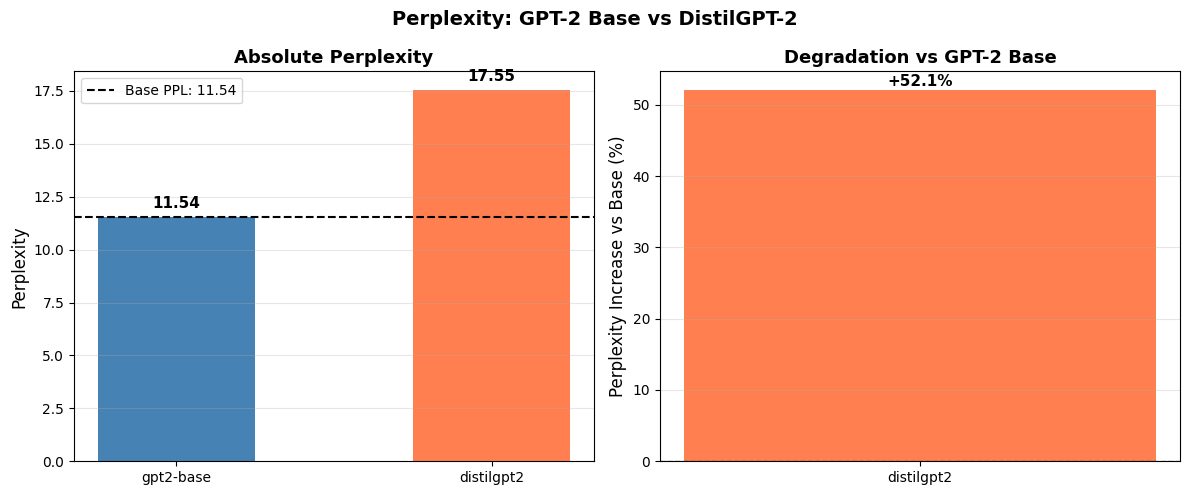

✓ Plot saved to /content/drive/MyDrive/IRP/GPT-2/perplexity_results_distil_tinystories/perplexity_distilgpt2.png

SUMMARY

Model                Layers      PPL     Δ PPL        Δ%
----------------------------------------------------------
gpt2-base                12    11.54         —         —
distilgpt2                6    17.55     +6.01    +52.1%

✅ Done! Results saved to /content/drive/MyDrive/IRP/GPT-2/perplexity_results_distil_tinystories


In [ ]:
import torch
import numpy as np
from pathlib import Path
from transformer_lens import HookedTransformer, HookedTransformerConfig
from transformer_lens.loading_from_pretrained import convert_gpt2_weights
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

# ============================================================================
# Configuration
# ============================================================================

class Config:
    output_folder = Path("/content/drive/MyDrive/IRP/GPT-2/perplexity_results_distil_tinystories")

    n_samples    = 1000
    max_length   = 256
    batch_size   = 8
    eval_dataset = "tinystories"  # Options: "wikitext", "tinystories", "c4"

    device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# Model Loading
# ============================================================================

def load_gpt2_base(device):
    """Load base GPT-2 via TransformerLens from_pretrained."""
    print("  Loading base GPT-2...")
    model = HookedTransformer.from_pretrained("gpt2").to(device).eval()
    return model


def load_distilgpt2(device):
    """
    Load DistilGPT-2 from HuggingFace and convert to a HookedTransformer.

    DistilGPT-2 has 6 layers (vs GPT-2's 12) but the same d_model/n_heads,
    so we build a matching HookedTransformerConfig and copy weights via
    convert_gpt2_weights.
    """
    print("  Loading DistilGPT-2...")

    hf_model = GPT2LMHeadModel.from_pretrained("distilgpt2").eval()

    cfg = HookedTransformerConfig(
        n_layers=6,           # DistilGPT-2 has 6 transformer blocks
        d_model=768,
        n_heads=12,
        d_head=64,
        d_mlp=3072,
        d_vocab=50257,
        n_ctx=1024,
        act_fn="gelu_new",
        normalization_type="LN",
        dtype=torch.float32,
        device="cpu",
    )

    tl_model = HookedTransformer(cfg)

    tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
    tokenizer.pad_token = tokenizer.eos_token
    tl_model.tokenizer = tokenizer

    sd = convert_gpt2_weights(hf_model, cfg)
    missing, _ = tl_model.load_state_dict(sd, strict=False)
    real_missing = [k for k in missing if 'mask' not in k and 'IGNORE' not in k]
    if real_missing:
        print(f"    ⚠ Missing TL keys: {real_missing[:5]}")

    del hf_model
    torch.cuda.empty_cache()

    tl_model = tl_model.to(device).eval()
    print("  ✓ DistilGPT-2 loaded.")
    return tl_model

# ============================================================================
# Dataset Loading
# ============================================================================

def load_eval_dataset(dataset_name, tokenizer, n_samples=1000,
                      min_tokens=64, max_tokens=256, seed=42):
    """Load evaluation dataset with controlled token-length sampling."""
    print(f"\nLoading {dataset_name} dataset...")
    random.seed(seed)
    samples = []

    if dataset_name == "wikitext":
        dataset  = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
        full_text = " ".join(
            item["text"] for item in dataset if item["text"].strip() != ""
        )
        tokens = tokenizer.encode(full_text, add_special_tokens=False)

        pbar = tqdm(total=n_samples, desc="Sampling wikitext")
        i = 0
        while len(samples) < n_samples and i < len(tokens) - min_tokens:
            length = random.randint(min_tokens, max_tokens)
            if i + length > len(tokens):
                break
            samples.append(tokens[i:i + length])
            pbar.update(1)
            i += length
        pbar.close()

    elif dataset_name in ["tinystories", "c4"]:
        if dataset_name == "tinystories":
            dataset = load_dataset("roneneldan/TinyStories", split="validation",
                                   streaming=True)
        else:
            dataset = load_dataset("c4", "en", split="validation", streaming=True)

        dataset   = dataset.shuffle(seed=seed)
        data_iter = iter(dataset)

        pbar = tqdm(total=n_samples, desc=f"Sampling {dataset_name}")
        while len(samples) < n_samples:
            try:
                text   = next(data_iter)["text"]
                tokens = tokenizer.encode(text, add_special_tokens=False)
                if min_tokens <= len(tokens) <= max_tokens:
                    samples.append(tokens)
                    pbar.update(1)
            except StopIteration:
                print(f"\n⚠️ Only {len(samples)} samples available in token range")
                break
        pbar.close()

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    print(f"✓ Prepared {len(samples)} sequences")
    return samples[:n_samples]

# ============================================================================
# Perplexity Computation
# ============================================================================

def compute_perplexity(model, tokenized_samples, batch_size=8):
    """Compute perplexity on tokenized samples."""
    model.eval()
    total_loss   = 0.0
    total_tokens = 0

    with torch.no_grad():
        for i in tqdm(range(0, len(tokenized_samples), batch_size),
                      desc="Computing perplexity"):
            batch   = tokenized_samples[i:i + batch_size]
            max_len = max(len(seq) for seq in batch)

            padded_batch = [
                seq + [model.tokenizer.pad_token_id] * (max_len - len(seq))
                for seq in batch
            ]
            input_ids = torch.tensor(padded_batch, device=model.cfg.device)
            logits    = model(input_ids)

            for j, seq in enumerate(batch):
                seq_len      = len(seq)
                shift_logits = logits[j, :-1, :]
                shift_labels = input_ids[j, 1:seq_len]
                loss = torch.nn.functional.cross_entropy(
                    shift_logits[:seq_len - 1],
                    shift_labels,
                    reduction='sum'
                )
                total_loss   += loss.item()
                total_tokens += (seq_len - 1)

    avg_loss   = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return perplexity, avg_loss

# ============================================================================
# Evaluation
# ============================================================================

def evaluate_models(tokenizer, eval_samples, device):
    """Evaluate base GPT-2 and DistilGPT-2 and return a results DataFrame."""
    results = []

    # ── Base GPT-2 ────────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("Evaluating: GPT-2 Base")
    print(f"{'='*60}")

    base_model = load_gpt2_base(device)
    base_model.tokenizer = tokenizer
    base_ppl, base_loss = compute_perplexity(base_model, eval_samples, Config.batch_size)

    print(f"  Perplexity : {base_ppl:.2f}")
    print(f"  Loss       : {base_loss:.4f}")

    results.append({
        'model'           : 'gpt2-base',
        'variant'         : 'base',
        'n_layers'        : 12,
        'perplexity'      : base_ppl,
        'loss'            : base_loss,
        'ppl_increase'    : 0.0,
        'ppl_increase_pct': 0.0,
    })

    del base_model
    torch.cuda.empty_cache()

    # ── DistilGPT-2 ───────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("Evaluating: DistilGPT-2")
    print(f"{'='*60}")

    distil_model = load_distilgpt2(device)
    distil_ppl, distil_loss = compute_perplexity(distil_model, eval_samples,
                                                  Config.batch_size)

    ppl_increase     = distil_ppl - base_ppl
    ppl_increase_pct = 100 * (distil_ppl - base_ppl) / base_ppl

    print(f"  Perplexity : {distil_ppl:.2f} ({ppl_increase:+.2f}, {ppl_increase_pct:+.1f}%)")
    print(f"  Loss       : {distil_loss:.4f}")

    results.append({
        'model'           : 'distilgpt2',
        'variant'         : 'distilled',
        'n_layers'        : 6,
        'perplexity'      : distil_ppl,
        'loss'            : distil_loss,
        'ppl_increase'    : ppl_increase,
        'ppl_increase_pct': ppl_increase_pct,
    })

    del distil_model
    torch.cuda.empty_cache()

    return pd.DataFrame(results), base_ppl

# ============================================================================
# Visualization
# ============================================================================

def create_visualizations(results_df, base_ppl, output_folder):
    """Bar chart comparing GPT-2 base vs DistilGPT-2."""
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    color_map = {'base': 'steelblue', 'distilled': 'coral'}
    colors    = [color_map.get(v, 'gray') for v in results_df['variant']]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Perplexity: GPT-2 Base vs DistilGPT-2',
                 fontsize=14, fontweight='bold')

    # Absolute perplexity
    ax   = axes[0]
    bars = ax.bar(results_df['model'], results_df['perplexity'], color=colors,
                  width=0.5)
    ax.axhline(y=base_ppl, color='black', linestyle='--', linewidth=1.5,
               label=f'Base PPL: {base_ppl:.2f}')
    ax.set_ylabel('Perplexity', fontsize=12)
    ax.set_title('Absolute Perplexity', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, results_df['perplexity']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.2f}', ha='center', va='bottom', fontsize=11,
                fontweight='bold')

    # Perplexity increase % (distil only)
    ax       = axes[1]
    distil   = results_df[results_df['variant'] == 'distilled']
    bars2    = ax.bar(distil['model'], distil['ppl_increase_pct'],
                      color='coral', width=0.4)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('Perplexity Increase vs Base (%)', fontsize=12)
    ax.set_title('Degradation vs GPT-2 Base', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars2, distil['ppl_increase_pct']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{val:+.1f}%', ha='center', va='bottom', fontsize=11,
                fontweight='bold')

    plt.tight_layout()
    out_path = output_folder / 'perplexity_distilgpt2.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"✓ Plot saved to {out_path}")

# ============================================================================
# Main
# ============================================================================

def main():
    Config.output_folder.mkdir(parents=True, exist_ok=True)

    print("=" * 60)
    print("Perplexity Evaluation — GPT-2 Base vs DistilGPT-2")
    print("=" * 60)

    # Use the shared GPT-2 tokenizer (both models share the same vocabulary)
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token

    eval_samples = load_eval_dataset(
        dataset_name=Config.eval_dataset,
        tokenizer=tokenizer,
        n_samples=Config.n_samples,
        min_tokens=64,
        max_tokens=Config.max_length,
    )

    results_df, base_ppl = evaluate_models(tokenizer, eval_samples, Config.device)

    # Save CSV
    csv_path = Config.output_folder / 'perplexity_results_distilgpt2.csv'
    results_df.to_csv(csv_path, index=False)
    print(f"\n✓ Results saved to {csv_path}")

    create_visualizations(results_df, base_ppl, Config.output_folder)

    # Summary table
    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    print(f"\n{'Model':<20} {'Layers':>6} {'PPL':>8}  {'Δ PPL':>8}  {'Δ%':>8}")
    print("-" * 58)
    for _, row in results_df.iterrows():
        delta_ppl = f"{row['ppl_increase']:+.2f}" if row['variant'] != 'base' else "—"
        delta_pct = f"{row['ppl_increase_pct']:+.1f}%" if row['variant'] != 'base' else "—"
        print(f"{row['model']:<20} {int(row['n_layers']):>6} {row['perplexity']:>8.2f}  "
              f"{delta_ppl:>8}  {delta_pct:>8}")

    print(f"\n✅ Done! Results saved to {Config.output_folder}")

if __name__ == "__main__":
    main()

Perplexity Evaluation — GPT-2 Base vs DistilGPT-2

Loading wikitext dataset...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    ⚠ Missing TL keys: ['unembed.b_U']
Moving model to device:  cuda
  ✓ DistilGPT-2 loaded.


Computing perplexity: 100%|██████████| 68/68 [00:19<00:00,  3.57it/s]


  Perplexity : 49.33 (+16.31, +49.4%)
  Loss       : 3.8986

✓ Results saved to /content/drive/MyDrive/IRP/GPT-2/perplexity_results_distil_wikitext/perplexity_results_distilgpt2.csv


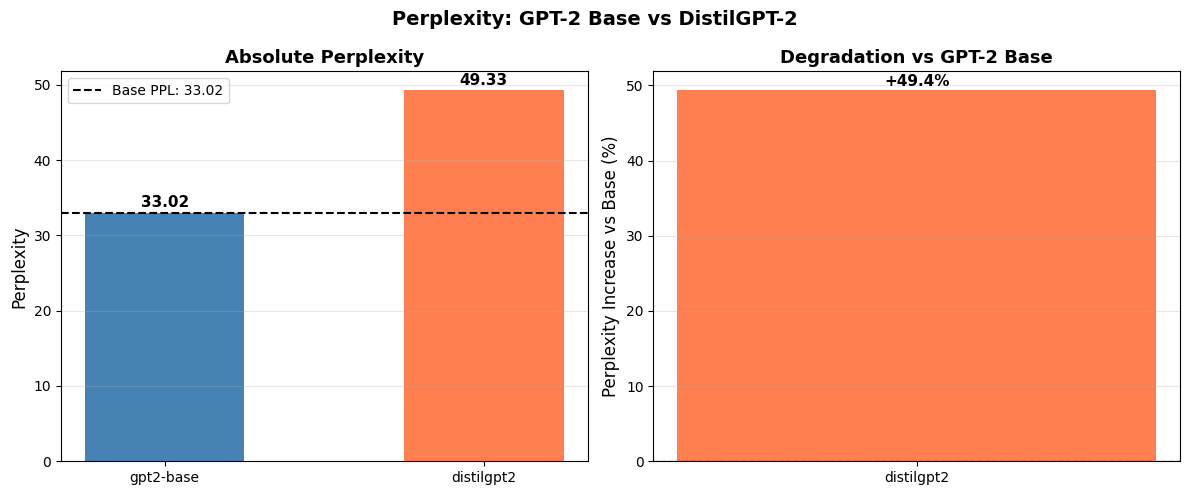

✓ Plot saved to /content/drive/MyDrive/IRP/GPT-2/perplexity_results_distil_wikitext/perplexity_distilgpt2.png

SUMMARY

Model                Layers      PPL     Δ PPL        Δ%
----------------------------------------------------------
gpt2-base                12    33.02         —         —
distilgpt2                6    49.33    +16.31    +49.4%

✅ Done! Results saved to /content/drive/MyDrive/IRP/GPT-2/perplexity_results_distil_wikitext


In [ ]:
import torch
import numpy as np
from pathlib import Path
from transformer_lens import HookedTransformer, HookedTransformerConfig
from transformer_lens.loading_from_pretrained import convert_gpt2_weights
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

# ============================================================================
# Configuration
# ============================================================================

class Config:
    output_folder = Path("/content/drive/MyDrive/IRP/GPT-2/perplexity_results_distil_wikitext")

    n_samples    = 1000
    max_length   = 1024
    batch_size   = 8
    eval_dataset = "wikitext"  # Options: "wikitext", "tinystories", "c4"

    device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# Model Loading
# ============================================================================

def load_gpt2_base(device):
    """Load base GPT-2 via TransformerLens from_pretrained."""
    print("  Loading base GPT-2...")
    model = HookedTransformer.from_pretrained("gpt2").to(device).eval()
    return model


def load_distilgpt2(device):
    """
    Load DistilGPT-2 from HuggingFace and convert to a HookedTransformer.

    DistilGPT-2 has 6 layers (vs GPT-2's 12) but the same d_model/n_heads,
    so we build a matching HookedTransformerConfig and copy weights via
    convert_gpt2_weights.
    """
    print("  Loading DistilGPT-2...")

    hf_model = GPT2LMHeadModel.from_pretrained("distilgpt2").eval()

    cfg = HookedTransformerConfig(
        n_layers=6,           # DistilGPT-2 has 6 transformer blocks
        d_model=768,
        n_heads=12,
        d_head=64,
        d_mlp=3072,
        d_vocab=50257,
        n_ctx=1024,
        act_fn="gelu_new",
        normalization_type="LN",
        dtype=torch.float32,
        device="cpu",
    )

    tl_model = HookedTransformer(cfg)

    tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
    tokenizer.pad_token = tokenizer.eos_token
    tl_model.tokenizer = tokenizer

    sd = convert_gpt2_weights(hf_model, cfg)
    missing, _ = tl_model.load_state_dict(sd, strict=False)
    real_missing = [k for k in missing if 'mask' not in k and 'IGNORE' not in k]
    if real_missing:
        print(f"    ⚠ Missing TL keys: {real_missing[:5]}")

    del hf_model
    torch.cuda.empty_cache()

    tl_model = tl_model.to(device).eval()
    print("  ✓ DistilGPT-2 loaded.")
    return tl_model

# ============================================================================
# Dataset Loading
# ============================================================================

def load_eval_dataset(dataset_name, tokenizer, n_samples=1000,
                      min_tokens=64, max_tokens=256, seed=42):
    """Load evaluation dataset with controlled token-length sampling."""
    print(f"\nLoading {dataset_name} dataset...")
    random.seed(seed)
    samples = []

    if dataset_name == "wikitext":
        dataset  = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
        full_text = " ".join(
            item["text"] for item in dataset if item["text"].strip() != ""
        )
        tokens = tokenizer.encode(full_text, add_special_tokens=False)

        pbar = tqdm(total=n_samples, desc="Sampling wikitext")
        i = 0
        while len(samples) < n_samples and i < len(tokens) - min_tokens:
            length = random.randint(min_tokens, max_tokens)
            if i + length > len(tokens):
                break
            samples.append(tokens[i:i + length])
            pbar.update(1)
            i += length
        pbar.close()

    elif dataset_name in ["tinystories", "c4"]:
        if dataset_name == "tinystories":
            dataset = load_dataset("roneneldan/TinyStories", split="validation",
                                   streaming=True)
        else:
            dataset = load_dataset("c4", "en", split="validation", streaming=True)

        dataset   = dataset.shuffle(seed=seed)
        data_iter = iter(dataset)

        pbar = tqdm(total=n_samples, desc=f"Sampling {dataset_name}")
        while len(samples) < n_samples:
            try:
                text   = next(data_iter)["text"]
                tokens = tokenizer.encode(text, add_special_tokens=False)
                if min_tokens <= len(tokens) <= max_tokens:
                    samples.append(tokens)
                    pbar.update(1)
            except StopIteration:
                print(f"\n⚠️ Only {len(samples)} samples available in token range")
                break
        pbar.close()

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    print(f"✓ Prepared {len(samples)} sequences")
    return samples[:n_samples]

# ============================================================================
# Perplexity Computation
# ============================================================================

def compute_perplexity(model, tokenized_samples, batch_size=8):
    """Compute perplexity on tokenized samples."""
    model.eval()
    total_loss   = 0.0
    total_tokens = 0

    with torch.no_grad():
        for i in tqdm(range(0, len(tokenized_samples), batch_size),
                      desc="Computing perplexity"):
            batch   = tokenized_samples[i:i + batch_size]
            max_len = max(len(seq) for seq in batch)

            padded_batch = [
                seq + [model.tokenizer.pad_token_id] * (max_len - len(seq))
                for seq in batch
            ]
            input_ids = torch.tensor(padded_batch, device=model.cfg.device)
            logits    = model(input_ids)

            for j, seq in enumerate(batch):
                seq_len      = len(seq)
                shift_logits = logits[j, :-1, :]
                shift_labels = input_ids[j, 1:seq_len]
                loss = torch.nn.functional.cross_entropy(
                    shift_logits[:seq_len - 1],
                    shift_labels,
                    reduction='sum'
                )
                total_loss   += loss.item()
                total_tokens += (seq_len - 1)

    avg_loss   = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return perplexity, avg_loss

# ============================================================================
# Evaluation
# ============================================================================

def evaluate_models(tokenizer, eval_samples, device):
    """Evaluate base GPT-2 and DistilGPT-2 and return a results DataFrame."""
    results = []

    # ── Base GPT-2 ────────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("Evaluating: GPT-2 Base")
    print(f"{'='*60}")

    base_model = load_gpt2_base(device)
    base_model.tokenizer = tokenizer
    base_ppl, base_loss = compute_perplexity(base_model, eval_samples, Config.batch_size)

    print(f"  Perplexity : {base_ppl:.2f}")
    print(f"  Loss       : {base_loss:.4f}")

    results.append({
        'model'           : 'gpt2-base',
        'variant'         : 'base',
        'n_layers'        : 12,
        'perplexity'      : base_ppl,
        'loss'            : base_loss,
        'ppl_increase'    : 0.0,
        'ppl_increase_pct': 0.0,
    })

    del base_model
    torch.cuda.empty_cache()

    # ── DistilGPT-2 ───────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("Evaluating: DistilGPT-2")
    print(f"{'='*60}")

    distil_model = load_distilgpt2(device)
    distil_ppl, distil_loss = compute_perplexity(distil_model, eval_samples,
                                                  Config.batch_size)

    ppl_increase     = distil_ppl - base_ppl
    ppl_increase_pct = 100 * (distil_ppl - base_ppl) / base_ppl

    print(f"  Perplexity : {distil_ppl:.2f} ({ppl_increase:+.2f}, {ppl_increase_pct:+.1f}%)")
    print(f"  Loss       : {distil_loss:.4f}")

    results.append({
        'model'           : 'distilgpt2',
        'variant'         : 'distilled',
        'n_layers'        : 6,
        'perplexity'      : distil_ppl,
        'loss'            : distil_loss,
        'ppl_increase'    : ppl_increase,
        'ppl_increase_pct': ppl_increase_pct,
    })

    del distil_model
    torch.cuda.empty_cache()

    return pd.DataFrame(results), base_ppl

# ============================================================================
# Visualization
# ============================================================================

def create_visualizations(results_df, base_ppl, output_folder):
    """Bar chart comparing GPT-2 base vs DistilGPT-2."""
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    color_map = {'base': 'steelblue', 'distilled': 'coral'}
    colors    = [color_map.get(v, 'gray') for v in results_df['variant']]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Perplexity: GPT-2 Base vs DistilGPT-2',
                 fontsize=14, fontweight='bold')

    # Absolute perplexity
    ax   = axes[0]
    bars = ax.bar(results_df['model'], results_df['perplexity'], color=colors,
                  width=0.5)
    ax.axhline(y=base_ppl, color='black', linestyle='--', linewidth=1.5,
               label=f'Base PPL: {base_ppl:.2f}')
    ax.set_ylabel('Perplexity', fontsize=12)
    ax.set_title('Absolute Perplexity', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, results_df['perplexity']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.2f}', ha='center', va='bottom', fontsize=11,
                fontweight='bold')

    # Perplexity increase % (distil only)
    ax       = axes[1]
    distil   = results_df[results_df['variant'] == 'distilled']
    bars2    = ax.bar(distil['model'], distil['ppl_increase_pct'],
                      color='coral', width=0.4)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('Perplexity Increase vs Base (%)', fontsize=12)
    ax.set_title('Degradation vs GPT-2 Base', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars2, distil['ppl_increase_pct']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{val:+.1f}%', ha='center', va='bottom', fontsize=11,
                fontweight='bold')

    plt.tight_layout()
    out_path = output_folder / 'perplexity_distilgpt2.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"✓ Plot saved to {out_path}")

# ============================================================================
# Main
# ============================================================================

def main():
    Config.output_folder.mkdir(parents=True, exist_ok=True)

    print("=" * 60)
    print("Perplexity Evaluation — GPT-2 Base vs DistilGPT-2")
    print("=" * 60)

    # Use the shared GPT-2 tokenizer (both models share the same vocabulary)
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token

    eval_samples = load_eval_dataset(
        dataset_name=Config.eval_dataset,
        tokenizer=tokenizer,
        n_samples=Config.n_samples,
        min_tokens=64,
        max_tokens=Config.max_length,
    )

    results_df, base_ppl = evaluate_models(tokenizer, eval_samples, Config.device)

    # Save CSV
    csv_path = Config.output_folder / 'perplexity_results_distilgpt2.csv'
    results_df.to_csv(csv_path, index=False)
    print(f"\n✓ Results saved to {csv_path}")

    create_visualizations(results_df, base_ppl, Config.output_folder)

    # Summary table
    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    print(f"\n{'Model':<20} {'Layers':>6} {'PPL':>8}  {'Δ PPL':>8}  {'Δ%':>8}")
    print("-" * 58)
    for _, row in results_df.iterrows():
        delta_ppl = f"{row['ppl_increase']:+.2f}" if row['variant'] != 'base' else "—"
        delta_pct = f"{row['ppl_increase_pct']:+.1f}%" if row['variant'] != 'base' else "—"
        print(f"{row['model']:<20} {int(row['n_layers']):>6} {row['perplexity']:>8.2f}  "
              f"{delta_ppl:>8}  {delta_pct:>8}")

    print(f"\n✅ Done! Results saved to {Config.output_folder}")

if __name__ == "__main__":
    main()

#IOI Circuit Analysis

In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
from transformer_lens import HookedTransformer
from transformer_lens.utils import get_act_name

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================================================
# Configuration
# ============================================================================

@dataclass
class Config:
    """Configuration for IOI experiments."""
    num_samples: int = 1000
    batch_size: int = 50
    num_bootstrap_samples: int = 100
    output_dir: Path = Path("/content/drive/MyDrive/IRP/GPT-2/ioi_analysis_results_distilgpt2")
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# IOI Circuit Definition (from Wang et al. 2022)
# NOTE: These heads are defined for GPT-2 (12 layers, 12 heads).
# DistilGPT-2 only has 6 layers, so circuit heads in layers 6-11
# do not exist in DistilGPT-2. The analysis handles this gracefully.
# ============================================================================

IOI_CIRCUIT_HEADS = {
    "previous_token": [(0, 1), (2, 2), (4, 11)],
    "duplicate_token": [(0, 10), (3, 0)],
    "induction":       [(5, 1), (5, 5), (6, 9), (7, 2), (7, 10)],
    "s_inhibition":    [(7, 3), (7, 9), (8, 6), (8, 10)],
    "name_mover":      [(9, 6), (9, 9), (10, 0), (10, 6), (11, 2)],
    "negative_name_mover": [(10, 7), (11, 10)],
    "backup_name_mover":   [(9, 0), (9, 1), (10, 2), (10, 10), (11, 9)]
}

# Heads that exist in DistilGPT-2 (layers 0-5 only)
DISTILGPT2_VALID_LAYERS = set(range(6))

def filter_heads_for_model(heads_dict, n_layers):
    """Return only heads that exist in a model with n_layers."""
    filtered = {}
    for class_name, heads in heads_dict.items():
        valid = [(l, h) for l, h in heads if l < n_layers]
        if valid:
            filtered[class_name] = valid
    return filtered

CRITICAL_PATHS = [
    ((0, 10), (7, 3),  "DT→S-INH"),
    ((3, 0),  (7, 9),  "DT→S-INH"),
    ((5, 1),  (9, 9),  "IND→NM"),
    ((6, 9),  (9, 6),  "IND→NM"),
    ((7, 3),  (9, 9),  "S-INH→NM"),
    ((8, 6),  (10, 0), "S-INH→NM"),
    ((0, 1),  (5, 1),  "PT→IND"),
    ((2, 2),  (6, 9),  "PT→IND"),
    ((5, 1),  (9, 1),  "IND→BNM"),
    ((6, 9),  (10, 2), "IND→BNM"),
    ((7, 3),  (10, 7), "S-INH→NNM"),
    ((8, 6),  (11, 10),"S-INH→NNM"),
]

def filter_paths_for_model(paths, n_layers):
    """Return only paths where both source and target layers exist."""
    return [p for p in paths if p[0][0] < n_layers and p[1][0] < n_layers]

# ============================================================================
# Dataset Creation (unchanged)
# ============================================================================

def create_ioi_datasets(model, num_samples, seed=42):
    import random
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    def get_single_token_names(model, names):
        valid = []
        for n in names:
            toks = model.to_tokens(" " + n, prepend_bos=False)
            if toks.shape[1] == 1:
                valid.append(n)
        return valid

    RAW_NAMES = [
        "Alice", "Bob", "Charlie", "David", "Emma", "Frank", "Grace", "Henry",
        "Iris", "Jack", "Kate", "Leo", "Mary", "Noah", "Olivia", "Peter",
        "Quinn", "Ruby", "Sam", "Tom", "Uma", "Victor", "Wendy", "Xander",
        "Michael", "Jessica", "Christopher", "Ashley", "Matthew", "Brittany",
        "Josh", "Amanda", "Daniel", "Sarah", "David", "Kimberly",
        "James", "Jennifer", "Robert", "Emily", "John", "Dan", "Sid", "Mark",
        "Kate", "Jason"
    ]
    OBJECTS = ["book", "ball", "pen", "cup", "toy", "gift", "phone", "key",
               "coin", "ring", "watch", "bag", "hat", "shoe"]
    PLACES  = ["store", "park", "school", "office", "library", "cafe",
               "museum", "garden", "station", "beach"]
    TEMPLATES = [
        "Then, {IO} and {S1} went to the {PLACE}. {S2} gave a {OBJ} to",
        "When {IO} and {S1} walked into the {PLACE}, {S2} handed a {OBJ} to",
        "After {IO} and {S1} arrived at the {PLACE}, {S2} passed a {OBJ} to",
        "While {IO} and {S1} were at the {PLACE}, {S2} threw a {OBJ} to",
        "Before {IO} and {S1} left the {PLACE}, {S2} showed a {OBJ} to",
        "Then, {S1} and {IO} went to the {PLACE}. {S2} gave a {OBJ} to",
        "When {S1} and {IO} walked into the {PLACE}, {S2} handed a {OBJ} to",
        "After {S1} and {IO} arrived at the {PLACE}, {S2} passed a {OBJ} to",
        "While {S1} and {IO} were at the {PLACE}, {S2} threw a {OBJ} to",
        "Before {S1} and {IO} left the {PLACE}, {S2} showed a {OBJ} to",
        "Since {IO} and {S1} were at the {PLACE}, {S2} offered a {OBJ} to",
        "Though {IO} and {S1} liked the {PLACE}, {S2} sent a {OBJ} to",
        "Once {IO} and {S1} reached the {PLACE}, {S2} brought a {OBJ} to",
        "As {IO} and {S1} entered the {PLACE}, {S2} delivered a {OBJ} to",
        "Because {S1} and {IO} went to the {PLACE}, {S2} took a {OBJ} to",
    ]

    NAMES = get_single_token_names(model, RAW_NAMES)
    print(f"Valid single-token names: {len(NAMES)}")
    assert len(NAMES) >= 10

    clean_prompts, corrupt_prompts = [], []
    io_last_token_ids, s_last_token_ids = [], []

    for _ in range(num_samples):
        template = random.choice(TEMPLATES)
        place = random.choice(PLACES)
        obj   = random.choice(OBJECTS)
        io_name, s_name, random_name = random.sample(NAMES, 3)

        io_token = model.to_tokens(" " + io_name, prepend_bos=False)[0, -1].item()
        s_token  = model.to_tokens(" " + s_name,  prepend_bos=False)[0, -1].item()
        io_last_token_ids.append(io_token)
        s_last_token_ids.append(s_token)

        clean_prompts.append(
            template.format(IO=io_name, S1=s_name, S2=s_name, PLACE=place, OBJ=obj)
            + " " + io_name
        )
        corrupt_prompts.append(
            template.format(IO=io_name, S1=s_name, S2=random_name, PLACE=place, OBJ=obj)
            + " " + io_name
        )

    clean_toks     = model.to_tokens(clean_prompts,   prepend_bos=True)
    corrupted_toks = model.to_tokens(corrupt_prompts, prepend_bos=True)

    end_positions = []
    for i in range(len(clean_prompts)):
        tokens   = clean_toks[i]
        io_token = io_last_token_ids[i]
        io_mask  = (tokens == io_token)
        io_positions = io_mask.nonzero(as_tuple=True)[0]
        if len(io_positions) == 0:
            end_positions.append(len(tokens) - 2)
        else:
            end_positions.append(io_positions[-1].item() - 1)

    end_pos = torch.tensor(end_positions, dtype=torch.long, device=model.cfg.device)

    class DatasetWrapper:
        def __init__(self, toks, io_ids, s_ids, end_pos, texts):
            self.toks         = toks
            self.io_tokenIDs  = torch.tensor(io_ids, device=model.cfg.device)
            self.s_tokenIDs   = torch.tensor(s_ids,  device=model.cfg.device)
            self.word_idx     = {"end": end_pos}
            self.sentences    = texts

    ioi_dataset = DatasetWrapper(clean_toks,     io_last_token_ids, s_last_token_ids, end_pos, clean_prompts)
    abc_dataset = DatasetWrapper(corrupted_toks, io_last_token_ids, s_last_token_ids, end_pos, corrupt_prompts)

    print(f"✓ Created {num_samples} IOI examples ({len(set(clean_prompts))} unique)")
    return ioi_dataset, abc_dataset

# ============================================================================
# Metrics (unchanged)
# ============================================================================

def compute_logit_diff(logits, io_tokens, s_tokens, end_positions):
    batch_size = logits.shape[0]
    io_logits = logits[torch.arange(batch_size, device=logits.device), end_positions, io_tokens]
    s_logits  = logits[torch.arange(batch_size, device=logits.device), end_positions, s_tokens]
    return io_logits - s_logits

def evaluate_ioi_performance(model, dataset, batch_size=50):
    model.eval()
    device = model.cfg.device
    all_logit_diffs = []
    num_batches = (len(dataset.toks) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in range(num_batches):
            s, e = i * batch_size, min((i+1) * batch_size, len(dataset.toks))
            logits = model(dataset.toks[s:e].to(device))
            ld = compute_logit_diff(
                logits,
                dataset.io_tokenIDs[s:e].to(device),
                dataset.s_tokenIDs[s:e].to(device),
                dataset.word_idx["end"][s:e].to(device)
            )
            all_logit_diffs.append(ld.cpu())

    all_logit_diffs = torch.cat(all_logit_diffs)
    return {
        "mean_logit_diff":   float(all_logit_diffs.mean()),
        "std_logit_diff":    float(all_logit_diffs.std()),
        "median_logit_diff": float(all_logit_diffs.median()),
        "accuracy":          float((all_logit_diffs > 0).float().mean()),
    }

# ============================================================================
# Activation Patching (unchanged)
# ============================================================================

def activation_patch_head(model, clean_dataset, corrupt_dataset, layer, head,
                           batch_size=50, return_samples=True):
    model.eval()
    device    = model.cfg.device
    hook_name = get_act_name("result", layer)
    all_logit_diffs = []
    num_batches = (len(clean_dataset.toks) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in range(num_batches):
            s, e = i * batch_size, min((i+1) * batch_size, len(clean_dataset.toks))
            clean_tokens   = clean_dataset.toks[s:e].to(device)
            corrupt_tokens = corrupt_dataset.toks[s:e].to(device)
            batch_io   = clean_dataset.io_tokenIDs[s:e].to(device)
            batch_s    = clean_dataset.s_tokenIDs[s:e].to(device)
            batch_ends = clean_dataset.word_idx["end"][s:e].to(device)

            _, clean_cache = model.run_with_cache(clean_tokens)
            clean_head_act = clean_cache[hook_name][:, :, head, :].clone()

            def patch_hook(activation, hook):
                activation = activation.clone()
                activation[:, :, head, :] = clean_head_act
                return activation

            patched_logits = model.run_with_hooks(corrupt_tokens, fwd_hooks=[(hook_name, patch_hook)])
            ld = compute_logit_diff(patched_logits, batch_io, batch_s, batch_ends)
            all_logit_diffs.append(ld.cpu())

    all_logit_diffs = torch.cat(all_logit_diffs)
    return all_logit_diffs.numpy() if return_samples else float(all_logit_diffs.mean())

def path_patch_head_to_head(model, clean_dataset, corrupt_dataset,
                             source_layer, source_head, receiver_layer,
                             receiver_head=None, receiver_hook_name=None,
                             batch_size=50, return_samples=True):
    model.eval()
    device      = model.cfg.device
    source_hook = get_act_name("result", source_layer)
    resid_hook  = f"blocks.{receiver_layer}.hook_resid_pre"
    all_logit_diffs = []
    num_batches = (len(clean_dataset.toks) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in tqdm(range(num_batches),
                      desc=f"L{source_layer}H{source_head}→L{receiver_layer}",
                      leave=False):
            s, e = i * batch_size, min((i+1) * batch_size, len(clean_dataset.toks))
            clean_tokens   = clean_dataset.toks[s:e].to(device)
            corrupt_tokens = corrupt_dataset.toks[s:e].to(device)
            batch_io   = clean_dataset.io_tokenIDs[s:e].to(device)
            batch_s    = clean_dataset.s_tokenIDs[s:e].to(device)
            batch_ends = clean_dataset.word_idx["end"][s:e].to(device)

            _, clean_cache   = model.run_with_cache(clean_tokens)
            _, corrupt_cache = model.run_with_cache(corrupt_tokens)

            src_diff = (clean_cache[source_hook][:, :, source_head, :]
                        - corrupt_cache[source_hook][:, :, source_head, :])

            def resid_patch_hook(resid, hook):
                return resid.clone() + src_diff

            patched_logits = model.run_with_hooks(corrupt_tokens,
                                                  fwd_hooks=[(resid_hook, resid_patch_hook)])
            ld = compute_logit_diff(patched_logits, batch_io, batch_s, batch_ends)
            all_logit_diffs.append(ld.cpu())

    all_logit_diffs = torch.cat(all_logit_diffs)
    return all_logit_diffs.numpy() if return_samples else float(all_logit_diffs.mean())

# ============================================================================
# Statistical Analysis (unchanged)
# ============================================================================

from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

def bootstrap_confidence_interval(data, num_bootstrap=1000, confidence=0.95):
    bootstrap_means = [np.random.choice(data, size=len(data), replace=True).mean()
                       for _ in range(num_bootstrap)]
    alpha = 1 - confidence
    return np.percentile(bootstrap_means, 100*alpha/2), np.percentile(bootstrap_means, 100*(1-alpha/2))

def test_significance(base_scores, comp_scores, method='ttest'):
    if method == 'ttest':
        _, p = ttest_rel(base_scores, comp_scores)
    else:
        _, p = wilcoxon(base_scores, comp_scores)
    return float(p), p < 0.05

def cohens_d(base, comp, paired=True):
    if paired:
        diff = base - comp
        return 0.0 if diff.std() == 0 else diff.mean() / diff.std()
    pooled = np.sqrt((base.std()**2 + comp.std()**2) / 2)
    return 0.0 if pooled == 0 else (base.mean() - comp.mean()) / pooled

def correct_multiple_comparisons(p_values, method='bonferroni', alpha=0.05):
    reject, corrected_p, _, _ = multipletests(p_values, method=method, alpha=alpha)
    return reject, corrected_p

def compute_statistical_summary(base_scores, comp_scores, name="comparison", paired=True):
    base_scores = np.asarray(base_scores).flatten()
    comp_scores = np.asarray(comp_scores).flatten()
    base_ci = bootstrap_confidence_interval(base_scores)
    comp_ci = bootstrap_confidence_interval(comp_scores)
    p_t, sig_t = test_significance(base_scores, comp_scores, 'ttest')
    p_w, sig_w = test_significance(base_scores, comp_scores, 'wilcoxon')
    degradation = (base_scores.mean() - comp_scores.mean()) / base_scores.mean() \
                  if base_scores.mean() != 0 else 0
    return {
        'name': name, 'n': len(base_scores),
        'base_mean': float(base_scores.mean()), 'base_std': float(base_scores.std()),
        'base_ci_lower': float(base_ci[0]), 'base_ci_upper': float(base_ci[1]),
        'quantized_mean': float(comp_scores.mean()), 'quantized_std': float(comp_scores.std()),
        'quantized_ci_lower': float(comp_ci[0]), 'quantized_ci_upper': float(comp_ci[1]),
        'degradation': float(degradation),
        'effect_size_cohens_d': float(cohens_d(base_scores, comp_scores, paired)),
        'p_value_ttest': float(p_t), 'significant_ttest': bool(sig_t),
        'p_value_wilcoxon': float(p_w), 'significant_wilcoxon': bool(sig_w),
    }

def compute_noise_ceiling(model, ioi_dataset, abc_dataset, batch_size=50):
    clean  = evaluate_ioi_performance(model, ioi_dataset, batch_size)
    corrupt = evaluate_ioi_performance(model, abc_dataset, batch_size)
    return float(clean['mean_logit_diff'] - corrupt['mean_logit_diff'])

# ============================================================================
# Single Model Analysis  (renamed: "quantized" → "distil" in labels/keys)
# ============================================================================

def run_ioi_analysis_single_model(
    base_model, distil_model, model_name,
    ioi_dataset, abc_dataset, config,
    base_results=None
):
    """Run IOI analysis comparing base_model vs distil_model."""

    print(f"\n{'='*60}")
    print(f"Analyzing: {model_name}")
    print(f"{'='*60}")

    n_layers_distil = distil_model.cfg.n_layers  # 6 for DistilGPT-2
    valid_heads  = filter_heads_for_model(IOI_CIRCUIT_HEADS, n_layers_distil)
    valid_paths  = filter_paths_for_model(CRITICAL_PATHS,   n_layers_distil)

    skipped_heads = sum(len(v) for v in IOI_CIRCUIT_HEADS.values()) - \
                    sum(len(v) for v in valid_heads.values())
    skipped_paths = len(CRITICAL_PATHS) - len(valid_paths)

    print(f"\n  DistilGPT-2 has {n_layers_distil} layers.")
    print(f"  IOI heads available: {sum(len(v) for v in valid_heads.values())} "
          f"(skipping {skipped_heads} in layers ≥{n_layers_distil})")
    print(f"  Critical paths available: {len(valid_paths)} "
          f"(skipping {skipped_paths} in layers ≥{n_layers_distil})")

    results = {
        'model_name':  model_name,
        'baseline':    {},
        'heads':       [],
        'paths':       [],
        'statistics':  {},
        'skipped_heads': skipped_heads,
        'skipped_paths': skipped_paths,
    }

    # --- Baseline ---
    print(f"\n[1/3] Evaluating baseline performance...")
    distil_perf = evaluate_ioi_performance(distil_model, ioi_dataset, config.batch_size)
    base_perf   = base_results or evaluate_ioi_performance(base_model, ioi_dataset, config.batch_size)

    degradation  = (base_perf['mean_logit_diff'] - distil_perf['mean_logit_diff']) / \
                   base_perf['mean_logit_diff']
    recovery_pct = (distil_perf['mean_logit_diff'] / base_perf['mean_logit_diff'] * 100) \
                   if base_perf['mean_logit_diff'] != 0 else 0

    print(f"  GPT-2:      {base_perf['mean_logit_diff']:.3f} ± {base_perf['std_logit_diff']:.3f}  "
          f"acc={base_perf['accuracy']*100:.1f}%")
    print(f"  DistilGPT-2:{distil_perf['mean_logit_diff']:.3f} ± {distil_perf['std_logit_diff']:.3f}  "
          f"acc={distil_perf['accuracy']*100:.1f}%")
    print(f"  Degradation: {degradation*100:.1f}%  |  Recovery: {recovery_pct:.1f}%")

    noise_ceiling = compute_noise_ceiling(base_model, ioi_dataset, abc_dataset, config.batch_size)

    results['baseline'] = {
        'base':              base_perf,
        'distil':            distil_perf,
        'degradation':       degradation,
        'recovery_pct':      recovery_pct,
        'noise_ceiling':     noise_ceiling,
    }

    # --- Head patching ---
    print(f"\n[2/3] Head-level activation patching ({sum(len(v) for v in valid_heads.values())} heads)...")

    all_base_head_samples   = []
    all_distil_head_samples = []

    for class_name, heads in valid_heads.items():
        print(f"\n  {class_name} ({len(heads)} heads)...")
        class_base, class_distil = [], []

        for layer, head in tqdm(heads, desc=f"  {class_name}"):
            base_samples  = activation_patch_head(base_model,  ioi_dataset, abc_dataset,
                                                  layer, head, config.batch_size, return_samples=True)
            distil_samples = activation_patch_head(distil_model, ioi_dataset, abc_dataset,
                                                   layer, head, config.batch_size, return_samples=True)

            base_score    = float(base_samples.mean())
            distil_score  = float(distil_samples.mean())
            head_degrad   = (base_score - distil_score) / base_score if base_score != 0 else 0

            results['heads'].append({
                'layer': layer, 'head': head, 'class': class_name,
                'base_score':   base_score,
                'distil_score': distil_score,
                'degradation':  head_degrad,
            })
            all_base_head_samples.append(base_samples)
            all_distil_head_samples.append(distil_samples)
            class_base.append(base_samples)
            class_distil.append(distil_samples)

        class_stats = compute_statistical_summary(
            np.concatenate(class_base), np.concatenate(class_distil),
            name=f"{class_name}_heads"
        )
        results['statistics'][f'class_{class_name}'] = class_stats
        print(f"    d={class_stats['effect_size_cohens_d']:.3f}  "
              f"p={class_stats['p_value_ttest']:.4f}  "
              f"sig={class_stats['significant_ttest']}")

    overall_head_stats = compute_statistical_summary(
        np.concatenate(all_base_head_samples),
        np.concatenate(all_distil_head_samples),
        name="all_heads"
    )
    results['statistics']['all_heads'] = overall_head_stats
    print(f"\n  Overall heads — d={overall_head_stats['effect_size_cohens_d']:.3f}  "
          f"p={overall_head_stats['p_value_ttest']:.4f}")

    # --- Path patching ---
    print(f"\n[3/3] Path patching ({len(valid_paths)} paths)...")

    all_base_path_samples   = []
    all_distil_path_samples = []
    path_type_base   = {}
    path_type_distil = {}

    for (sl, sh), (tl, th), path_type in tqdm(valid_paths, desc="  Paths"):
        if path_type not in path_type_base:
            path_type_base[path_type]   = []
            path_type_distil[path_type] = []

        base_samples  = path_patch_head_to_head(base_model,  ioi_dataset, abc_dataset,
                                                sl, sh, tl, batch_size=config.batch_size,
                                                return_samples=True)
        distil_samples = path_patch_head_to_head(distil_model, ioi_dataset, abc_dataset,
                                                 sl, sh, tl, batch_size=config.batch_size,
                                                 return_samples=True)

        bm, dm = float(base_samples.mean()), float(distil_samples.mean())
        path_degrad = (bm - dm) / bm if bm != 0 else 0

        results['paths'].append({
            'source_layer': sl, 'source_head': sh,
            'target_layer': tl, 'target_head': th,
            'path_type': path_type,
            'path_name': f"L{sl}H{sh}→L{tl}H{th}",
            'base_score':    bm,    'base_std':    float(base_samples.std()),
            'distil_score':  dm,    'distil_std':  float(distil_samples.std()),
            'degradation':   path_degrad,
            'n_samples':     len(base_samples),
        })
        all_base_path_samples.append(base_samples)
        all_distil_path_samples.append(distil_samples)
        path_type_base[path_type].append(base_samples)
        path_type_distil[path_type].append(distil_samples)

    overall_path_stats = compute_statistical_summary(
        np.concatenate(all_base_path_samples),
        np.concatenate(all_distil_path_samples),
        name="all_paths", paired=True
    )
    results['statistics']['all_paths'] = overall_path_stats

    print(f"\n  Overall paths — d={overall_path_stats['effect_size_cohens_d']:.3f}  "
          f"p={overall_path_stats['p_value_ttest']:.4f}  "
          f"degradation={overall_path_stats['degradation']*100:.1f}%")

    for path_type in sorted(path_type_base.keys()):
        type_stats = compute_statistical_summary(
            np.concatenate(path_type_base[path_type]),
            np.concatenate(path_type_distil[path_type]),
            name=f"{path_type}_paths", paired=True
        )
        results['statistics'][f'pathtype_{path_type}'] = type_stats
        print(f"    {path_type}: d={type_stats['effect_size_cohens_d']:.3f}  "
              f"degradation={type_stats['degradation']*100:.1f}%  "
              f"p={type_stats['p_value_ttest']:.4f}")

    return results

# ============================================================================
# Main Entry Point  (replaces the quantized-model loop)
# ============================================================================

def run_ioi_circuit_analysis_gpt2_vs_distilgpt2(config: Config):
    """
    Complete IOI circuit analysis: GPT-2 (teacher) vs DistilGPT-2 (student).
    """
    import json

    config.output_dir.mkdir(parents=True, exist_ok=True)

    print("="*80)
    print("IOI CIRCUIT ANALYSIS: GPT-2 vs DistilGPT-2")
    print("="*80)

    # --- Load models ---
    print("\n[1/5] Loading models...")
    gpt2_model = HookedTransformer.from_pretrained(
        "gpt2",
        center_writing_weights=False,
        center_unembed=False,
        fold_ln=False,
        device=config.device,
    )
    gpt2_model.set_use_attn_result(True)
    print(f"  ✓ GPT-2: {gpt2_model.cfg.n_layers} layers, {gpt2_model.cfg.n_heads} heads")

    distilgpt2_model = HookedTransformer.from_pretrained(
        "distilgpt2",
        center_writing_weights=False,
        center_unembed=False,
        fold_ln=False,
        device=config.device,
    )
    distilgpt2_model.set_use_attn_result(True)
    print(f"  ✓ DistilGPT-2: {distilgpt2_model.cfg.n_layers} layers, "
          f"{distilgpt2_model.cfg.n_heads} heads")

    # --- Dataset ---
    print("\n[2/5] Creating IOI datasets (using GPT-2 tokenizer)...")
    ioi_dataset, abc_dataset = create_ioi_datasets(gpt2_model, config.num_samples, seed=42)
    print(f"  ✓ {len(ioi_dataset.toks)} samples")

    # Transfer datasets to DistilGPT-2 device (same tokenizer, so tokens are identical)
    # Just re-wrap with distilgpt2_model's device for the distil runs
    class DeviceDataset:
        def __init__(self, ds, device):
            self.toks        = ds.toks.to(device)
            self.io_tokenIDs = ds.io_tokenIDs.to(device)
            self.s_tokenIDs  = ds.s_tokenIDs.to(device)
            self.word_idx    = {"end": ds.word_idx["end"].to(device)}
            self.sentences   = ds.sentences

    distil_ioi = DeviceDataset(ioi_dataset, config.device)
    distil_abc = DeviceDataset(abc_dataset, config.device)

    # --- GPT-2 baseline ---
    print("\n[3/5] GPT-2 baseline performance...")
    base_perf = evaluate_ioi_performance(gpt2_model, ioi_dataset, config.batch_size)
    print(f"  Mean logit diff: {base_perf['mean_logit_diff']:.3f} ± {base_perf['std_logit_diff']:.3f}")
    print(f"  Accuracy: {base_perf['accuracy']*100:.1f}%")
    with open(config.output_dir / "gpt2_baseline_performance.json", 'w') as f:
        json.dump(base_perf, f, indent=2)

    # Add this check before running the full analysis
    distil_perf = evaluate_ioi_performance(distilgpt2_model, ioi_dataset, config.batch_size)
    print(f"DistilGPT-2 accuracy: {distil_perf['accuracy']*100:.1f}%")
    print(f"Mean logit diff: {distil_perf['mean_logit_diff']:.3f}")
    # --- DistilGPT-2 analysis ---
    print("\n[4/5] Running IOI circuit analysis on DistilGPT-2...")
    results = run_ioi_analysis_single_model(
        base_model   = gpt2_model,
        distil_model = distilgpt2_model,
        model_name   = "distilgpt2",
        ioi_dataset  = ioi_dataset,
        abc_dataset  = abc_dataset,
        config       = config,
        base_results = base_perf,
    )

    # --- Save & visualize ---
    print("\n[5/5] Saving results and generating visualizations...")

    head_df  = pd.DataFrame(results['heads'])
    path_df  = pd.DataFrame(results['paths'])
    stats_df = pd.DataFrame(list(results['statistics'].values()))

    head_df.to_csv(config.output_dir  / "head_results.csv",  index=False)
    path_df.to_csv(config.output_dir  / "path_results.csv",  index=False)
    stats_df.to_csv(config.output_dir / "statistics.csv",    index=False)

    with open(config.output_dir / "full_results.json", 'w') as f:
        # Convert numpy types for JSON serialisation
        def to_serialisable(obj):
            if isinstance(obj, (np.integer,)): return int(obj)
            if isinstance(obj, (np.floating,)): return float(obj)
            if isinstance(obj, np.ndarray): return obj.tolist()
            return obj
        import json
        json.dump(results, f, indent=2, default=to_serialisable)

    generate_distil_visualizations(head_df, path_df, results, config.output_dir)

    # --- Summary ---
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print(f"\n  GPT-2 baseline:      {base_perf['mean_logit_diff']:.3f}")
    print(f"  DistilGPT-2 on IOI:  {results['baseline']['distil']['mean_logit_diff']:.3f}")
    print(f"  Degradation:         {results['baseline']['degradation']*100:.1f}%")
    print(f"  Recovery:            {results['baseline']['recovery_pct']:.1f}%")
    print(f"  Heads skipped (layers ≥6): {results['skipped_heads']}")
    print(f"  Paths skipped (layers ≥6): {results['skipped_paths']}")
    print(f"\n  All heads — Cohen's d: {results['statistics']['all_heads']['effect_size_cohens_d']:.3f}")
    print(f"  All paths — Cohen's d: {results['statistics']['all_paths']['effect_size_cohens_d']:.3f}")
    print(f"\n  Results saved to: {config.output_dir}")

    return results

# ============================================================================
# Visualizations (adapted for single GPT-2 vs DistilGPT-2 comparison)
# ============================================================================

def generate_distil_visualizations(head_df, path_df, results, output_dir):
    """Publication-quality figures for GPT-2 vs DistilGPT-2 IOI comparison."""

    n_layers_base   = 12
    n_layers_distil = 6

    # 1. Head importance heatmaps side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('IOI Head Importance: GPT-2 vs DistilGPT-2', fontsize=16, fontweight='bold')

    for ax, col, title, n_layers in zip(
        axes,
        ['base_score', 'distil_score'],
        ['GPT-2 (12 layers)', 'DistilGPT-2 (6 layers)'],
        [n_layers_base, n_layers_distil]
    ):
        matrix = np.full((n_layers_base, 12), np.nan)
        for _, row in head_df.iterrows():
            l, h = int(row['layer']), int(row['head'])
            if l < n_layers_base:
                matrix[l, h] = row[col]

        # Grey out layers that don't exist in DistilGPT-2
        if col == 'distil_score':
            mask = np.zeros_like(matrix, dtype=bool)
            mask[n_layers_distil:, :] = True
        else:
            mask = np.isnan(matrix)

        sns.heatmap(matrix, ax=ax, cmap='RdYlGn', center=0,
                    mask=mask, xticklabels=range(12), yticklabels=range(12),
                    cbar_kws={'label': 'Patching Score (logit diff)'})

        if col == 'distil_score':
            ax.axhline(y=n_layers_distil, color='red', linewidth=2, linestyle='--')
            ax.text(6, n_layers_distil + 0.3, '← Does not exist in DistilGPT-2',
                    ha='center', color='red', fontsize=9)

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')

    plt.tight_layout()
    plt.savefig(output_dir / 'head_importance_heatmap.png', dpi=300, bbox_inches='tight')
    plt.close()

    # 2. Degradation by head class
    fig, ax = plt.subplots(figsize=(12, 6))
    class_order = ['previous_token', 'duplicate_token', 'induction',
                   's_inhibition', 'name_mover', 'negative_name_mover',
                   'backup_name_mover']
    present_classes = [c for c in class_order if c in head_df['class'].values]

    sns.barplot(data=head_df, x='class', y='degradation', order=present_classes,
                errorbar='sd', ax=ax, palette='RdYlGn_r')
    ax.set_xlabel('Head Class', fontsize=12)
    ax.set_ylabel('Degradation', fontsize=12)
    ax.set_title('IOI Head Degradation by Functional Class\n(GPT-2 → DistilGPT-2)',
                 fontsize=14, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / 'degradation_by_class.png', dpi=300, bbox_inches='tight')
    plt.close()

    # 3. Path degradation by type
    if not path_df.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=path_df, x='path_type', y='degradation',
                    errorbar='sd', ax=ax, palette='RdYlGn_r')
        ax.set_xlabel('Path Type', fontsize=12)
        ax.set_ylabel('Degradation', fontsize=12)
        ax.set_title('Critical Path Degradation by Type\n(GPT-2 → DistilGPT-2)',
                     fontsize=14, fontweight='bold')
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(output_dir / 'path_degradation_by_type.png', dpi=300, bbox_inches='tight')
        plt.close()

    # 4. Base vs distil score scatter per head
    fig, ax = plt.subplots(figsize=(8, 8))
    class_colors = {
        'previous_token': 'blue', 'duplicate_token': 'orange',
        'induction': 'green', 's_inhibition': 'red',
        'name_mover': 'purple', 'negative_name_mover': 'brown',
        'backup_name_mover': 'pink'
    }
    for cls, grp in head_df.groupby('class'):
        ax.scatter(grp['base_score'], grp['distil_score'],
                   label=cls, color=class_colors.get(cls, 'grey'),
                   s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

    lims = [min(head_df[['base_score','distil_score']].min()),
            max(head_df[['base_score','distil_score']].max())]
    ax.plot(lims, lims, 'k--', alpha=0.4, label='No degradation')
    ax.set_xlabel('GPT-2 Patching Score',      fontsize=12)
    ax.set_ylabel('DistilGPT-2 Patching Score', fontsize=12)
    ax.set_title('Head Importance: GPT-2 vs DistilGPT-2', fontsize=14, fontweight='bold')
    ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / 'head_score_scatter.png', dpi=300, bbox_inches='tight')
    plt.close()

    print(f"  ✓ Saved visualizations to {output_dir}")

# ============================================================================
# Run
# ============================================================================

if __name__ == "__main__":
    config = Config()
    results = run_ioi_circuit_analysis_gpt2_vs_distilgpt2(config)

IOI CIRCUIT ANALYSIS: GPT-2 vs DistilGPT-2

[1/5] Loading models...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pretrained model gpt2 into HookedTransformer
  ✓ GPT-2: 12 layers, 12 heads


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

L0H1→L5:   0%|          | 0/20 [00:00<?, ?it/s]

L0H1→L5:   0%|          | 0/20 [00:00<?, ?it/s]


  Overall paths — d=0.031  p=0.3291  degradation=30.5%
    PT→IND: d=0.031  degradation=30.5%  p=0.3291

[5/5] Saving results and generating visualizations...


/tmp/ipython-input-2908777656.py:706: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=head_df, x='class', y='degradation', order=present_classes,
/tmp/ipython-input-2908777656.py:712: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-2908777656.py:722: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=path_df, x='path_type', y='degradation',


  ✓ Saved visualizations to /content/drive/MyDrive/IRP/GPT-2/ioi_analysis_results_distilgpt2

SUMMARY

  GPT-2 baseline:      2.942
  DistilGPT-2 on IOI:  -0.467
  Degradation:         115.9%
  Recovery:            -15.9%
  Heads skipped (layers ≥6): 19
  Paths skipped (layers ≥6): 11

  All heads — Cohen's d: 0.108
  All paths — Cohen's d: 0.031

  Results saved to: /content/drive/MyDrive/IRP/GPT-2/ioi_analysis_results_distilgpt2


##DLA / Resid Stream

In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
from transformer_lens import HookedTransformer
from transformer_lens.utils import get_act_name
@dataclass
class Config:
    """Configuration for IOI experiments."""
    num_samples: int = 1000
    batch_size: int = 2
    num_bootstrap_samples: int = 100
    output_dir: Path = Path("/content/drive/MyDrive/IRP/GPT-2/ioi_analysis_results_distilgpt2")
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# IOI Circuit Definition (from Wang et al. 2022)
# NOTE: These heads are defined for GPT-2 (12 layers, 12 heads).
# DistilGPT-2 only has 6 layers, so circuit heads in layers 6-11
# do not exist in DistilGPT-2. The analysis handles this gracefully.
# ============================================================================

IOI_CIRCUIT_HEADS = {
    "previous_token": [(0, 1), (2, 2), (4, 11)],
    "duplicate_token": [(0, 10), (3, 0)],
    "induction":       [(5, 1), (5, 5), (6, 9), (7, 2), (7, 10)],
    "s_inhibition":    [(7, 3), (7, 9), (8, 6), (8, 10)],
    "name_mover":      [(9, 6), (9, 9), (10, 0), (10, 6), (11, 2)],
    "negative_name_mover": [(10, 7), (11, 10)],
    "backup_name_mover":   [(9, 0), (9, 1), (10, 2), (10, 10), (11, 9)]
}

# Heads that exist in DistilGPT-2 (layers 0-5 only)
DISTILGPT2_VALID_LAYERS = set(range(6))

def filter_heads_for_model(heads_dict, n_layers):
    """Return only heads that exist in a model with n_layers."""
    filtered = {}
    for class_name, heads in heads_dict.items():
        valid = [(l, h) for l, h in heads if l < n_layers]
        if valid:
            filtered[class_name] = valid
    return filtered

CRITICAL_PATHS = [
    ((0, 10), (7, 3),  "DT→S-INH"),
    ((3, 0),  (7, 9),  "DT→S-INH"),
    ((5, 1),  (9, 9),  "IND→NM"),
    ((6, 9),  (9, 6),  "IND→NM"),
    ((7, 3),  (9, 9),  "S-INH→NM"),
    ((8, 6),  (10, 0), "S-INH→NM"),
    ((0, 1),  (5, 1),  "PT→IND"),
    ((2, 2),  (6, 9),  "PT→IND"),
    ((5, 1),  (9, 1),  "IND→BNM"),
    ((6, 9),  (10, 2), "IND→BNM"),
    ((7, 3),  (10, 7), "S-INH→NNM"),
    ((8, 6),  (11, 10),"S-INH→NNM"),
]

def filter_paths_for_model(paths, n_layers):
    """Return only paths where both source and target layers exist."""
    return [p for p in paths if p[0][0] < n_layers and p[1][0] < n_layers]

# ============================================================================
# Dataset Creation (unchanged)
# ============================================================================

def create_ioi_datasets(model, num_samples, seed=42):
    import random
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    def get_single_token_names(model, names):
        valid = []
        for n in names:
            toks = model.to_tokens(" " + n, prepend_bos=False)
            if toks.shape[1] == 1:
                valid.append(n)
        return valid

    RAW_NAMES = [
        "Alice", "Bob", "Charlie", "David", "Emma", "Frank", "Grace", "Henry",
        "Iris", "Jack", "Kate", "Leo", "Mary", "Noah", "Olivia", "Peter",
        "Quinn", "Ruby", "Sam", "Tom", "Uma", "Victor", "Wendy", "Xander",
        "Michael", "Jessica", "Christopher", "Ashley", "Matthew", "Brittany",
        "Josh", "Amanda", "Daniel", "Sarah", "David", "Kimberly",
        "James", "Jennifer", "Robert", "Emily", "John", "Dan", "Sid", "Mark",
        "Kate", "Jason"
    ]
    OBJECTS = ["book", "ball", "pen", "cup", "toy", "gift", "phone", "key",
               "coin", "ring", "watch", "bag", "hat", "shoe"]
    PLACES  = ["store", "park", "school", "office", "library", "cafe",
               "museum", "garden", "station", "beach"]
    TEMPLATES = [
        "Then, {IO} and {S1} went to the {PLACE}. {S2} gave a {OBJ} to",
        "When {IO} and {S1} walked into the {PLACE}, {S2} handed a {OBJ} to",
        "After {IO} and {S1} arrived at the {PLACE}, {S2} passed a {OBJ} to",
        "While {IO} and {S1} were at the {PLACE}, {S2} threw a {OBJ} to",
        "Before {IO} and {S1} left the {PLACE}, {S2} showed a {OBJ} to",
        "Then, {S1} and {IO} went to the {PLACE}. {S2} gave a {OBJ} to",
        "When {S1} and {IO} walked into the {PLACE}, {S2} handed a {OBJ} to",
        "After {S1} and {IO} arrived at the {PLACE}, {S2} passed a {OBJ} to",
        "While {S1} and {IO} were at the {PLACE}, {S2} threw a {OBJ} to",
        "Before {S1} and {IO} left the {PLACE}, {S2} showed a {OBJ} to",
        "Since {IO} and {S1} were at the {PLACE}, {S2} offered a {OBJ} to",
        "Though {IO} and {S1} liked the {PLACE}, {S2} sent a {OBJ} to",
        "Once {IO} and {S1} reached the {PLACE}, {S2} brought a {OBJ} to",
        "As {IO} and {S1} entered the {PLACE}, {S2} delivered a {OBJ} to",
        "Because {S1} and {IO} went to the {PLACE}, {S2} took a {OBJ} to",
    ]

    NAMES = get_single_token_names(model, RAW_NAMES)
    print(f"Valid single-token names: {len(NAMES)}")
    assert len(NAMES) >= 10

    clean_prompts, corrupt_prompts = [], []
    io_last_token_ids, s_last_token_ids = [], []

    for _ in range(num_samples):
        template = random.choice(TEMPLATES)
        place = random.choice(PLACES)
        obj   = random.choice(OBJECTS)
        io_name, s_name, random_name = random.sample(NAMES, 3)

        io_token = model.to_tokens(" " + io_name, prepend_bos=False)[0, -1].item()
        s_token  = model.to_tokens(" " + s_name,  prepend_bos=False)[0, -1].item()
        io_last_token_ids.append(io_token)
        s_last_token_ids.append(s_token)

        clean_prompts.append(
            template.format(IO=io_name, S1=s_name, S2=s_name, PLACE=place, OBJ=obj)
            + " " + io_name
        )
        corrupt_prompts.append(
            template.format(IO=io_name, S1=s_name, S2=random_name, PLACE=place, OBJ=obj)
            + " " + io_name
        )

    clean_toks     = model.to_tokens(clean_prompts,   prepend_bos=True)
    corrupted_toks = model.to_tokens(corrupt_prompts, prepend_bos=True)

    end_positions = []
    for i in range(len(clean_prompts)):
        tokens   = clean_toks[i]
        io_token = io_last_token_ids[i]
        io_mask  = (tokens == io_token)
        io_positions = io_mask.nonzero(as_tuple=True)[0]
        if len(io_positions) == 0:
            end_positions.append(len(tokens) - 2)
        else:
            end_positions.append(io_positions[-1].item() - 1)

    end_pos = torch.tensor(end_positions, dtype=torch.long, device=model.cfg.device)

    class DatasetWrapper:
        def __init__(self, toks, io_ids, s_ids, end_pos, texts):
            self.toks         = toks
            self.io_tokenIDs  = torch.tensor(io_ids, device=model.cfg.device)
            self.s_tokenIDs   = torch.tensor(s_ids,  device=model.cfg.device)
            self.word_idx     = {"end": end_pos}
            self.sentences    = texts

    ioi_dataset = DatasetWrapper(clean_toks,     io_last_token_ids, s_last_token_ids, end_pos, clean_prompts)
    abc_dataset = DatasetWrapper(corrupted_toks, io_last_token_ids, s_last_token_ids, end_pos, corrupt_prompts)

    print(f"✓ Created {num_samples} IOI examples ({len(set(clean_prompts))} unique)")
    return ioi_dataset, abc_dataset

In [ ]:
"""
Residual Stream Decomposition: GPT-2 vs DistilGPT-2
IOI Circuit Analysis

For each attention head and MLP in both models, computes the direct contribution
to the IO token probability at the prediction position. This identifies which
components in DistilGPT-2's 6 layers substitute for the missing layers 6-11.

Methodology:
    For each component C (head or MLP at layer L):
        1. Get the component's output vector at the prediction position
        2. Project directly through LayerNorm + unembed to get logit contribution
        3. Compute IO vs S logit difference from those logits

    This follows the "direct logit attribution" method from Elhage et al. (2021)
    "A Mathematical Framework for Transformer Circuits".
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from dataclasses import dataclass
from transformer_lens import HookedTransformer
from transformer_lens.utils import get_act_name

torch.manual_seed(42)
np.random.seed(42)

# ============================================================================
# Configuration
# ============================================================================

@dataclass
class DecompConfig:
    batch_size: int = 2
    output_dir: Path = Path("/content/drive/MyDrive/IRP/GPT-2/ioi_residual_decomposition_publication")
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# IOI Circuit Definition (from Wang et al. 2022)
# ============================================================================

IOI_CIRCUIT_HEADS = {
    "previous_token":      [(0, 1), (2, 2), (4, 11)],
    "duplicate_token":     [(0, 10), (3, 0)],
    "induction":           [(5, 1), (5, 5), (6, 9), (7, 2), (7, 10)],
    "s_inhibition":        [(7, 3), (7, 9), (8, 6), (8, 10)],
    "name_mover":          [(9, 6), (9, 9), (10, 0), (10, 6), (11, 2)],
    "negative_name_mover": [(10, 7), (11, 10)],
    "backup_name_mover":   [(9, 0), (9, 1), (10, 2), (10, 10), (11, 9)]
}

# ============================================================================
# Core: Direct Logit Attribution via Residual Stream
# ============================================================================

def decompose_residual_stream(model, dataset, config):
    model.eval()
    device   = config.device
    n_layers = model.cfg.n_layers
    n_heads  = model.cfg.n_heads

    head_score_lists = [[[] for _ in range(n_heads)] for _ in range(n_layers)]
    mlp_score_lists  = [[] for _ in range(n_layers)]

    num_batches = (len(dataset.toks) + config.batch_size - 1) // config.batch_size

    with torch.no_grad():
        for i in tqdm(range(num_batches), desc=f"  Decomposing {model.cfg.model_name}"):
            s = i * config.batch_size
            e = min(s + config.batch_size, len(dataset.toks))

            batch             = dataset.toks[s:e].to(device)
            batch_ends        = dataset.word_idx["end"][s:e].to(device)
            batch_io          = dataset.io_tokenIDs[s:e].to(device)
            batch_s           = dataset.s_tokenIDs[s:e].to(device)
            batch_size_actual = batch.shape[0]

            _, cache = model.run_with_cache(batch)

            # Stack all head results: (n_layers * n_heads, batch, seq, d_model)
            stacked_heads, labels = cache.stack_head_results(
                layer=-1, return_labels=True
            )
            # Apply LN to the full stack: (n_components, batch, seq, d_model)
            scaled = cache.apply_ln_to_stack(
                stacked_heads, layer=-1, has_batch_dim=True
            )

            # Unembed: (n_components, batch, seq, vocab)
            logit_contribs = torch.einsum('cbsd,dv->cbsv', scaled, model.W_U)

            for idx, label in enumerate(labels):
                at_end = logit_contribs[
                    idx,
                    torch.arange(batch_size_actual, device=device),
                    batch_ends,
                    :
                ]
                io_l  = at_end[torch.arange(batch_size_actual, device=device), batch_io]
                s_l   = at_end[torch.arange(batch_size_actual, device=device), batch_s]
                diffs = (io_l - s_l).cpu().numpy()

                parts = label.split('H')
                layer = int(parts[0][1:])
                head  = int(parts[1])
                head_score_lists[layer][head].extend(diffs)

            # MLPs
            mlp_stack = torch.stack([
                cache[f"blocks.{l}.hook_mlp_out"] for l in range(n_layers)
            ])  # (n_layers, batch, seq, d_model)

            scaled_mlp         = cache.apply_ln_to_stack(
                mlp_stack, layer=-1, has_batch_dim=True
            )
            mlp_logit_contribs = torch.einsum('lbsd,dv->lbsv', scaled_mlp, model.W_U)

            for layer in range(n_layers):
                at_end = mlp_logit_contribs[
                    layer,
                    torch.arange(batch_size_actual, device=device),
                    batch_ends,
                    :
                ]
                io_l = at_end[torch.arange(batch_size_actual, device=device), batch_io]
                s_l  = at_end[torch.arange(batch_size_actual, device=device), batch_s]
                mlp_score_lists[layer].extend((io_l - s_l).cpu().numpy())

            del cache, stacked_heads, scaled, logit_contribs
            del mlp_stack, scaled_mlp, mlp_logit_contribs

    head_scores = np.array([
        [np.mean(head_score_lists[l][h]) for h in range(n_heads)]
        for l in range(n_layers)
    ])
    head_scores_std = np.array([
        [np.std(head_score_lists[l][h]) for h in range(n_heads)]
        for l in range(n_layers)
    ])
    mlp_scores     = np.array([np.mean(mlp_score_lists[l]) for l in range(n_layers)])
    mlp_scores_std = np.array([np.std(mlp_score_lists[l])  for l in range(n_layers)])

    return head_scores, mlp_scores, head_scores_std, mlp_scores_std


# ============================================================================
# Identify Top Contributing Components
# ============================================================================

def get_top_components(head_scores, mlp_scores, model_name, top_k=10):
    rows     = []
    n_layers, n_heads = head_scores.shape

    for l in range(n_layers):
        for h in range(n_heads):
            rows.append({
                'model':     model_name,
                'component': f"L{l}H{h}",
                'layer':     l,
                'head':      h,
                'type':      'attention',
                'score':     head_scores[l, h],
            })
        rows.append({
            'model':     model_name,
            'component': f"L{l}MLP",
            'layer':     l,
            'head':      None,
            'type':      'mlp',
            'score':     mlp_scores[l],
        })

    return pd.DataFrame(rows).sort_values('score', ascending=False)


# ============================================================================
# Attention Pattern Helpers
# ============================================================================

def get_attention_patterns(model, dataset, indices, layer, head, batch_size, device):
    """Extract attention patterns at end position for given example indices."""
    patterns = []

    with torch.no_grad():
        for i in range(0, len(indices), batch_size):
            batch_idx  = indices[i:i+batch_size]
            batch      = dataset.toks[batch_idx].to(device)
            batch_ends = dataset.word_idx["end"][batch_idx]

            _, cache = model.run_with_cache(
                batch,
                names_filter=f"blocks.{layer}.attn.hook_pattern"
            )
            attn = cache[f"blocks.{layer}.attn.hook_pattern"]

            for j in range(len(batch_idx)):
                end     = batch_ends[j].item()
                pattern = attn[j, head, end, :end].cpu().numpy()
                patterns.append(pattern)

            del cache

    return patterns


def linear_cka_patterns(X_list, Y_list):
    """Linear CKA between two sets of variable-length attention patterns."""
    max_len = max(
        max(len(x) for x in X_list),
        max(len(y) for y in Y_list)
    )
    X = np.array([np.pad(x, (0, max_len - len(x))) for x in X_list], dtype=np.float64)
    Y = np.array([np.pad(y, (0, max_len - len(y))) for y in Y_list], dtype=np.float64)

    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)

    K = X @ X.T
    L = Y @ Y.T

    hsic_xy = np.sum(K * L)
    hsic_xx = np.sum(K * K)
    hsic_yy = np.sum(L * L)

    if hsic_xx < 1e-16 or hsic_yy < 1e-16:
        return 0.0

    return float(hsic_xy / np.sqrt(hsic_xx * hsic_yy))


def mean_correlation(X_list, Y_list):
    """Per-example Pearson correlation, padded to same length."""
    max_len = max(
        max(len(x) for x in X_list),
        max(len(y) for y in Y_list)
    )
    corrs = []
    for x, y in zip(X_list, Y_list):
        xp = np.pad(x, (0, max_len - len(x)))
        yp = np.pad(y, (0, max_len - len(y)))
        if xp.std() > 1e-8 and yp.std() > 1e-8:
            corrs.append(np.corrcoef(xp, yp)[0, 1])

    return float(np.mean(corrs)) if corrs else 0.0


# ============================================================================
# Visualizations
# ============================================================================

def plot_decomposition_comparison(
    gpt2_head_scores, gpt2_mlp_scores,
    distil_head_scores, distil_mlp_scores,
    output_dir
):
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle(
        'Direct Logit Attribution: IOI Logit Diff Contribution\nGPT-2 vs DistilGPT-2',
        fontsize=16, fontweight='bold'
    )

    vmin = min(gpt2_head_scores.min(), distil_head_scores.min())
    vmax = max(gpt2_head_scores.max(), distil_head_scores.max())

    for ax, scores, title in zip(
        [axes[0, 0], axes[0, 1]],
        [gpt2_head_scores, distil_head_scores],
        ['GPT-2 (12 layers)', 'DistilGPT-2 (6 layers)']
    ):
        if scores.shape[0] < 12:
            pad         = np.full((12 - scores.shape[0], scores.shape[1]), np.nan)
            scores_plot = np.vstack([scores, pad])
            mask        = np.zeros((12, scores.shape[1]), dtype=bool)
            mask[scores.shape[0]:, :] = True
        else:
            scores_plot = scores
            mask        = None

        sns.heatmap(
            scores_plot, ax=ax,
            cmap='RdYlGn', center=0,
            mask=mask,
            xticklabels=range(scores.shape[1]),
            yticklabels=range(12),
            vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'IOI Logit Diff Contribution'}
        )

        if scores.shape[0] < 12:
            ax.axhline(y=scores.shape[0], color='red', linewidth=2, linestyle='--')
            ax.text(
                scores.shape[1] / 2, scores.shape[0] + 0.4,
                '← Does not exist in DistilGPT-2',
                ha='center', color='red', fontsize=8
            )

        if 'GPT-2' in title and '(' not in title.replace('GPT-2 (', ''):
            all_circuit_heads = [h for heads in IOI_CIRCUIT_HEADS.values() for h in heads]
            for l, h in all_circuit_heads:
                ax.add_patch(plt.Rectangle(
                    (h, l), 1, 1, fill=False, edgecolor='blue', linewidth=1.5
                ))
            ax.text(0.02, 0.98, '□ = known IOI circuit head',
                    transform=ax.transAxes, fontsize=8, color='blue', va='top')

        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xlabel('Head Index')
        ax.set_ylabel('Layer')

    # MLP contributions
    ax = axes[1, 0]
    ax.bar(np.arange(12) - 0.2, gpt2_mlp_scores,  0.4,
           label='GPT-2',       color='blue',   alpha=0.7, edgecolor='black')
    ax.bar(np.arange(6)  + 0.2, distil_mlp_scores, 0.4,
           label='DistilGPT-2', color='orange', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel('IOI Logit Diff Contribution', fontsize=12)
    ax.set_title('MLP Contributions by Layer', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

    # Top-10 components
    ax        = axes[1, 1]
    gpt2_top  = get_top_components(gpt2_head_scores,   gpt2_mlp_scores,   'GPT-2')
    distil_top = get_top_components(distil_head_scores, distil_mlp_scores, 'DistilGPT-2')

    top10_gpt2   = gpt2_top.head(10)
    top10_distil = distil_top.head(10)
    y     = np.arange(10)
    width = 0.35

    ax.barh(y + width/2, top10_gpt2['score'].values,   width,
            label='GPT-2',       color='blue',   alpha=0.7, edgecolor='black')
    ax.barh(y - width/2, top10_distil['score'].values, width,
            label='DistilGPT-2', color='orange', alpha=0.7, edgecolor='black')

    ax.set_yticks(y)
    ax.set_yticklabels([
        f"GPT-2: {r['component']}  |  Distil: {distil_top.iloc[i]['component']}"
        for i, (_, r) in enumerate(top10_gpt2.iterrows())
    ], fontsize=8)
    ax.set_xlabel('IOI Logit Diff Contribution', fontsize=12)
    ax.set_title('Top 10 Contributing Components\n(GPT-2 rank order)', fontweight='bold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_dir / 'residual_decomposition_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved residual_decomposition_comparison.png")


def plot_layer_total_contributions(
    gpt2_head_scores, gpt2_mlp_scores,
    distil_head_scores, distil_mlp_scores,
    output_dir
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Total IOI Contribution by Layer: Attention vs MLP',
                 fontsize=14, fontweight='bold')

    for ax, head_scores, mlp_scores, title in zip(
        axes,
        [gpt2_head_scores,  distil_head_scores],
        [gpt2_mlp_scores,   distil_mlp_scores],
        ['GPT-2',           'DistilGPT-2']
    ):
        n_layers   = head_scores.shape[0]
        total_attn = head_scores.sum(axis=1)
        x          = np.arange(n_layers)

        ax.bar(x, total_attn,  label='Attention (all heads)', color='steelblue', alpha=0.8)
        ax.bar(x, mlp_scores,  bottom=total_attn, label='MLP', color='coral', alpha=0.8)
        ax.set_xlabel('Layer', fontsize=12)
        ax.set_ylabel('Total IOI Logit Diff Contribution', fontsize=12)
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(x)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(y=0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_dir / 'layer_contributions_stacked.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved layer_contributions_stacked.png")


def plot_circuit_class_contributions(gpt2_head_scores, distil_head_scores, output_dir):
    fig, ax = plt.subplots(figsize=(12, 6))

    gpt2_by_class   = {}
    distil_by_class = {}

    for class_name, heads in IOI_CIRCUIT_HEADS.items():
        gpt2_by_class[class_name]   = sum(gpt2_head_scores[l, h]   for l, h in heads if l < 12)
        distil_by_class[class_name] = sum(distil_head_scores[l, h] for l, h in heads if l < 6)

    classes = list(gpt2_by_class.keys())
    x       = np.arange(len(classes))
    width   = 0.35

    ax.bar(x - width/2, [gpt2_by_class[c]   for c in classes], width,
           label='GPT-2',       color='blue',   alpha=0.7, edgecolor='black')
    ax.bar(x + width/2, [distil_by_class[c] for c in classes], width,
           label='DistilGPT-2', color='orange', alpha=0.7, edgecolor='black')

    ax.set_xlabel('IOI Circuit Class', fontsize=12)
    ax.set_ylabel('Total Logit Diff Contribution', fontsize=12)
    ax.set_title('IOI Circuit Class Contributions', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_dir / 'circuit_class_contributions.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved circuit_class_contributions.png")


def plot_name_mover_attention_heatmaps(
    gpt2_io_stats, gpt2_s_stats,
    distil_io_stats, distil_s_stats,
    output_dir
):
    """Heatmaps using separate dicts for each model — no key collision."""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Name Mover Attention Analysis: IO vs S Attention Across All Heads',
                 fontsize=16, fontweight='bold')

    gpt2_io_matrix   = np.zeros((12, 12))
    gpt2_s_matrix    = np.zeros((12, 12))
    distil_io_matrix = np.zeros((6,  12))
    distil_s_matrix  = np.zeros((6,  12))

    for (layer, head), io_attns in gpt2_io_stats.items():
        gpt2_io_matrix[layer, head] = np.mean(io_attns)
        gpt2_s_matrix[layer, head]  = np.mean(gpt2_s_stats[(layer, head)])

    for (layer, head), io_attns in distil_io_stats.items():
        distil_io_matrix[layer, head] = np.mean(io_attns)
        distil_s_matrix[layer, head]  = np.mean(distil_s_stats[(layer, head)])

    for ax, matrix, title, cmap, label in zip(
        [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]],
        [gpt2_io_matrix, gpt2_s_matrix, distil_io_matrix, distil_s_matrix],
        ['GPT-2: Attention to IO Token', 'GPT-2: Attention to S Token',
         'DistilGPT-2: Attention to IO Token', 'DistilGPT-2: Attention to S Token'],
        ['Reds', 'Blues', 'Reds', 'Blues'],
        ['Attention to IO', 'Attention to S', 'Attention to IO', 'Attention to S']
    ):
        n_layers = matrix.shape[0]
        sns.heatmap(matrix, ax=ax, cmap=cmap, vmin=0, vmax=1,
                    xticklabels=range(12), yticklabels=range(n_layers),
                    cbar_kws={'label': label})
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')

    # Mark known name mover heads on GPT-2 IO panel
    for l, h in IOI_CIRCUIT_HEADS['name_mover']:
        axes[0, 0].add_patch(plt.Rectangle(
            (h, l), 1, 1, fill=False, edgecolor='blue', linewidth=2
        ))

    plt.tight_layout()
    plt.savefig(output_dir / 'name_mover_attention_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved name_mover_attention_heatmaps.png")


def plot_name_mover_score_comparison(
    gpt2_io_stats, gpt2_s_stats,
    distil_io_stats, distil_s_stats,
    output_dir
):
    """Scatter plot using separate dicts — no key collision."""
    fig, ax = plt.subplots(figsize=(10, 8))

    gpt2_scores   = []
    distil_scores = []
    gpt2_heads    = []
    distil_heads  = []

    for (layer, head), io_attns in gpt2_io_stats.items():
        io_mean = np.mean(io_attns)
        s_mean  = np.mean(gpt2_s_stats[(layer, head)])
        gpt2_scores.append(io_mean - s_mean)
        gpt2_heads.append((layer, head))

    for (layer, head), io_attns in distil_io_stats.items():
        io_mean = np.mean(io_attns)
        s_mean  = np.mean(distil_s_stats[(layer, head)])
        distil_scores.append(io_mean - s_mean)
        distil_heads.append((layer, head))

    ax.scatter(range(len(distil_scores)), distil_scores,
               label='DistilGPT-2 (L0-5)', alpha=0.6, s=80,
               color='orange', edgecolors='black', linewidth=0.5)
    ax.scatter(range(len(distil_scores), len(distil_scores) + len(gpt2_scores)),
               gpt2_scores,
               label='GPT-2 (all layers)', alpha=0.6, s=80,
               color='blue', edgecolors='black', linewidth=0.5)

    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Head Index', fontsize=12)
    ax.set_ylabel('Name Mover Score (IO attn - S attn)', fontsize=12)
    ax.set_title('Name Mover Scores Across All Heads', fontweight='bold', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_dir / 'name_mover_score_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved name_mover_score_comparison.png")


# ============================================================================
# Main
# ============================================================================

def run_residual_decomposition_gpt2_vs_distilgpt2(
    ioi_dataset,
    abc_dataset,
    config: DecompConfig = None
):
    import json

    if config is None:
        config = DecompConfig()

    config.output_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 70)
    print("RESIDUAL STREAM DECOMPOSITION: GPT-2 vs DistilGPT-2")
    print("IOI Circuit — Direct Logit Attribution")
    print("=" * 70)

    # ── Load models ───────────────────────────────────────────────────────
    print("\n[1/4] Loading models...")
    gpt2_model = HookedTransformer.from_pretrained(
        "gpt2",
        center_writing_weights=False, center_unembed=False, fold_ln=False,
        device=config.device,
    )
    gpt2_model.set_use_attn_result(True)

    distil_model = HookedTransformer.from_pretrained(
        "distilgpt2",
        center_writing_weights=False, center_unembed=False, fold_ln=False,
        device=config.device,
    )
    distil_model.set_use_attn_result(True)

    print(f"  ✓ GPT-2:       {gpt2_model.cfg.n_layers} layers, {gpt2_model.cfg.n_heads} heads")
    print(f"  ✓ DistilGPT-2: {distil_model.cfg.n_layers} layers, {distil_model.cfg.n_heads} heads")

    # ── Residual stream decomposition ────────────────────────────────────
    print("\n[2/4] Decomposing GPT-2 residual stream...")
    gpt2_head_scores, gpt2_mlp_scores, gpt2_head_std, gpt2_mlp_std = \
        decompose_residual_stream(gpt2_model, ioi_dataset, config)

    print("\n[3/4] Decomposing DistilGPT-2 residual stream...")
    distil_head_scores, distil_mlp_scores, distil_head_std, distil_mlp_std = \
        decompose_residual_stream(distil_model, ioi_dataset, config)

    # ── Top components ────────────────────────────────────────────────────
    gpt2_top   = get_top_components(gpt2_head_scores,   gpt2_mlp_scores,   'GPT-2')
    distil_top = get_top_components(distil_head_scores, distil_mlp_scores, 'DistilGPT-2')

    print("\n  GPT-2 Top 10 IOI Components:")
    print(gpt2_top.head(10)[['component', 'type', 'score']].to_string(index=False))

    print("\n  DistilGPT-2 Top 10 IOI Components:")
    print(distil_top.head(10)[['component', 'type', 'score']].to_string(index=False))

    # ── Circuit overlap ───────────────────────────────────────────────────
    known_ioi_heads = set(h for heads in IOI_CIRCUIT_HEADS.values() for h in heads)
    gpt2_top_heads  = {
        (int(r['layer']), int(r['head']))
        for _, r in gpt2_top.head(20).iterrows()
        if r['type'] == 'attention'
    }
    overlap = known_ioi_heads & gpt2_top_heads
    print(f"\n  Known IOI circuit heads in GPT-2 top-20: "
          f"{len(overlap)}/{len(known_ioi_heads)} — {overlap}")

    print("\n  IOI Circuit Class Analysis (GPT-2):")
    for class_name, heads in IOI_CIRCUIT_HEADS.items():
        print(f"    {class_name:20s}: {sum(gpt2_head_scores[l,h] for l,h in heads):7.3f}")

    print("\n  IOI Circuit Class Analysis (DistilGPT-2):")
    for class_name, heads in IOI_CIRCUIT_HEADS.items():
        valid = [(l, h) for l, h in heads if l < 6]
        print(f"    {class_name:20s}: "
              f"{sum(distil_head_scores[l,h] for l,h in valid):7.3f} "
              f"({len(valid)}/{len(heads)} heads)")

    gpt2_layer_totals   = gpt2_head_scores.sum(axis=1)   + gpt2_mlp_scores
    distil_layer_totals = distil_head_scores.sum(axis=1) + distil_mlp_scores

    print(f"\n  GPT-2 peak layer:       L{gpt2_layer_totals.argmax()} "
          f"(total={gpt2_layer_totals.max():.4f})")
    print(f"  DistilGPT-2 peak layer: L{distil_layer_totals.argmax()} "
          f"(total={distil_layer_totals.max():.4f})")

    # ── Attention pattern analysis ────────────────────────────────────────
    print("\n" + "=" * 70)
    print("COMPREHENSIVE ATTENTION PATTERN ANALYSIS")
    print("=" * 70)

    # Separate dicts for each model — fixes key collision bug
    gpt2_io_attention_stats   = {}
    gpt2_s_attention_stats    = {}
    distil_io_attention_stats = {}
    distil_s_attention_stats  = {}

    print("\n[1/3] Computing attention statistics...")
    with torch.no_grad():
        for i in tqdm(range(0, len(ioi_dataset.toks), config.batch_size),
                      desc="  Computing IO/S attention"):
            s = i
            e = min(i + config.batch_size, len(ioi_dataset.toks))

            batch      = ioi_dataset.toks[s:e].to(config.device)
            batch_ends = ioi_dataset.word_idx["end"][s:e]
            batch_io   = ioi_dataset.io_tokenIDs[s:e]
            batch_s    = ioi_dataset.s_tokenIDs[s:e]

            # ── GPT-2 ────────────────────────────────────────────────────
            _, gpt2_cache = gpt2_model.run_with_cache(batch)
            for layer in range(gpt2_model.cfg.n_layers):
                attn_pattern = gpt2_cache[f"blocks.{layer}.attn.hook_pattern"]
                for head in range(gpt2_model.cfg.n_heads):
                    if (layer, head) not in gpt2_io_attention_stats:
                        gpt2_io_attention_stats[(layer, head)] = []
                        gpt2_s_attention_stats[(layer, head)]  = []

                    for j in range(len(batch)):
                        end_pos      = batch_ends[j].item()
                        io_token     = batch_io[j].item()
                        s_token      = batch_s[j].item()
                        toks         = batch[j]
                        io_positions = (toks == io_token).nonzero(as_tuple=True)[0].cpu().numpy()
                        s_positions  = (toks == s_token).nonzero(as_tuple=True)[0].cpu().numpy()
                        attn_from_end = attn_pattern[j, head, end_pos, :]

                        gpt2_io_attention_stats[(layer, head)].append(
                            sum(attn_from_end[pos].item() for pos in io_positions if pos < end_pos)
                        )
                        gpt2_s_attention_stats[(layer, head)].append(
                            sum(attn_from_end[pos].item() for pos in s_positions if pos < end_pos)
                        )
            del gpt2_cache

            # ── DistilGPT-2 ──────────────────────────────────────────────
            _, distil_cache = distil_model.run_with_cache(batch)
            for layer in range(distil_model.cfg.n_layers):
                attn_pattern = distil_cache[f"blocks.{layer}.attn.hook_pattern"]
                for head in range(distil_model.cfg.n_heads):
                    if (layer, head) not in distil_io_attention_stats:
                        distil_io_attention_stats[(layer, head)] = []
                        distil_s_attention_stats[(layer, head)]  = []

                    for j in range(len(batch)):
                        end_pos      = batch_ends[j].item()
                        io_token     = batch_io[j].item()
                        s_token      = batch_s[j].item()
                        toks         = batch[j]
                        io_positions = (toks == io_token).nonzero(as_tuple=True)[0].cpu().numpy()
                        s_positions  = (toks == s_token).nonzero(as_tuple=True)[0].cpu().numpy()
                        attn_from_end = attn_pattern[j, head, end_pos, :]

                        distil_io_attention_stats[(layer, head)].append(
                            sum(attn_from_end[pos].item() for pos in io_positions if pos < end_pos)
                        )
                        distil_s_attention_stats[(layer, head)].append(
                            sum(attn_from_end[pos].item() for pos in s_positions if pos < end_pos)
                        )
            del distil_cache

    # ── Name mover scores ─────────────────────────────────────────────────
    print("\n[2/3] Computing name mover scores...")

    gpt2_nm_scores = {
        (l, h): np.mean(gpt2_io_attention_stats[(l, h)]) - np.mean(gpt2_s_attention_stats[(l, h)])
        for (l, h) in gpt2_io_attention_stats
    }
    distil_nm_scores = {
        (l, h): np.mean(distil_io_attention_stats[(l, h)]) - np.mean(distil_s_attention_stats[(l, h)])
        for (l, h) in distil_io_attention_stats
    }

    gpt2_top_nm   = sorted(gpt2_nm_scores.items(),   key=lambda x: x[1], reverse=True)[:10]
    distil_top_nm = sorted(distil_nm_scores.items(), key=lambda x: x[1], reverse=True)[:10]

    print("\n  GPT-2 Top 10 Name Mover Heads:")
    print("  Layer Head | IO_attn | S_attn | Diff | Known Circuit?")
    print("  -----------+---------+--------+------+---------------")
    for (l, h), score in gpt2_top_nm:
        io_mean    = np.mean(gpt2_io_attention_stats[(l, h)])
        s_mean     = np.mean(gpt2_s_attention_stats[(l, h)])
        in_circuit = next(
            (f"✓ {cn}" for cn, heads in IOI_CIRCUIT_HEADS.items() if (l, h) in heads),
            ""
        )
        print(f"  L{l:2d}H{h:2d}  | {io_mean:7.4f} | {s_mean:6.4f} | {score:6.4f} | {in_circuit}")

    print("\n  DistilGPT-2 Top 10 Name Mover Heads:")
    print("  Layer Head | IO_attn | S_attn | Diff")
    print("  -----------+---------+--------+------")
    for (l, h), score in distil_top_nm:
        io_mean = np.mean(distil_io_attention_stats[(l, h)])
        s_mean  = np.mean(distil_s_attention_stats[(l, h)])
        print(f"  L{l:2d}H{h:2d}  | {io_mean:7.4f} | {s_mean:6.4f} | {score:6.4f}")

    # ── Name mover head matching with discovery/evaluation split ──────────
    print("\n[3/3] Name mover head matching (discovery/evaluation split)...")

    n_total       = len(ioi_dataset.toks)
    n_discovery   = n_total // 2
    discovery_idx  = list(range(n_discovery))
    evaluation_idx = list(range(n_discovery, n_total))

    print(f"  Discovery set:  {len(discovery_idx)} examples")
    print(f"  Evaluation set: {len(evaluation_idx)} examples")

    distil_candidates = [
        (int(r['layer']), int(r['head']))
        for _, r in distil_top[distil_top['type'] == 'attention'].head(20).iterrows()
    ]

    print(f"\n  Top-20 DistilGPT-2 candidate heads:")
    for i, (l, h) in enumerate(distil_candidates[:10]):
        print(f"    {i+1:2d}. L{l}H{h:2d}: {distil_head_scores[l,h]:7.4f}")
    print(f"    ... (and 10 more)")

    # Cache all distil candidate patterns on discovery set once
    print("\n  Caching DistilGPT-2 candidate patterns on discovery set...")
    distil_cached_discovery = {}
    for distil_l, distil_h in tqdm(distil_candidates, desc="  Caching"):
        distil_cached_discovery[(distil_l, distil_h)] = get_attention_patterns(
            distil_model, ioi_dataset, discovery_idx,
            distil_l, distil_h, config.batch_size, config.device
        )

    gpt2_name_movers = IOI_CIRCUIT_HEADS['name_mover']
    best_matches     = []

    for gpt2_l, gpt2_h in gpt2_name_movers:
        print(f"\n  GPT-2 L{gpt2_l}H{gpt2_h}:")

        gpt2_disc_patterns = get_attention_patterns(
            gpt2_model, ioi_dataset, discovery_idx,
            gpt2_l, gpt2_h, config.batch_size, config.device
        )

        best_cka  = -1.0
        best_corr = -1.0
        best_head = None

        for distil_l, distil_h in distil_candidates:
            distil_patterns = distil_cached_discovery[(distil_l, distil_h)]
            cka  = linear_cka_patterns(gpt2_disc_patterns, distil_patterns)
            corr = mean_correlation(gpt2_disc_patterns,    distil_patterns)

            if cka > best_cka:
                best_cka  = cka
                best_corr = corr
                best_head = (distil_l, distil_h)

        print(f"    Best match (discovery): L{best_head[0]}H{best_head[1]} "
              f"CKA={best_cka:.4f}, r={best_corr:.4f}")

        # Confirm on held-out evaluation set
        gpt2_eval_patterns   = get_attention_patterns(
            gpt2_model,   ioi_dataset, evaluation_idx,
            gpt2_l, gpt2_h, config.batch_size, config.device
        )
        distil_eval_patterns = get_attention_patterns(
            distil_model, ioi_dataset, evaluation_idx,
            best_head[0], best_head[1], config.batch_size, config.device
        )

        eval_cka  = linear_cka_patterns(gpt2_eval_patterns, distil_eval_patterns)
        eval_corr = mean_correlation(gpt2_eval_patterns,    distil_eval_patterns)

        print(f"    Confirmed  (evaluation): L{best_head[0]}H{best_head[1]} "
              f"CKA={eval_cka:.4f}, r={eval_corr:.4f}")

        gpt2_io   = np.mean(gpt2_io_attention_stats[(gpt2_l, gpt2_h)])
        gpt2_s    = np.mean(gpt2_s_attention_stats[(gpt2_l, gpt2_h)])
        distil_io = np.mean(distil_io_attention_stats[best_head])
        distil_s  = np.mean(distil_s_attention_stats[best_head])

        best_matches.append({
            'gpt2_head':       f"L{gpt2_l}H{gpt2_h}",
            'distil_head':     f"L{best_head[0]}H{best_head[1]}",
            'discovery_cka':   best_cka,
            'discovery_corr':  best_corr,
            'evaluation_cka':  eval_cka,
            'evaluation_corr': eval_corr,
            'gpt2_nm_score':   gpt2_io  - gpt2_s,
            'distil_nm_score': distil_io - distil_s,
        })

    # ── Print matching summary ────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("SUMMARY: Name Mover Head Matching")
    print("=" * 70)
    print(f"\n  {'GPT-2':<10} {'Distil':<12} {'Disc CKA':<10} {'Eval CKA':<10} "
          f"{'Disc r':<8} {'Eval r':<8} {'NM Pres%'}")
    print("  " + "-" * 70)

    for m in best_matches:
        nm_pres = (m['distil_nm_score'] / m['gpt2_nm_score'] * 100
                   if m['gpt2_nm_score'] > 0 else float('nan'))
        print(f"  {m['gpt2_head']:<10} {m['distil_head']:<12} "
              f"{m['discovery_cka']:<10.4f} {m['evaluation_cka']:<10.4f} "
              f"{m['discovery_corr']:<8.4f} {m['evaluation_corr']:<8.4f} "
              f"{nm_pres:.1f}%")

    avg_disc_cka = np.mean([m['discovery_cka']  for m in best_matches])
    avg_eval_cka = np.mean([m['evaluation_cka'] for m in best_matches])
    print(f"\n  Mean CKA  — discovery: {avg_disc_cka:.4f}, evaluation: {avg_eval_cka:.4f}")
    print(f"  Stability (eval/disc): {avg_eval_cka/avg_disc_cka:.4f}")

    # ── Save ──────────────────────────────────────────────────────────────
    print("\n[4/4] Saving results and visualizations...")

    pd.DataFrame(best_matches).to_csv(
        config.output_dir / "name_mover_head_matching.csv", index=False
    )
    gpt2_top.to_csv(  config.output_dir / "gpt2_component_contributions.csv",   index=False)
    distil_top.to_csv(config.output_dir / "distil_component_contributions.csv", index=False)

    np.save(config.output_dir / "gpt2_head_scores.npy",   gpt2_head_scores)
    np.save(config.output_dir / "gpt2_mlp_scores.npy",    gpt2_mlp_scores)
    np.save(config.output_dir / "distil_head_scores.npy", distil_head_scores)
    np.save(config.output_dir / "distil_mlp_scores.npy",  distil_mlp_scores)

    plot_decomposition_comparison(
        gpt2_head_scores, gpt2_mlp_scores,
        distil_head_scores, distil_mlp_scores,
        config.output_dir
    )
    plot_layer_total_contributions(
        gpt2_head_scores, gpt2_mlp_scores,
        distil_head_scores, distil_mlp_scores,
        config.output_dir
    )
    plot_circuit_class_contributions(
        gpt2_head_scores, distil_head_scores,
        config.output_dir
    )
    plot_name_mover_attention_heatmaps(
        gpt2_io_attention_stats,   gpt2_s_attention_stats,
        distil_io_attention_stats, distil_s_attention_stats,
        config.output_dir
    )
    plot_name_mover_score_comparison(
        gpt2_io_attention_stats,   gpt2_s_attention_stats,
        distil_io_attention_stats, distil_s_attention_stats,
        config.output_dir
    )

    print(f"\n  Results saved to: {config.output_dir}")

    return {
        'gpt2': {
            'head_scores':    gpt2_head_scores,
            'mlp_scores':     gpt2_mlp_scores,
            'head_std':       gpt2_head_std,
            'mlp_std':        gpt2_mlp_std,
            'top_components': gpt2_top
        },
        'distil': {
            'head_scores':    distil_head_scores,
            'mlp_scores':     distil_mlp_scores,
            'head_std':       distil_head_std,
            'mlp_std':        distil_mlp_std,
            'top_components': distil_top
        },
        'attention_stats': {
            'gpt2_io':    gpt2_io_attention_stats,
            'gpt2_s':     gpt2_s_attention_stats,
            'distil_io':  distil_io_attention_stats,
            'distil_s':   distil_s_attention_stats,
            'best_matches': best_matches,
        }
    }


# ============================================================================
# Entry point
# ============================================================================

if __name__ == "__main__":
    gpt2_model = HookedTransformer.from_pretrained(
        "gpt2",
        center_writing_weights=False, center_unembed=False, fold_ln=False,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )

    ioi_dataset, abc_dataset = create_ioi_datasets(
        gpt2_model, num_samples=1000, seed=42
    )

    config  = DecompConfig()
    results = run_residual_decomposition_gpt2_vs_distilgpt2(
        ioi_dataset, abc_dataset, config
    )

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pretrained model gpt2 into HookedTransformer
Valid single-token names: 45
✓ Created 1000 IOI examples (1000 unique)
RESIDUAL STREAM DECOMPOSITION: GPT-2 vs DistilGPT-2
IOI Circuit — Direct Logit Attribution

[1/4] Loading models...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


  GPT-2 Top 10 IOI Components:
component      type    score
     L9H9 attention 1.834862
     L9H6 attention 0.748177
    L10H0 attention 0.449797
   L10H10 attention 0.380219
    L8H10 attention 0.192581
    L10H6 attention 0.182654
    L10H1 attention 0.168171
     L7H9 attention 0.151689
   L10MLP       mlp 0.090410
    L9MLP       mlp 0.074547

  DistilGPT-2 Top 10 IOI Components:
component      type    score
    L5H10 attention 0.247672
    L5MLP       mlp 0.093886
     L3H3 attention 0.037288
     L4H5 attention 0.028214
     L3H9 attention 0.024191
    L1MLP       mlp 0.011377
     L4H7 attention 0.006455
    L0MLP       mlp 0.005991
    L2MLP       mlp 0.005205
     L2H0 attention 0.002406

  Known IOI circuit heads in GPT-2 top-20: 10/26 — {(9, 0), (9, 9), (9, 6), (8, 10), (11, 9), (7, 3), (7, 9), (10, 10), (10, 0), (10, 6)}

  IOI Circuit Class Analysis (GPT-2):
    previous_token      :   0.005
    duplicate_token     :  -0.003
    induction           :  -0.002
    s_inhibi

  Computing IO/S attention:   0%|          | 0/500 [00:00<?, ?it/s]


[2/3] Computing name mover scores...

  GPT-2 Top 10 Name Mover Heads:
  Layer Head | IO_attn | S_attn | Diff | Known Circuit?
  -----------+---------+--------+------+---------------
  L 9H 9  |  0.6029 | 0.1026 | 0.5003 | ✓ name_mover
  L10H 7  |  0.6137 | 0.1712 | 0.4425 | ✓ negative_name_mover
  L 9H 6  |  0.5290 | 0.1681 | 0.3609 | ✓ name_mover
  L11H10  |  0.5206 | 0.2287 | 0.2919 | ✓ negative_name_mover
  L10H 0  |  0.3544 | 0.1883 | 0.1661 | ✓ name_mover
  L10H10  |  0.2980 | 0.1327 | 0.1653 | ✓ backup_name_mover
  L10H 1  |  0.2919 | 0.1328 | 0.1591 | 
  L10H 6  |  0.2472 | 0.1332 | 0.1139 | ✓ name_mover
  L 9H 0  |  0.1586 | 0.0832 | 0.0754 | ✓ backup_name_mover
  L 9H 2  |  0.0802 | 0.0643 | 0.0159 | 

  DistilGPT-2 Top 10 Name Mover Heads:
  Layer Head | IO_attn | S_attn | Diff
  -----------+---------+--------+------
  L 0H 1  |  0.0002 | 0.0002 | 0.0000
  L 2H11  |  0.0000 | 0.0000 | -0.0000
  L 3H 2  |  0.0001 | 0.0001 | -0.0001
  L 0H 5  |  0.0004 | 0.0004 | -0.0001
  L 

  Caching:   0%|          | 0/20 [00:00<?, ?it/s]


  GPT-2 L9H6:
    Best match (discovery): L0H1 CKA=0.4659, r=-0.1535
    Confirmed  (evaluation): L0H1 CKA=0.4592, r=-0.1514

  GPT-2 L9H9:
    Best match (discovery): L0H1 CKA=0.3209, r=-0.1391
    Confirmed  (evaluation): L0H1 CKA=0.3261, r=-0.1378

  GPT-2 L10H0:
    Best match (discovery): L1H6 CKA=0.5077, r=0.4597
    Confirmed  (evaluation): L1H6 CKA=0.5150, r=0.4417

  GPT-2 L10H6:
    Best match (discovery): L1H6 CKA=0.3629, r=0.6507
    Confirmed  (evaluation): L1H6 CKA=0.3926, r=0.6484

  GPT-2 L11H2:
    Best match (discovery): L1H6 CKA=0.2073, r=0.7802
    Confirmed  (evaluation): L1H6 CKA=0.1784, r=0.7781

SUMMARY: Name Mover Head Matching

  GPT-2      Distil       Disc CKA   Eval CKA   Disc r   Eval r   NM Pres%
  ----------------------------------------------------------------------
  L9H6       L0H1         0.4659     0.4592     -0.1535  -0.1514  0.0%
  L9H9       L0H1         0.3209     0.3261     -0.1391  -0.1378  0.0%
  L10H0      L1H6         0.5077     0.5150    

#Greater Than Circuit

In [ ]:
"""
Greater-Than Circuit Analysis: GPT-2 vs DistilGPT-2

Based on:
Hanna et al. (2023) "How does GPT-2 compute greater-than?"
https://arxiv.org/abs/2305.00586

Compares the Greater-Than circuit between GPT-2 (teacher) and DistilGPT-2 (student).

NOTE on layer availability:
  GPT-2 circuit heads span layers 0-11.
  DistilGPT-2 only has layers 0-5, so heads in layers 9-11
  (year_difference, comparison, output_computation) do not exist.
  These are filtered automatically and the analysis is scoped accordingly.
"""

import torch
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
from transformer_lens import HookedTransformer
from transformer_lens.utils import get_act_name
import random
import json

torch.manual_seed(42)
np.random.seed(42)

# ============================================================================
# Greater-Than Circuit Definition (Hanna et al. 2023)
# NOTE: All heads defined for GPT-2 (12 layers).
# DistilGPT-2 only has layers 0-5 — heads in layers 9-11 will be filtered.
# ============================================================================

GREATER_THAN_CIRCUIT_HEADS = {
    "year_encoding":       [(0, 1), (1, 5)],
    "year_difference":     [(9, 1)],
    "comparison":          [(10, 7)],
    "output_computation":  [(11, 0), (11, 10)],
}

CRITICAL_GT_PATHS = [
    ((0, 1),  (9, 1),  "YE→YD"),
    ((1, 5),  (9, 1),  "YE→YD"),
    ((9, 1),  (10, 7), "YD→CMP"),
    ((10, 7), (11, 0), "CMP→OUT"),
    ((10, 7), (11, 10),"CMP→OUT"),
    ((9, 1),  (11, 0), "YD→OUT"),
    ((9, 1),  (11, 10),"YD→OUT"),
]

def filter_heads_for_model(heads_dict, n_layers):
    """Return only heads that exist in a model with n_layers."""
    filtered = {}
    for class_name, heads in heads_dict.items():
        valid = [(l, h) for l, h in heads if l < n_layers]
        if valid:
            filtered[class_name] = valid
    return filtered

def filter_paths_for_model(paths, n_layers):
    """Return only paths where both source and target layers exist."""
    return [p for p in paths if p[0][0] < n_layers and p[1][0] < n_layers]

# ============================================================================
# Dataset Creation (Hanna et al. 2023 authentic implementation)
# ============================================================================

def generate_real_sentence(noun, year, eos=False):
    century = year // 100
    sentence = f"The {noun} lasted from the year {year} to the year {century}"
    if eos:
        sentence = "<|endoftext|> " + sentence
    return sentence

def generate_bad_sentence(noun, year, eos=False):
    century = year // 100
    sentence = f"The {noun} lasted from the year {century}01 to the year {century}"
    if eos:
        sentence = "<|endoftext|> " + sentence
    return sentence

def is_valid_year(year, tokenizer):
    _year = " " + str(year)
    token = tokenizer(_year)["input_ids"]
    detok = tokenizer.convert_ids_to_tokens(token)
    return len(detok) == 2 and len(detok[1]) == 2

class YearDataset:
    def __init__(self, years_to_sample_from, N, nouns, tokenizer,
                 balanced=True, eos=False, device="cpu"):
        self.years_to_sample_from = years_to_sample_from
        self.N = N
        self.eos = eos
        self.tokenizer = tokenizer

        if isinstance(nouns, str):
            noun_list = [nouns]
        elif isinstance(nouns, list):
            noun_list = nouns
        elif isinstance(nouns, Path):
            with open(nouns) as f:
                noun_list = [line.strip() for line in f]
        else:
            raise ValueError(f"Bad type of nouns: {type(nouns)}")

        self.nouns = random.choices(noun_list, k=N)

        if balanced:
            years = []
            current_year = 2
            years_to_sample_from_YY = self.years_to_sample_from % 100
            for i in range(N):
                pool = self.years_to_sample_from[years_to_sample_from_YY == current_year]
                if len(pool) > 0:
                    years.append(pool[random.randrange(len(pool))].item())
                else:
                    years.append(self.years_to_sample_from[
                        random.randrange(len(self.years_to_sample_from))].item())
                current_year += 1
                if current_year >= 99:
                    current_year -= 97
            self.years = torch.tensor(years)
        else:
            indices = torch.randint(0, len(self.years_to_sample_from), (N,))
            self.years = self.years_to_sample_from[indices]

        self.years_XX = self.years // 100
        self.years_YY = self.years % 100

        self.good_sentences = [
            generate_real_sentence(noun, int(year.item()), eos=eos)
            for noun, year in zip(self.nouns, self.years)
        ]
        self.bad_sentences = [
            generate_bad_sentence(noun, int(year.item()), eos=eos)
            for noun, year in zip(self.nouns, self.years)
        ]

        good_tokenized = tokenizer(self.good_sentences, return_tensors="pt", padding=True)
        self.good_toks = good_tokenized["input_ids"]
        bad_tokenized  = tokenizer(self.bad_sentences,  return_tensors="pt", padding=True)
        self.bad_toks  = bad_tokenized["input_ids"]

        _good_logits_masks = []
        for year in self.years_YY:
            logits_mask = torch.arange(100)
            _good_logits_masks.append(logits_mask > year)
        self.good_mask = torch.stack(_good_logits_masks)

        self.good_toks  = self.good_toks.to(device)
        self.bad_toks   = self.bad_toks.to(device)
        self.good_mask  = self.good_mask.to(device)

    def __len__(self):
        return self.N


def create_greater_than_datasets(model, num_samples=1000, year_range=(1000, 1999),
                                  seed=42, balanced=True, eos=False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    DEFAULT_NOUNS = [
        "war", "event", "period", "era", "age", "epoch", "reign", "dynasty",
        "empire", "kingdom", "republic", "civilization", "movement", "revolution",
        "conflict", "battle", "campaign", "expedition", "voyage", "journey"
    ]

    min_year, max_year = year_range
    years_to_sample = torch.arange(min_year, max_year + 1)

    dataset = YearDataset(
        years_to_sample_from=years_to_sample,
        N=num_samples,
        nouns=DEFAULT_NOUNS,
        tokenizer=model.tokenizer,
        balanced=balanced,
        eos=eos,
        device=model.cfg.device
    )

    # Find end positions
    end_positions = []
    for i in range(num_samples):
        toks = dataset.good_toks[i]
        if hasattr(model.tokenizer, 'pad_token_id') and model.tokenizer.pad_token_id is not None:
            non_pad = toks != model.tokenizer.pad_token_id
            last_real = non_pad.nonzero()[-1].item() if non_pad.any() else len(toks) - 1
        else:
            last_real = len(toks) - 1
        end_positions.append(last_real)

    end_pos = torch.tensor(end_positions, dtype=torch.long, device=model.cfg.device)

    # Get answer tokens
    answer_tokens = []
    for i in range(num_samples):
        current_yy = dataset.years_YY[i].item()
        representative_yy = min(current_yy + 20, 99)
        yy_str = f"{representative_yy:02d}"
        yy_toks = model.to_tokens(yy_str, prepend_bos=False)[0]
        answer_tokens.append(yy_toks[-1].item() if len(yy_toks) > 1 else yy_toks[0].item())

    print(f"\n[VALIDATION] Greater-Than Dataset:")
    print(f"  {num_samples} examples, year range {min_year}-{max_year}, balanced={balanced}")
    for i in range(min(3, num_samples)):
        year = dataset.years[i].item()
        print(f"  Example {i+1}: year={year}  "
              f"clean='{dataset.good_sentences[i]}'")

    class DatasetWrapper:
        def __init__(self, dataset, answer_tokens, end_pos, is_clean=True):
            self.toks           = dataset.good_toks if is_clean else dataset.bad_toks
            self.answer_tokenIDs = torch.tensor(answer_tokens, device=model.cfg.device)
            self.years          = dataset.years
            self.years_XX       = dataset.years_XX
            self.years_YY       = dataset.years_YY
            self.word_idx       = {"end": end_pos}
            self.sentences      = dataset.good_sentences if is_clean else dataset.bad_sentences
            self.nouns          = dataset.nouns
            self.good_mask      = dataset.good_mask
            self.tokenizer      = model.tokenizer

    clean_dataset   = DatasetWrapper(dataset, answer_tokens, end_pos, is_clean=True)
    corrupt_dataset = DatasetWrapper(dataset, answer_tokens, end_pos, is_clean=False)

    print(f"✓ Created Greater-Than datasets ({num_samples} samples)")
    return clean_dataset, corrupt_dataset

# ============================================================================
# Metrics
# ============================================================================

def get_yy_token_mapping(tokenizer):
    yy_to_token = {}
    for yy in range(100):
        yy_str = f"{yy:02d}"
        tokens = tokenizer(yy_str, return_tensors="pt", add_special_tokens=False)["input_ids"]
        yy_to_token[yy] = tokens[0, -1].item()
    return yy_to_token

def compute_answer_logit(logits, answer_tokens, end_positions):
    batch_size = logits.shape[0]
    return logits[
        torch.arange(batch_size, device=logits.device),
        end_positions,
        answer_tokens
    ]

def evaluate_greater_than_performance(model, dataset, batch_size=50):
    model.eval()
    device = model.cfg.device
    yy_to_token = get_yy_token_mapping(model.tokenizer)

    all_answer_logits   = []
    all_accuracies      = []
    all_gt_prob_masses  = []
    all_mean_valid_logits = []

    num_batches = (len(dataset.toks) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in range(num_batches):
            s, e = i * batch_size, min((i+1) * batch_size, len(dataset.toks))
            batch_tokens  = dataset.toks[s:e].to(device)
            batch_answers = dataset.answer_tokenIDs[s:e].to(device)
            batch_ends    = dataset.word_idx["end"][s:e].to(device)
            batch_yy      = dataset.years_YY[s:e].to(device)

            logits = model(batch_tokens)
            logits_at_end = logits[
                torch.arange(len(batch_tokens), device=device), batch_ends, :
            ]
            probs = torch.softmax(logits_at_end, dim=-1)
            predicted = logits_at_end.argmax(dim=-1)

            for j in range(len(batch_tokens)):
                current_yy   = batch_yy[j].item()
                valid_tokens = [yy_to_token[yy] for yy in range(current_yy + 1, 100)]
                valid_ids    = torch.tensor(valid_tokens, device=device)

                all_gt_prob_masses.append(probs[j, valid_ids].sum().cpu())
                all_mean_valid_logits.append(logits_at_end[j, valid_ids].mean().cpu())
                all_accuracies.append(float(predicted[j].item() in valid_tokens))

            all_answer_logits.append(
                compute_answer_logit(logits, batch_answers, batch_ends).cpu()
            )

    all_answer_logits   = torch.cat(all_answer_logits)
    all_gt_prob_masses  = torch.stack(all_gt_prob_masses)
    all_mean_valid_logits = torch.stack(all_mean_valid_logits)

    return {
        "mean_answer_logit":   float(all_answer_logits.mean()),
        "std_answer_logit":    float(all_answer_logits.std()),
        "median_answer_logit": float(all_answer_logits.median()),
        "accuracy":            float(np.mean(all_accuracies)),
        "gt_prob_mass":        float(all_gt_prob_masses.mean()),
        "gt_prob_mass_std":    float(all_gt_prob_masses.std()),
        "mean_valid_logit":    float(all_mean_valid_logits.mean()),
    }

# ============================================================================
# Patching
# ============================================================================

def compute_gt_prob_mass_batch(logits, years_YY, end_positions, yy_to_token, device):
    """
    Compute GT prob mass (sum over all valid YY tokens) for a batch.
    This is the authentic Hanna et al. metric and is robust to patching.
    """
    batch_size = logits.shape[0]
    prob_masses = []

    logits_at_end = logits[
        torch.arange(batch_size, device=device),
        end_positions,
        :
    ]  # (batch, vocab)
    probs = torch.softmax(logits_at_end, dim=-1)

    for j in range(batch_size):
        current_yy   = years_YY[j].item()
        valid_tokens = [yy_to_token[yy] for yy in range(current_yy + 1, 100)]
        valid_ids    = torch.tensor(valid_tokens, device=device)
        prob_masses.append(probs[j, valid_ids].sum())

    return torch.stack(prob_masses)

def activation_patch_head_gt(model, clean_dataset, corrupt_dataset,
                               layer, head, batch_size=50, return_samples=True):
    model.eval()
    device    = model.cfg.device
    hook_name = get_act_name("result", layer)
    yy_to_token = get_yy_token_mapping(model.tokenizer)  # ADD THIS
    all_scores = []
    num_batches = (len(clean_dataset.toks) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in range(num_batches):
            s, e = i * batch_size, min((i+1) * batch_size, len(clean_dataset.toks))
            clean_tokens   = clean_dataset.toks[s:e].to(device)
            corrupt_tokens = corrupt_dataset.toks[s:e].to(device)
            batch_ends     = clean_dataset.word_idx["end"][s:e].to(device)
            batch_yy       = clean_dataset.years_YY[s:e].to(device)  # ADD THIS

            _, clean_cache = model.run_with_cache(clean_tokens)
            clean_act = clean_cache[hook_name][:, :, head, :].clone()

            def patch_hook(activation, hook):
                activation = activation.clone()
                activation[:, :, head, :] = clean_act
                return activation

            patched_logits = model.run_with_hooks(
                corrupt_tokens, fwd_hooks=[(hook_name, patch_hook)]
            )

            # REPLACE compute_answer_logit with gt_prob_mass
            scores = compute_gt_prob_mass_batch(
                patched_logits, batch_yy, batch_ends, yy_to_token, device
            )
            all_scores.append(scores.cpu())

    all_scores = torch.cat(all_scores)
    return all_scores.numpy() if return_samples else float(all_scores.mean())


def path_patch_head_to_head_gt(model, clean_dataset, corrupt_dataset,
                                source_layer, source_head, receiver_layer,
                                receiver_head=None, batch_size=50, return_samples=True):
    model.eval()
    device      = model.cfg.device
    source_hook = get_act_name("result", source_layer)
    resid_hook  = f"blocks.{receiver_layer}.hook_resid_pre"
    all_logits  = []
    num_batches = (len(clean_dataset.toks) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in tqdm(range(num_batches),
                      desc=f"L{source_layer}H{source_head}→L{receiver_layer}", leave=False):
            s, e = i * batch_size, min((i+1) * batch_size, len(clean_dataset.toks))
            clean_tokens   = clean_dataset.toks[s:e].to(device)
            corrupt_tokens = corrupt_dataset.toks[s:e].to(device)
            batch_answers  = clean_dataset.answer_tokenIDs[s:e].to(device)
            batch_ends     = clean_dataset.word_idx["end"][s:e].to(device)

            _, clean_cache   = model.run_with_cache(clean_tokens)
            _, corrupt_cache = model.run_with_cache(corrupt_tokens)
            src_diff = (clean_cache[source_hook][:, :, source_head, :]
                        - corrupt_cache[source_hook][:, :, source_head, :])

            def resid_patch_hook(resid, hook):
                return resid.clone() + src_diff

            patched_logits = model.run_with_hooks(corrupt_tokens,
                                                  fwd_hooks=[(resid_hook, resid_patch_hook)])
            all_logits.append(compute_answer_logit(patched_logits, batch_answers, batch_ends).cpu())

    all_logits = torch.cat(all_logits)
    return all_logits.numpy() if return_samples else float(all_logits.mean())

# ============================================================================
# Statistical Analysis
# ============================================================================

from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

def bootstrap_confidence_interval(data, num_bootstrap=1000, confidence=0.95):
    bootstrap_means = [np.random.choice(data, size=len(data), replace=True).mean()
                       for _ in range(num_bootstrap)]
    alpha = 1 - confidence
    return np.percentile(bootstrap_means, 100*alpha/2), np.percentile(bootstrap_means, 100*(1-alpha/2))

def test_significance(a, b, method='ttest'):
    _, p = ttest_rel(a, b) if method == 'ttest' else wilcoxon(a, b)
    return float(p), p < 0.05

def cohens_d(base, comp, paired=True):
    if paired:
        diff = base - comp
        return 0.0 if diff.std() == 0 else float(diff.mean() / diff.std())
    pooled = np.sqrt((base.std()**2 + comp.std()**2) / 2)
    return 0.0 if pooled == 0 else float((base.mean() - comp.mean()) / pooled)

def compute_statistical_summary(base_scores, comp_scores, name="comparison", paired=True):
    base_scores = np.asarray(base_scores).flatten()
    comp_scores = np.asarray(comp_scores).flatten()
    base_ci = bootstrap_confidence_interval(base_scores)
    comp_ci = bootstrap_confidence_interval(comp_scores)
    p_t, sig_t = test_significance(base_scores, comp_scores, 'ttest')
    p_w, sig_w = test_significance(base_scores, comp_scores, 'wilcoxon')
    degradation = (base_scores.mean() - comp_scores.mean()) / base_scores.mean() \
                  if base_scores.mean() != 0 else 0
    return {
        'name': name, 'n': len(base_scores),
        'base_mean': float(base_scores.mean()), 'base_std': float(base_scores.std()),
        'base_ci_lower': float(base_ci[0]), 'base_ci_upper': float(base_ci[1]),
        'distil_mean': float(comp_scores.mean()), 'distil_std': float(comp_scores.std()),
        'distil_ci_lower': float(comp_ci[0]),  'distil_ci_upper': float(comp_ci[1]),
        'degradation': float(degradation),
        'effect_size_cohens_d': cohens_d(base_scores, comp_scores, paired),
        'p_value_ttest': float(p_t),    'significant_ttest': bool(sig_t),
        'p_value_wilcoxon': float(p_w), 'significant_wilcoxon': bool(sig_w),
    }

# ============================================================================
# Configuration
# ============================================================================

@dataclass
class GTConfig:
    num_samples: int = 1000
    batch_size:  int = 50
    num_bootstrap_samples: int = 100
    output_dir: Path = Path("/content/drive/MyDrive/IRP/GPT-2/gt_analysis_results_distilgpt2")
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# Single-Model Analysis  (renamed: quantized → distil)
# ============================================================================

def run_greater_than_analysis_single_model(
    base_model, distil_model, model_name,
    gt_dataset, corrupt_dataset, config,
    base_results=None
):
    """Run Greater-Than circuit analysis comparing base_model vs distil_model."""

    print(f"\n{'='*60}")
    print(f"Greater-Than Circuit: GPT-2 vs {model_name}")
    print(f"{'='*60}")

    n_layers_distil = distil_model.cfg.n_layers
    valid_heads = filter_heads_for_model(GREATER_THAN_CIRCUIT_HEADS, n_layers_distil)
    valid_paths = filter_paths_for_model(CRITICAL_GT_PATHS, n_layers_distil)

    skipped_heads = sum(len(v) for v in GREATER_THAN_CIRCUIT_HEADS.values()) - \
                    sum(len(v) for v in valid_heads.values())
    skipped_paths = len(CRITICAL_GT_PATHS) - len(valid_paths)

    print(f"\n  {model_name} has {n_layers_distil} layers.")
    print(f"  GT circuit heads available: {sum(len(v) for v in valid_heads.values())} "
          f"(skipping {skipped_heads} in layers ≥{n_layers_distil})")
    print(f"  Critical paths available: {len(valid_paths)} "
          f"(skipping {skipped_paths} in layers ≥{n_layers_distil})")

    if sum(len(v) for v in valid_heads.values()) == 0:
        print(f"\n  ⚠️  No GT circuit heads available for {model_name}.")
        print(f"  All GT circuit heads (layers 9-11) exceed this model's depth.")
        print(f"  Returning baseline comparison only.")

    results = {
        'model_name':    model_name,
        'baseline':      {},
        'heads':         [],
        'paths':         [],
        'statistics':    {},
        'skipped_heads': skipped_heads,
        'skipped_paths': skipped_paths,
        'n_layers':      n_layers_distil,
    }

    # --- Baseline ---
    print(f"\n[1/3] Evaluating baseline performance...")
    distil_perf = evaluate_greater_than_performance(distil_model, gt_dataset, config.batch_size)
    base_perf   = base_results or evaluate_greater_than_performance(
                      base_model, gt_dataset, config.batch_size)

    deg_acc      = (base_perf['accuracy']     - distil_perf['accuracy'])     / base_perf['accuracy']     if base_perf['accuracy']     != 0 else 0
    deg_gt_prob  = (base_perf['gt_prob_mass'] - distil_perf['gt_prob_mass']) / base_perf['gt_prob_mass'] if base_perf['gt_prob_mass'] != 0 else 0
    recovery_pct = (distil_perf['gt_prob_mass'] / base_perf['gt_prob_mass'] * 100) \
                   if base_perf['gt_prob_mass'] != 0 else 0

    print(f"  GPT-2:")
    print(f"    Accuracy: {base_perf['accuracy']*100:.1f}%  |  GT Prob Mass: {base_perf['gt_prob_mass']:.3f} ± {base_perf['gt_prob_mass_std']:.3f}")
    print(f"  {model_name}:")
    print(f"    Accuracy: {distil_perf['accuracy']*100:.1f}%  |  GT Prob Mass: {distil_perf['gt_prob_mass']:.3f} ± {distil_perf['gt_prob_mass_std']:.3f}")
    print(f"  Degradation (accuracy):      {deg_acc*100:.1f}%")
    print(f"  Degradation (GT prob mass):  {deg_gt_prob*100:.1f}%  ← primary metric")
    print(f"  Recovery:                    {recovery_pct:.1f}%")

    if distil_perf['accuracy'] < 0.5:
        print(f"\n  ⚠️  WARNING: {model_name} accuracy ({distil_perf['accuracy']*100:.1f}%) "
              f"is near or below chance.")
        print(f"  Circuit analysis results will be of limited interpretability.")

    # results['baseline'] = {
    #     'base':          base_perf,
    #     'distil':        distil_perf,
    #     'degradation_accuracy':     deg_acc,
    #     'degradation_gt_prob_mass': deg_gt_prob,
    #     'recovery_pct':  recovery_pct,
    # }

    print(f"\n  Computing noise ceiling (base model clean - corrupted)...")
    corrupt_perf  = evaluate_greater_than_performance(base_model, corrupt_dataset, config.batch_size)
    noise_ceiling = base_perf['gt_prob_mass'] - corrupt_perf['gt_prob_mass']
    noise_ceiling = max(noise_ceiling, 1e-6)
    print(f"  Noise ceiling: {noise_ceiling:.3f}  "
          f"(clean={base_perf['gt_prob_mass']:.3f} − corrupted={corrupt_perf['gt_prob_mass']:.3f})")

    results['baseline'] = {
        'base':                     base_perf,
        'distil':                   distil_perf,
        'corrupt':                  corrupt_perf,
        'noise_ceiling':            float(noise_ceiling),
        'degradation_accuracy':     deg_acc,
        'degradation_gt_prob_mass': deg_gt_prob,
        'recovery_pct':             recovery_pct,
    }

    # --- Head patching ---
    if valid_heads:
        print(f"\n[2/3] Head-level activation patching "
              f"({sum(len(v) for v in valid_heads.values())} heads)...")

        all_base_samples   = []
        all_distil_samples = []

        for class_name, heads in valid_heads.items():
            print(f"\n  {class_name} ({len(heads)} heads)...")
            class_base, class_distil = [], []

            for layer, head in tqdm(heads, desc=f"  {class_name}"):
                base_s   = activation_patch_head_gt(base_model,   gt_dataset, corrupt_dataset,
                                                    layer, head, config.batch_size, return_samples=True)
                distil_s = activation_patch_head_gt(distil_model, gt_dataset, corrupt_dataset,
                                                    layer, head, config.batch_size, return_samples=True)

                # bm, dm = float(base_s.mean()), float(distil_s.mean())
                # results['heads'].append({
                #     'layer': layer, 'head': head, 'class': class_name,
                #     'base_score':   bm,
                #     'distil_score': dm,
                #     'degradation':  (bm - dm) / bm if bm != 0 else 0,
                # })
                # all_base_samples.append(base_s)
                # all_distil_samples.append(distil_s)
                # class_base.append(base_s)
                # class_distil.append(distil_s)
                bm, dm = float(base_s.mean()), float(distil_s.mean())
                bm_norm = bm / noise_ceiling
                dm_norm = dm / noise_ceiling

                results['heads'].append({
                    'layer': layer, 'head': head, 'class': class_name,
                    # Raw scores
                    'base_score':        bm,
                    'distil_score':      dm,
                    'degradation':       (bm - dm) / bm if bm != 0 else 0,
                    # Normalised scores (fraction of noise ceiling recovered)
                    'base_score_norm':   bm_norm,
                    'distil_score_norm': dm_norm,
                    'degradation_norm':  (bm_norm - dm_norm) / bm_norm if bm_norm != 0 else 0,
                    'noise_ceiling':     float(noise_ceiling),
                })

                print(f"    L{layer}H{head}: raw base={bm:.4f} distil={dm:.4f} | "
                      f"norm base={bm_norm:.3f} distil={dm_norm:.3f}")

                # Normalise samples before Cohen's d — prevents denominator collapse
                base_s_norm   = base_s   / noise_ceiling
                distil_s_norm = distil_s / noise_ceiling

                all_base_samples.append(base_s_norm)
                all_distil_samples.append(distil_s_norm)
                class_base.append(base_s_norm)
                class_distil.append(distil_s_norm)

            class_stats = compute_statistical_summary(
                np.concatenate(class_base), np.concatenate(class_distil),
                name=f"{class_name}_heads"
            )
            results['statistics'][f'class_{class_name}'] = class_stats
            # print(f"    d={class_stats['effect_size_cohens_d']:.3f}  "
            #       f"p={class_stats['p_value_ttest']:.4f}  "
            #       f"sig={class_stats['significant_ttest']}")
            print(f"    → d={class_stats['effect_size_cohens_d']:.3f} (normalised)  "
                  f"p={class_stats['p_value_ttest']:.4f}  "
                  f"sig={class_stats['significant_ttest']}")

        overall_head_stats = compute_statistical_summary(
            np.concatenate(all_base_samples), np.concatenate(all_distil_samples),
            name="all_heads"
        )
        results['statistics']['all_heads'] = overall_head_stats
        # print(f"\n  Overall heads — d={overall_head_stats['effect_size_cohens_d']:.3f}  "
        #       f"p={overall_head_stats['p_value_ttest']:.4f}")
        print(f"\n  Overall heads (normalised) — d={overall_head_stats['effect_size_cohens_d']:.3f}  "
            f"p={overall_head_stats['p_value_ttest']:.4f}")
    else:
        print(f"\n[2/3] Head patching SKIPPED — no GT circuit heads exist in layers 0-{n_layers_distil-1}")

    # --- Path patching ---
    if valid_paths:
        print(f"\n[3/3] Path patching ({len(valid_paths)} paths)...")

        all_base_path   = []
        all_distil_path = []
        type_base, type_distil = {}, {}

        for (sl, sh), (tl, th), path_type in tqdm(valid_paths, desc="  Paths"):
            if path_type not in type_base:
                type_base[path_type]   = []
                type_distil[path_type] = []

            base_s   = path_patch_head_to_head_gt(base_model,   gt_dataset, corrupt_dataset,
                                                  sl, sh, tl, batch_size=config.batch_size,
                                                  return_samples=True)
            distil_s = path_patch_head_to_head_gt(distil_model, gt_dataset, corrupt_dataset,
                                                  sl, sh, tl, batch_size=config.batch_size,
                                                  return_samples=True)

            bm, dm = float(base_s.mean()), float(distil_s.mean())
            results['paths'].append({
                'source_layer': sl, 'source_head': sh,
                'target_layer': tl, 'target_head': th,
                'path_type': path_type,
                'path_name': f"L{sl}H{sh}→L{tl}H{th}",
                'base_score':   bm,  'base_std':   float(base_s.std()),
                'distil_score': dm,  'distil_std': float(distil_s.std()),
                'degradation':  (bm - dm) / bm if bm != 0 else 0,
                'n_samples':    len(base_s),
            })
            all_base_path.append(base_s)
            all_distil_path.append(distil_s)
            type_base[path_type].append(base_s)
            type_distil[path_type].append(distil_s)

        overall_path_stats = compute_statistical_summary(
            np.concatenate(all_base_path), np.concatenate(all_distil_path),
            name="all_paths", paired=True
        )
        results['statistics']['all_paths'] = overall_path_stats
        print(f"\n  Overall paths — d={overall_path_stats['effect_size_cohens_d']:.3f}  "
              f"p={overall_path_stats['p_value_ttest']:.4f}  "
              f"degradation={overall_path_stats['degradation']*100:.1f}%")

        for pt in sorted(type_base.keys()):
            type_stats = compute_statistical_summary(
                np.concatenate(type_base[pt]), np.concatenate(type_distil[pt]),
                name=f"{pt}_paths", paired=True
            )
            results['statistics'][f'pathtype_{pt}'] = type_stats
            print(f"    {pt}: d={type_stats['effect_size_cohens_d']:.3f}  "
                  f"degradation={type_stats['degradation']*100:.1f}%  "
                  f"p={type_stats['p_value_ttest']:.4f}")
    else:
        print(f"\n[3/3] Path patching SKIPPED — no valid GT paths exist in layers 0-{n_layers_distil-1}")

    return results

# ============================================================================
# Main Entry Point
# ============================================================================

def run_greater_than_analysis_gpt2_vs_distilgpt2(config: GTConfig):
    """Complete Greater-Than circuit analysis: GPT-2 vs DistilGPT-2."""

    config.output_dir.mkdir(parents=True, exist_ok=True)

    print("="*80)
    print("GREATER-THAN CIRCUIT ANALYSIS: GPT-2 vs DistilGPT-2")
    print("="*80)

    # --- Load models ---
    print("\n[1/5] Loading models...")
    gpt2_model = HookedTransformer.from_pretrained(
        "gpt2",
        center_writing_weights=False, center_unembed=False, fold_ln=False,
        device=config.device,
    )
    gpt2_model.set_use_attn_result(True)
    print(f"  ✓ GPT-2: {gpt2_model.cfg.n_layers} layers, {gpt2_model.cfg.n_heads} heads")

    distilgpt2_model = HookedTransformer.from_pretrained(
        "distilgpt2",
        center_writing_weights=False, center_unembed=False, fold_ln=False,
        device=config.device,
    )
    distilgpt2_model.set_use_attn_result(True)
    print(f"  ✓ DistilGPT-2: {distilgpt2_model.cfg.n_layers} layers, "
          f"{distilgpt2_model.cfg.n_heads} heads")

    # --- Datasets (created with GPT-2 tokenizer; shared by both models) ---
    print("\n[2/5] Creating Greater-Than datasets...")
    gt_dataset, corrupt_dataset = create_greater_than_datasets(
        gpt2_model, num_samples=config.num_samples, seed=42
    )

    # Move dataset tensors to device for distilgpt2 runs
    class DeviceDataset:
        def __init__(self, ds, device):
            self.toks            = ds.toks.to(device)
            self.answer_tokenIDs = ds.answer_tokenIDs.to(device)
            self.years           = ds.years
            self.years_XX        = ds.years_XX
            self.years_YY        = ds.years_YY
            self.word_idx        = {"end": ds.word_idx["end"].to(device)}
            self.sentences       = ds.sentences
            self.nouns           = ds.nouns
            self.good_mask       = ds.good_mask.to(device)
            self.tokenizer       = ds.tokenizer

    distil_gt      = DeviceDataset(gt_dataset,      config.device)
    distil_corrupt = DeviceDataset(corrupt_dataset,  config.device)

    # --- GPT-2 baseline ---
    print("\n[3/5] GPT-2 baseline performance...")
    base_perf = evaluate_greater_than_performance(gpt2_model, gt_dataset, config.batch_size)
    print(f"  Accuracy:      {base_perf['accuracy']*100:.1f}%")
    print(f"  GT Prob Mass:  {base_perf['gt_prob_mass']:.3f} ± {base_perf['gt_prob_mass_std']:.3f}  ← primary metric")
    with open(config.output_dir / "gpt2_baseline_performance.json", 'w') as f:
        json.dump(base_perf, f, indent=2)

    # --- Check DistilGPT-2 task performance before circuit analysis ---
    print("\n[4/5] Checking DistilGPT-2 task performance...")
    distil_quick = evaluate_greater_than_performance(distilgpt2_model, distil_gt, config.batch_size)
    print(f"  Accuracy:      {distil_quick['accuracy']*100:.1f}%  "
          f"(GPT-2: {base_perf['accuracy']*100:.1f}%)")
    print(f"  GT Prob Mass:  {distil_quick['gt_prob_mass']:.3f}  "
          f"(GPT-2: {base_perf['gt_prob_mass']:.3f})")

    if distil_quick['accuracy'] < 0.5:
        print(f"\n  ⚠️  DistilGPT-2 accuracy ({distil_quick['accuracy']*100:.1f}%) is near/below chance.")
        print(f"  Proceeding with circuit analysis, but note results will reflect")
        print(f"  an inability to perform the task rather than circuit degradation.")

    # --- Run analysis ---
    print("\n[5/5] Running circuit analysis...")
    results = run_greater_than_analysis_single_model(
        base_model   = gpt2_model,
        distil_model = distilgpt2_model,
        model_name   = "distilgpt2",
        gt_dataset   = gt_dataset,
        corrupt_dataset = corrupt_dataset,
        config       = config,
        base_results = base_perf,
    )

    # --- Save ---
    head_df  = pd.DataFrame(results['heads'])
    path_df  = pd.DataFrame(results['paths'])
    stats_df = pd.DataFrame(list(results['statistics'].values()))

    head_df.to_csv(config.output_dir  / "head_results.csv",  index=False)
    path_df.to_csv(config.output_dir  / "path_results.csv",  index=False)
    stats_df.to_csv(config.output_dir / "statistics.csv",    index=False)

    def to_serialisable(obj):
        if isinstance(obj, (np.integer,)):  return int(obj)
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, np.ndarray):     return obj.tolist()
        return obj

    with open(config.output_dir / "full_results.json", 'w') as f:
        json.dump(results, f, indent=2, default=to_serialisable)

    if not head_df.empty or not path_df.empty:
        generate_gt_distil_visualizations(head_df, path_df, results, config.output_dir)

    # --- Summary ---
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print(f"\n  GPT-2    — accuracy: {base_perf['accuracy']*100:.1f}%  "
          f"GT prob mass: {base_perf['gt_prob_mass']:.3f}")
    print(f"  DistilGPT-2 — accuracy: {results['baseline']['distil']['accuracy']*100:.1f}%  "
          f"GT prob mass: {results['baseline']['distil']['gt_prob_mass']:.3f}")
    print(f"  Degradation (GT prob mass): {results['baseline']['degradation_gt_prob_mass']*100:.1f}%")
    print(f"  Recovery:                   {results['baseline']['recovery_pct']:.1f}%")
    print(f"  Heads skipped (layers ≥6):  {results['skipped_heads']}")
    print(f"  Paths skipped (layers ≥6):  {results['skipped_paths']}")
    if 'all_heads' in results['statistics']:
        print(f"  All heads — Cohen's d: {results['statistics']['all_heads']['effect_size_cohens_d']:.3f}")
    if 'all_paths' in results['statistics']:
        print(f"  All paths — Cohen's d: {results['statistics']['all_paths']['effect_size_cohens_d']:.3f}")
    print(f"\n  Results saved to: {config.output_dir}")

    return results

# ============================================================================
# Visualizations
# ============================================================================

# def generate_gt_distil_visualizations(head_df, path_df, results, output_dir):
#     """Publication-quality figures for GPT-2 vs DistilGPT-2 Greater-Than comparison."""

#     n_layers_base   = 12
#     n_layers_distil = results['n_layers']

#     # 1. Head importance heatmaps
#     if not head_df.empty:
#         fig, axes = plt.subplots(1, 2, figsize=(18, 6))
#         fig.suptitle('Greater-Than Head Importance: GPT-2 vs DistilGPT-2',
#                      fontsize=16, fontweight='bold')

#         for ax, col, title in zip(
#             axes,
#             ['base_score', 'distil_score'],
#             ['GPT-2 (12 layers)', f'DistilGPT-2 ({n_layers_distil} layers)']
#         ):
#             matrix = np.full((n_layers_base, 12), np.nan)
#             for _, row in head_df.iterrows():
#                 l, h = int(row['layer']), int(row['head'])
#                 matrix[l, h] = row[col]

#             mask = np.zeros_like(matrix, dtype=bool)
#             if col == 'distil_score':
#                 mask[n_layers_distil:, :] = True

#             sns.heatmap(matrix, ax=ax, cmap='RdYlGn', center=0, mask=mask,
#                         xticklabels=range(12), yticklabels=range(12),
#                         cbar_kws={'label': 'Patching Score'})
#             if col == 'distil_score':
#                 ax.axhline(y=n_layers_distil, color='red', linewidth=2, linestyle='--')
#                 ax.text(6, n_layers_distil + 0.3, '← Does not exist in DistilGPT-2',
#                         ha='center', color='red', fontsize=9)
#             ax.set_title(title, fontweight='bold')
#             ax.set_xlabel('Head')
#             ax.set_ylabel('Layer')

#         plt.tight_layout()
#         plt.savefig(output_dir / 'head_importance_heatmap.png', dpi=300, bbox_inches='tight')
#         plt.close()

#         # 2. Scatter: base vs distil head scores
#         fig, ax = plt.subplots(figsize=(7, 7))
#         class_colors = {'year_encoding': 'blue', 'year_difference': 'orange',
#                         'comparison': 'green', 'output_computation': 'red'}
#         for cls, grp in head_df.groupby('class'):
#             ax.scatter(grp['base_score'], grp['distil_score'],
#                        label=cls, color=class_colors.get(cls, 'grey'),
#                        s=120, alpha=0.8, edgecolors='black', linewidth=0.5)
#         lims = [min(head_df[['base_score','distil_score']].min()),
#                 max(head_df[['base_score','distil_score']].max())]
#         ax.plot(lims, lims, 'k--', alpha=0.4, label='No degradation')
#         ax.set_xlabel('GPT-2 Patching Score', fontsize=12)
#         ax.set_ylabel('DistilGPT-2 Patching Score', fontsize=12)
#         ax.set_title('GT Head Scores: GPT-2 vs DistilGPT-2', fontsize=14, fontweight='bold')
#         ax.legend(fontsize=9)
#         ax.grid(alpha=0.3)
#         plt.tight_layout()
#         plt.savefig(output_dir / 'head_score_scatter.png', dpi=300, bbox_inches='tight')
#         plt.close()

#     # 3. Path degradation
#     if not path_df.empty:
#         fig, ax = plt.subplots(figsize=(10, 5))
#         x = np.arange(len(path_df))
#         ax.bar(x - 0.2, path_df['base_score'],   0.4, label='GPT-2',      alpha=0.8, color='blue')
#         ax.bar(x + 0.2, path_df['distil_score'],  0.4, label='DistilGPT-2', alpha=0.8, color='orange')
#         ax.set_xticks(x)
#         ax.set_xticklabels(path_df['path_name'], rotation=45, ha='right', fontsize=9)
#         ax.set_ylabel('Patching Score', fontsize=12)
#         ax.set_title('Critical Path Scores: GPT-2 vs DistilGPT-2', fontsize=14, fontweight='bold')
#         ax.legend()
#         ax.grid(axis='y', alpha=0.3)
#         plt.tight_layout()
#         plt.savefig(output_dir / 'path_scores.png', dpi=300, bbox_inches='tight')
#         plt.close()

#     # 4. Baseline summary bar
#     fig, ax = plt.subplots(figsize=(8, 4))
#     metrics = ['accuracy', 'gt_prob_mass']
#     labels  = ['Accuracy', 'GT Prob Mass\n(primary)']
#     base_vals  = [results['baseline']['base'][m]  for m in metrics]
#     distil_vals = [results['baseline']['distil'][m] for m in metrics]
#     x = np.arange(len(metrics))
#     ax.bar(x - 0.2, base_vals,   0.4, label='GPT-2',       alpha=0.8, color='blue')
#     ax.bar(x + 0.2, distil_vals,  0.4, label='DistilGPT-2', alpha=0.8, color='orange')
#     ax.set_xticks(x)
#     ax.set_xticklabels(labels, fontsize=12)
#     ax.set_ylabel('Score', fontsize=12)
#     ax.set_title('Greater-Than Task Performance', fontsize=14, fontweight='bold')
#     ax.legend()
#     ax.grid(axis='y', alpha=0.3)
#     plt.tight_layout()
#     plt.savefig(output_dir / 'baseline_comparison.png', dpi=300, bbox_inches='tight')
#     plt.close()

#     print(f"  ✓ Saved visualizations to {output_dir}")

def generate_gt_distil_visualizations(head_df, path_df, results, output_dir):
    """Publication-quality figures for GPT-2 vs DistilGPT-2 Greater-Than comparison."""

    n_layers_base   = 12
    n_layers_distil = results['n_layers']

    # Use normalised scores if available, fall back to raw
    score_col_base   = 'base_score_norm'   if 'base_score_norm'   in head_df.columns else 'base_score'
    score_col_distil = 'distil_score_norm' if 'distil_score_norm' in head_df.columns else 'distil_score'
    score_label      = 'Normalised Patching Score' if 'base_score_norm' in head_df.columns else 'Patching Score'

    # 1. Head importance heatmaps
    if not head_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle('Greater-Than Head Importance: GPT-2 vs DistilGPT-2\n(normalised by noise ceiling)',
                     fontsize=16, fontweight='bold')

        for ax, col, title in zip(
            axes,
            [score_col_base, score_col_distil],
            ['GPT-2 (normalised)', f'DistilGPT-2 (normalised)']
        ):
            matrix = np.full((n_layers_base, 12), np.nan)
            for _, row in head_df.iterrows():
                l, h = int(row['layer']), int(row['head'])
                matrix[l, h] = row[col]

            mask = np.zeros_like(matrix, dtype=bool)
            if col == score_col_distil:
                mask[n_layers_distil:, :] = True

            sns.heatmap(matrix, ax=ax, cmap='RdYlGn', center=0, mask=mask,
                        xticklabels=range(12), yticklabels=range(12),
                        cbar_kws={'label': score_label})
            if col == score_col_distil:
                ax.axhline(y=n_layers_distil, color='red', linewidth=2, linestyle='--')
                ax.text(6, n_layers_distil + 0.3, '← Does not exist in DistilGPT-2',
                        ha='center', color='red', fontsize=9)
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Head')
            ax.set_ylabel('Layer')

        plt.tight_layout()
        plt.savefig(output_dir / 'head_importance_heatmap.png', dpi=300, bbox_inches='tight')
        plt.close()

        # 2. Scatter: base vs distil head scores (normalised)
        fig, ax = plt.subplots(figsize=(7, 7))
        class_colors = {'year_encoding': 'blue', 'year_difference': 'orange',
                        'comparison': 'green', 'output_computation': 'red'}
        for cls, grp in head_df.groupby('class'):
            ax.scatter(grp[score_col_base], grp[score_col_distil],
                       label=cls, color=class_colors.get(cls, 'grey'),
                       s=120, alpha=0.8, edgecolors='black', linewidth=0.5)

        lims = [min(head_df[[score_col_base, score_col_distil]].min()),
                max(head_df[[score_col_base, score_col_distil]].max())]
        ax.plot(lims, lims, 'k--', alpha=0.4, label='No degradation')
        ax.set_xlabel(f'GPT-2 {score_label}', fontsize=12)
        ax.set_ylabel(f'DistilGPT-2 {score_label}', fontsize=12)
        ax.set_title('GT Head Scores: GPT-2 vs DistilGPT-2\n(normalised by noise ceiling)',
                     fontsize=14, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(output_dir / 'head_score_scatter.png', dpi=300, bbox_inches='tight')
        plt.close()

        # 3. Raw vs normalised comparison bar chart (per head)
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle('Head Patching Scores: Raw vs Normalised', fontsize=14, fontweight='bold')

        for ax, base_col, distil_col, ylabel, title in zip(
            axes,
            ['base_score',      score_col_base],
            ['distil_score',    score_col_distil],
            ['Raw Logit Score', 'Normalised Score (fraction of noise ceiling)'],
            ['Raw Scores',      'Normalised Scores']
        ):
            x = np.arange(len(head_df))
            ax.bar(x - 0.2, head_df[base_col],   0.4, label='GPT-2',       alpha=0.8, color='blue')
            ax.bar(x + 0.2, head_df[distil_col],  0.4, label='DistilGPT-2', alpha=0.8, color='orange')
            ax.set_xticks(x)
            ax.set_xticklabels(
                [f"L{int(row['layer'])}H{int(row['head'])}\n({row['class']})"
                 for _, row in head_df.iterrows()],
                fontsize=9
            )
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(title, fontweight='bold')
            ax.legend()
            ax.grid(axis='y', alpha=0.3)
            ax.axhline(y=0, color='black', linewidth=0.5)

        plt.tight_layout()
        plt.savefig(output_dir / 'head_scores_raw_vs_normalised.png', dpi=300, bbox_inches='tight')
        plt.close()

    # 4. Path degradation (raw scores — paths not normalised since there may be none)
    if not path_df.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(path_df))
        ax.bar(x - 0.2, path_df['base_score'],  0.4, label='GPT-2',       alpha=0.8, color='blue')
        ax.bar(x + 0.2, path_df['distil_score'], 0.4, label='DistilGPT-2', alpha=0.8, color='orange')
        ax.set_xticks(x)
        ax.set_xticklabels(path_df['path_name'], rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Patching Score', fontsize=12)
        ax.set_title('Critical Path Scores: GPT-2 vs DistilGPT-2', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(output_dir / 'path_scores.png', dpi=300, bbox_inches='tight')
        plt.close()

    # 5. Baseline summary bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Greater-Than Task Performance: GPT-2 vs DistilGPT-2',
                 fontsize=14, fontweight='bold')

    # Left: accuracy and GT prob mass
    ax = axes[0]
    metrics = ['accuracy', 'gt_prob_mass']
    labels  = ['Accuracy', 'GT Prob Mass\n(primary)']
    base_vals   = [results['baseline']['base'][m]  for m in metrics]
    distil_vals = [results['baseline']['distil'][m] for m in metrics]
    x = np.arange(len(metrics))
    ax.bar(x - 0.2, base_vals,   0.4, label='GPT-2',       alpha=0.8, color='blue',   edgecolor='black')
    ax.bar(x + 0.2, distil_vals, 0.4, label='DistilGPT-2', alpha=0.8, color='orange', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Task Metrics', fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for i, (bv, dv) in enumerate(zip(base_vals, distil_vals)):
        ax.text(i - 0.2, bv + 0.02, f'{bv:.3f}', ha='center', fontsize=9, fontweight='bold', color='blue')
        ax.text(i + 0.2, dv + 0.02, f'{dv:.3f}', ha='center', fontsize=9, fontweight='bold', color='darkorange')

    # Right: degradation and recovery
    ax = axes[1]
    degrad_acc     = results['baseline']['degradation_accuracy']     * 100
    degrad_gt      = results['baseline']['degradation_gt_prob_mass'] * 100
    recovery       = results['baseline']['recovery_pct']
    noise_ceiling  = results['baseline'].get('noise_ceiling', None)

    summary_labels = ['Accuracy\nDegradation (%)', 'GT Prob Mass\nDegradation (%)', 'Recovery (%)']
    summary_values = [degrad_acc, degrad_gt, recovery]
    bar_colors     = ['#e74c3c', '#e74c3c', '#27ae60']

    bars = ax.bar(range(3), summary_values, color=bar_colors, alpha=0.8, edgecolor='black')
    ax.set_xticks(range(3))
    ax.set_xticklabels(summary_labels, fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title('Degradation & Recovery', fontweight='bold')
    ax.axhline(y=0,   color='black', linewidth=0.5)
    ax.axhline(y=100, color='grey',  linewidth=1, linestyle='--', alpha=0.5, label='100% (no change)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)

    for bar, val in zip(bars, summary_values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

    if noise_ceiling is not None:
        ax.text(0.98, 0.02, f'Noise ceiling: {noise_ceiling:.3f}',
                transform=ax.transAxes, fontsize=9, color='grey',
                ha='right', va='bottom')

    plt.tight_layout()
    plt.savefig(output_dir / 'baseline_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()

    print(f"  ✓ Saved visualizations to {output_dir}")


# ============================================================================
# Run
# ============================================================================

if __name__ == "__main__":
    config = GTConfig()
    results = run_greater_than_analysis_gpt2_vs_distilgpt2(config)

GREATER-THAN CIRCUIT ANALYSIS: GPT-2 vs DistilGPT-2

[1/5] Loading models...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pretrained model gpt2 into HookedTransformer
  ✓ GPT-2: 12 layers, 12 heads


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pretrained model distilgpt2 into HookedTransformer
  ✓ DistilGPT-2: 6 layers, 12 heads

[2/5] Creating Greater-Than datasets...

[VALIDATION] Greater-Than Dataset:
  1000 examples, year range 1000-1999, balanced=True
  Example 1: year=1102  clean='The movement lasted from the year 1102 to the year 11'
  Example 2: year=1503  clean='The war lasted from the year 1503 to the year 15'
  Example 3: year=1804  clean='The epoch lasted from the year 1804 to the year 18'
✓ Created Greater-Than datasets (1000 samples)

[3/5] GPT-2 baseline performance...
  Accuracy:      94.0%
  GT Prob Mass:  0.855 ± 0.205  ← primary metric

[4/5] Checking DistilGPT-2 task performance...
  Accuracy:      87.3%  (GPT-2: 94.0%)
  GT Prob Mass:  0.750  (GPT-2: 0.855)

[5/5] Running circuit analysis...

Greater-Than Circuit: GPT-2 vs distilgpt2

  distilgpt2 has 6 layers.
  GT circuit heads available: 2 (skipping 4 in layers ≥6)
  Critical paths available: 0 (skipping 7 in layers ≥6)

[1/3] Evaluating baseli

  year_encoding:   0%|          | 0/2 [00:00<?, ?it/s]

    L0H1: raw base=0.3316 distil=0.2829 | norm base=0.606 distil=0.517
    L1H5: raw base=0.3051 distil=0.2546 | norm base=0.557 distil=0.465
    → d=0.681 (normalised)  p=0.0000  sig=True

  Overall heads (normalised) — d=0.681  p=0.0000

[3/3] Path patching SKIPPED — no valid GT paths exist in layers 0-5
  ✓ Saved visualizations to /content/drive/MyDrive/IRP/GPT-2/gt_analysis_results_distilgpt2

SUMMARY

  GPT-2    — accuracy: 94.0%  GT prob mass: 0.855
  DistilGPT-2 — accuracy: 87.3%  GT prob mass: 0.750
  Degradation (GT prob mass): 12.3%
  Recovery:                   87.7%
  Heads skipped (layers ≥6):  4
  Paths skipped (layers ≥6):  7
  All heads — Cohen's d: 0.681

  Results saved to: /content/drive/MyDrive/IRP/GPT-2/gt_analysis_results_distilgpt2


##Residual Decomp

In [ ]:
"""
Residual Stream Decomposition: GPT-2 vs DistilGPT-2
Greater-Than Circuit Analysis

For each attention head and MLP in both models, computes the direct contribution
to the GT probability mass at the prediction position. This identifies which
components in DistilGPT-2's 6 layers substitute for the missing layers 9-11.

Methodology:
    For each component C (head or MLP at layer L):
        1. Get the component's output vector at the prediction position
        2. Project directly through LayerNorm + unembed to get logit contribution
        3. Compute GT prob mass from those logits

    This follows the "direct logit attribution" method from Elhage et al. (2021)
    "A Mathematical Framework for Transformer Circuits".
"""

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from dataclasses import dataclass
from transformer_lens import HookedTransformer
from transformer_lens.utils import get_act_name

torch.manual_seed(42)
np.random.seed(42)

# ============================================================================
# Configuration
# ============================================================================

@dataclass
class DecompConfig:
    batch_size: int = 50
    output_dir: Path = Path("/content/drive/MyDrive/IRP/GPT-2/gt_residual_decomposition")
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================================
# Core: Direct Logit Attribution via Residual Stream
# ============================================================================

def get_yy_token_mapping(tokenizer):
    """Map YY int values (0-99) to their token IDs (no leading space)."""
    yy_to_token = {}
    for yy in range(100):
        tokens = tokenizer(
            f"{yy:02d}", return_tensors="pt", add_special_tokens=False
        )["input_ids"]
        yy_to_token[yy] = tokens[0, -1].item()
    return yy_to_token


def project_to_gt_prob_mass(vectors, model, years_YY, yy_to_token, device):
    """
    Project residual stream vectors through LayerNorm + unembed,
    then compute GT prob mass (sum over valid YY tokens).

    Args:
        vectors: (batch, d_model) — component output at prediction position
        model: HookedTransformer
        years_YY: (batch,) — current YY value for each example
        yy_to_token: dict mapping YY int -> token ID
        device: torch device

    Returns:
        gt_prob_masses: (batch,) tensor of GT prob masses
    """
    # Project through final LayerNorm + unembed
    # This gives the direct contribution of this vector to the output logits
    normed  = model.ln_final(vectors)           # (batch, d_model)
    logits  = model.unembed(normed)             # (batch, vocab_size)
    probs   = torch.softmax(logits, dim=-1)     # (batch, vocab_size)

    gt_prob_masses = []
    for j in range(vectors.shape[0]):
        current_yy   = years_YY[j].item()
        valid_tokens = [yy_to_token[yy] for yy in range(current_yy + 1, 100)]
        valid_ids    = torch.tensor(valid_tokens, device=device)
        gt_prob_masses.append(probs[j, valid_ids].sum().item())

    return torch.tensor(gt_prob_masses, device=device)


def decompose_residual_stream(model, dataset, config):
    """
    Compute direct logit attribution for every attention head and MLP
    in the model, measured as GT probability mass contribution.

    Returns:
        head_scores: np.ndarray (n_layers, n_heads) — mean GT prob mass per head
        mlp_scores:  np.ndarray (n_layers,)         — mean GT prob mass per MLP
        head_scores_std: np.ndarray (n_layers, n_heads)
        mlp_scores_std:  np.ndarray (n_layers,)
    """
    model.eval()
    device      = config.device
    n_layers    = model.cfg.n_layers
    n_heads     = model.cfg.n_heads
    yy_to_token = get_yy_token_mapping(model.tokenizer)

    # Accumulators: store per-example scores
    head_score_lists = [[[] for _ in range(n_heads)] for _ in range(n_layers)]
    mlp_score_lists  = [[] for _ in range(n_layers)]

    num_batches = (len(dataset.toks) + config.batch_size - 1) // config.batch_size

    with torch.no_grad():
        for i in tqdm(range(num_batches), desc=f"  Decomposing {model.cfg.model_name}"):
            s = i * config.batch_size
            e = min(s + config.batch_size, len(dataset.toks))

            batch      = dataset.toks[s:e].to(device)
            batch_ends = dataset.word_idx["end"][s:e].to(device)
            batch_yy   = dataset.years_YY[s:e].to(device)
            batch_size = batch.shape[0]

            _, cache = model.run_with_cache(batch)

            for layer in range(n_layers):

                # --- Attention heads ---
                # hook_result: (batch, seq, n_heads, d_model)
                attn_result = cache[f"blocks.{layer}.attn.hook_result"]

                for head in range(n_heads):
                    # Extract head output at prediction positions only
                    # Shape: (batch, d_model)
                    head_out = attn_result[
                        torch.arange(batch_size, device=device),
                        batch_ends,
                        head,
                        :
                    ]

                    scores = project_to_gt_prob_mass(
                        head_out, model, batch_yy, yy_to_token, device
                    )
                    head_score_lists[layer][head].extend(scores.cpu().numpy())

                # --- MLP ---
                # hook_mlp_out: (batch, seq, d_model)
                mlp_out = cache[f"blocks.{layer}.hook_mlp_out"]
                mlp_at_end = mlp_out[
                    torch.arange(batch_size, device=device),
                    batch_ends,
                    :
                ]  # (batch, d_model)

                mlp_scores = project_to_gt_prob_mass(
                    mlp_at_end, model, batch_yy, yy_to_token, device
                )
                mlp_score_lists[layer].extend(mlp_scores.cpu().numpy())

    # Convert to arrays
    head_scores = np.array([
        [np.mean(head_score_lists[l][h]) for h in range(n_heads)]
        for l in range(n_layers)
    ])
    head_scores_std = np.array([
        [np.std(head_score_lists[l][h]) for h in range(n_heads)]
        for l in range(n_layers)
    ])
    mlp_scores = np.array([np.mean(mlp_score_lists[l]) for l in range(n_layers)])
    mlp_scores_std = np.array([np.std(mlp_score_lists[l])  for l in range(n_layers)])

    return head_scores, mlp_scores, head_scores_std, mlp_scores_std


# ============================================================================
# Identify Top Contributing Components
# ============================================================================

def get_top_components(head_scores, mlp_scores, model_name, top_k=10):
    """
    Rank all components (heads + MLPs) by their mean GT prob mass contribution.

    Returns a DataFrame with columns:
        component, layer, head (or 'MLP'), type, score
    """
    rows = []

    n_layers, n_heads = head_scores.shape
    for l in range(n_layers):
        for h in range(n_heads):
            rows.append({
                'model':     model_name,
                'component': f"L{l}H{h}",
                'layer':     l,
                'head':      h,
                'type':      'attention',
                'score':     head_scores[l, h],
            })
        rows.append({
            'model':     model_name,
            'component': f"L{l}MLP",
            'layer':     l,
            'head':      None,
            'type':      'mlp',
            'score':     mlp_scores[l],
        })

    df = pd.DataFrame(rows).sort_values('score', ascending=False)
    return df


# ============================================================================
# Visualisations
# ============================================================================

def plot_decomposition_comparison(
    gpt2_head_scores, gpt2_mlp_scores,
    distil_head_scores, distil_mlp_scores,
    output_dir
):
    """Four-panel figure comparing residual stream decomposition."""

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle(
        'Direct Logit Attribution: GT Prob Mass Contribution\nGPT-2 vs DistilGPT-2',
        fontsize=16, fontweight='bold'
    )

    # --- Panel 1 & 2: Head contribution heatmaps ---
    vmin = min(gpt2_head_scores.min(), distil_head_scores.min())
    vmax = max(gpt2_head_scores.max(), distil_head_scores.max())

    for ax, scores, title, n_layers in zip(
        [axes[0, 0], axes[0, 1]],
        [gpt2_head_scores, distil_head_scores],
        ['GPT-2 (12 layers)', 'DistilGPT-2 (6 layers)'],
        [12, 6]
    ):
        # Pad DistilGPT-2 to 12 rows for visual alignment
        if scores.shape[0] < 12:
            pad = np.full((12 - scores.shape[0], scores.shape[1]), np.nan)
            scores_plot = np.vstack([scores, pad])
            mask = np.zeros((12, scores.shape[1]), dtype=bool)
            mask[scores.shape[0]:, :] = True
        else:
            scores_plot = scores
            mask = None

        sns.heatmap(
            scores_plot, ax=ax,
            cmap='RdYlGn', center=0,
            mask=mask,
            xticklabels=range(scores.shape[1]),
            yticklabels=range(12),
            vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'GT Prob Mass Contribution'}
        )

        if scores.shape[0] < 12:
            ax.axhline(y=scores.shape[0], color='red', linewidth=2, linestyle='--')
            ax.text(
                scores.shape[1] / 2, scores.shape[0] + 0.4,
                '← Does not exist in DistilGPT-2',
                ha='center', color='red', fontsize=8
            )

        # Circle the known GT circuit heads on GPT-2 panel
        if 'GPT-2' in title:
            gt_circuit_heads = [(0,1),(1,5),(9,1),(10,7),(11,0),(11,10)]
            for l, h in gt_circuit_heads:
                ax.add_patch(plt.Rectangle(
                    (h, l), 1, 1,
                    fill=False, edgecolor='blue', linewidth=2
                ))
            ax.text(0.02, 0.98, '□ = known GT circuit head',
                    transform=ax.transAxes, fontsize=8,
                    color='blue', va='top')

        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xlabel('Head Index')
        ax.set_ylabel('Layer')

    # --- Panel 3: MLP contributions per layer ---
    ax = axes[1, 0]
    x_gpt2   = np.arange(12)
    x_distil = np.arange(6)

    ax.bar(x_gpt2   - 0.2, gpt2_mlp_scores,   0.4,
           label='GPT-2',       color='blue',   alpha=0.7, edgecolor='black')
    ax.bar(x_distil + 0.2, distil_mlp_scores,  0.4,
           label='DistilGPT-2', color='orange', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel('GT Prob Mass Contribution', fontsize=12)
    ax.set_title('MLP Contributions by Layer', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

    # --- Panel 4: Top-10 components side by side ---
    ax = axes[1, 1]

    gpt2_top   = get_top_components(gpt2_head_scores,   gpt2_mlp_scores,   'GPT-2',       top_k=10)
    distil_top = get_top_components(distil_head_scores, distil_mlp_scores, 'DistilGPT-2', top_k=10)

    top10_gpt2   = gpt2_top.head(10)
    top10_distil = distil_top.head(10)

    y     = np.arange(10)
    width = 0.35

    bars1 = ax.barh(y + width/2, top10_gpt2['score'].values,   width,
                    label='GPT-2',       color='blue',   alpha=0.7, edgecolor='black')
    bars2 = ax.barh(y - width/2, top10_distil['score'].values, width,
                    label='DistilGPT-2', color='orange', alpha=0.7, edgecolor='black')

    ax.set_yticks(y)
    ax.set_yticklabels([
        f"GPT-2: {r['component']}  |  Distil: {distil_top.iloc[i]['component']}"
        for i, (_, r) in enumerate(top10_gpt2.iterrows())
    ], fontsize=8)

    ax.set_xlabel('GT Prob Mass Contribution', fontsize=12)
    ax.set_title('Top 10 Contributing Components\n(GPT-2 rank order)', fontweight='bold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_dir / 'residual_decomposition_comparison.png',
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved residual_decomposition_comparison.png")


def plot_layer_total_contributions(
    gpt2_head_scores, gpt2_mlp_scores,
    distil_head_scores, distil_mlp_scores,
    output_dir
):
    """
    Stacked bar chart: total attention vs MLP contribution per layer.
    Shows at a glance which layers carry most of the GT signal.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Total GT Contribution by Layer: Attention vs MLP',
                 fontsize=14, fontweight='bold')

    for ax, head_scores, mlp_scores, title in zip(
        axes,
        [gpt2_head_scores,   distil_head_scores],
        [gpt2_mlp_scores,    distil_mlp_scores],
        ['GPT-2',            'DistilGPT-2']
    ):
        n_layers = head_scores.shape[0]
        total_attn = head_scores.sum(axis=1)   # sum over heads per layer
        total_mlp  = mlp_scores

        x = np.arange(n_layers)
        ax.bar(x, total_attn, label='Attention (all heads)', color='steelblue', alpha=0.8)
        ax.bar(x, total_mlp,  bottom=total_attn,
               label='MLP', color='coral', alpha=0.8)

        ax.set_xlabel('Layer', fontsize=12)
        ax.set_ylabel('Total GT Prob Mass Contribution', fontsize=12)
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(x)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(y=0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_dir / 'layer_contributions_stacked.png',
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved layer_contributions_stacked.png")


# ============================================================================
# Main
# ============================================================================

def run_residual_decomposition_gpt2_vs_distilgpt2(
    gt_dataset,          # clean GT dataset (from create_greater_than_datasets)
    corrupt_dataset,     # corrupted GT dataset
    config: DecompConfig = None
):
    """
    Full residual stream decomposition comparing GPT-2 and DistilGPT-2
    on the Greater-Than task.

    Args:
        gt_dataset:      Clean DatasetWrapper from create_greater_than_datasets
        corrupt_dataset: Corrupted DatasetWrapper
        config:          DecompConfig (uses defaults if None)

    Returns:
        dict with head_scores, mlp_scores, and top_components for each model
    """
    import json

    if config is None:
        config = DecompConfig()

    config.output_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 70)
    print("RESIDUAL STREAM DECOMPOSITION: GPT-2 vs DistilGPT-2")
    print("Greater-Than Circuit — Direct Logit Attribution")
    print("=" * 70)

    # --- Load models ---
    print("\n[1/4] Loading models...")
    gpt2_model = HookedTransformer.from_pretrained(
        "gpt2",
        center_writing_weights=False, center_unembed=False, fold_ln=False,
        device=config.device,
    )
    gpt2_model.set_use_attn_result(True)

    distil_model = HookedTransformer.from_pretrained(
        "distilgpt2",
        center_writing_weights=False, center_unembed=False, fold_ln=False,
        device=config.device,
    )
    distil_model.set_use_attn_result(True)

    print(f"  ✓ GPT-2:       {gpt2_model.cfg.n_layers} layers, {gpt2_model.cfg.n_heads} heads")
    print(f"  ✓ DistilGPT-2: {distil_model.cfg.n_layers} layers, {distil_model.cfg.n_heads} heads")

    # --- Decompose ---
    print("\n[2/4] Decomposing GPT-2 residual stream...")
    gpt2_head_scores, gpt2_mlp_scores, gpt2_head_std, gpt2_mlp_std = \
        decompose_residual_stream(gpt2_model, gt_dataset, config)

    print("\n[3/4] Decomposing DistilGPT-2 residual stream...")
    distil_head_scores, distil_mlp_scores, distil_head_std, distil_mlp_std = \
        decompose_residual_stream(distil_model, gt_dataset, config)

    # --- Top components ---
    gpt2_top   = get_top_components(gpt2_head_scores,   gpt2_mlp_scores,   'GPT-2')
    distil_top = get_top_components(distil_head_scores, distil_mlp_scores, 'DistilGPT-2')

    print("\n  GPT-2 Top 10 GT Components:")
    print(gpt2_top.head(10)[['component', 'type', 'score']].to_string(index=False))

    print("\n  DistilGPT-2 Top 10 GT Components:")
    print(distil_top.head(10)[['component', 'type', 'score']].to_string(index=False))

    # --- Check overlap with known GT circuit ---
    known_gt_heads = {(0,1), (1,5), (9,1), (10,7), (11,0), (11,10)}
    gpt2_top_heads = {
        (int(r['layer']), int(r['head']))
        for _, r in gpt2_top.head(15).iterrows()
        if r['type'] == 'attention'
    }
    overlap = known_gt_heads & gpt2_top_heads
    print(f"\n  Known GT circuit heads recovered in GPT-2 top-15: "
          f"{len(overlap)}/{len(known_gt_heads)} — {overlap}")

    # --- Save results ---
    print("\n[4/4] Saving results and visualisations...")

    gpt2_top.to_csv(config.output_dir   / "gpt2_component_contributions.csv",   index=False)
    distil_top.to_csv(config.output_dir / "distil_component_contributions.csv", index=False)

    np.save(config.output_dir / "gpt2_head_scores.npy",   gpt2_head_scores)
    np.save(config.output_dir / "gpt2_mlp_scores.npy",    gpt2_mlp_scores)
    np.save(config.output_dir / "distil_head_scores.npy", distil_head_scores)
    np.save(config.output_dir / "distil_mlp_scores.npy",  distil_mlp_scores)

    plot_decomposition_comparison(
        gpt2_head_scores, gpt2_mlp_scores,
        distil_head_scores, distil_mlp_scores,
        config.output_dir
    )
    plot_layer_total_contributions(
        gpt2_head_scores, gpt2_mlp_scores,
        distil_head_scores, distil_mlp_scores,
        config.output_dir
    )

    # Summary
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"\n  GPT-2 top component:       {gpt2_top.iloc[0]['component']} "
          f"(score={gpt2_top.iloc[0]['score']:.4f})")
    print(f"  DistilGPT-2 top component: {distil_top.iloc[0]['component']} "
          f"(score={distil_top.iloc[0]['score']:.4f})")

    gpt2_layer_totals   = gpt2_head_scores.sum(axis=1)   + gpt2_mlp_scores
    distil_layer_totals = distil_head_scores.sum(axis=1) + distil_mlp_scores

    print(f"\n  GPT-2 peak layer:       L{gpt2_layer_totals.argmax()} "
          f"(total={gpt2_layer_totals.max():.4f})")
    print(f"  DistilGPT-2 peak layer: L{distil_layer_totals.argmax()} "
          f"(total={distil_layer_totals.max():.4f})")
    print(f"\n  Results saved to: {config.output_dir}")

    # ---- ADD THIS BLOCK ----
    print("\n" + "=" * 70)
    print("L4H1 ATTENTION PATTERN CHECK (DistilGPT-2)")
    print("Checking if L4H1 attends from second year back to first year digits")
    print("=" * 70)

    n_examples = 5
    sample_toks = gt_dataset.toks[:n_examples].to(config.device)

    with torch.no_grad():
        _, cache = distil_model.run_with_cache(sample_toks)

    attn_pattern = cache["blocks.4.attn.hook_pattern"]
    # attn_pattern shape: (batch, n_heads, dest, src)

    for i in range(n_examples):
        year      = gt_dataset.years[i].item()
        xx        = gt_dataset.years_XX[i].item()
        yy        = gt_dataset.years_YY[i].item()
        end_pos   = gt_dataset.word_idx["end"][i].item()
        sentence  = gt_dataset.sentences[i]

        # Attention FROM the prediction position (end_pos) TO all source positions
        attn_from_end = attn_pattern[i, 1, end_pos, :]  # head 1, from end_pos

        # Decode all tokens for this example
        toks     = sample_toks[i]
        tok_strs = [distil_model.tokenizer.decode([t.item()]) for t in toks]

        # Find top-3 attended positions
        top3_positions = attn_from_end.topk(3).indices.cpu().numpy()
        top3_values    = attn_from_end.topk(3).values.cpu().numpy()

        print(f"\n  Example {i+1}: year={year} (XX={xx}, YY={yy})")
        print(f"  Sentence: {sentence[:70]}...")
        print(f"  Prediction position {end_pos}: "
              f"'{distil_model.tokenizer.decode([toks[end_pos].item()])}'")
        print(f"  Top-3 attended positions from end_pos:")
        for pos, val in zip(top3_positions, top3_values):
            tok_str = tok_strs[pos] if pos < len(tok_strs) else "OOB"
            print(f"    pos {pos:3d}: '{tok_str:15s}'  attn={val:.4f}")


        yy_str   = f"{yy:02d}"
        yy_clean = str(yy)  # Define this outside

        yy_found = [
            (pos, tok_strs[pos], attn_from_end[pos].item())
            for pos in range(len(tok_strs))
            if yy_str in tok_strs[pos] or yy_clean in tok_strs[pos]
        ]

        if yy_found:
            print(f"  YY token '{yy_str}' found at: {yy_found}")
            attending_to_yy = any(
                attn_from_end[pos].item() > 0.05 for pos, _, _ in yy_found
            )
            print(f"  ✓ L4H1 attends to YY token: {attending_to_yy}")
        else:
            print(f"  ⚠️  YY token '{yy_str}' not found in decoded tokens")

    # Also run same check on GPT-2 L9H1 for direct comparison
    print("\n" + "-" * 50)
    print("GPT-2 L9H1 ATTENTION PATTERN (for comparison)")
    print("-" * 50)

    gpt2_sample_toks = gt_dataset.toks[:n_examples].to(config.device)
    with torch.no_grad():
        _, gpt2_cache = gpt2_model.run_with_cache(gpt2_sample_toks)

    gpt2_attn = gpt2_cache["blocks.9.attn.hook_pattern"]

    for i in range(n_examples):
        end_pos  = gt_dataset.word_idx["end"][i].item()
        toks     = gpt2_sample_toks[i]
        tok_strs = [gpt2_model.tokenizer.decode([t.item()]) for t in toks]
        yy       = gt_dataset.years_YY[i].item()
        yy_str   = f"{yy:02d}"

        attn_from_end = gpt2_attn[i, 1, end_pos, :]
        top3_positions = attn_from_end.topk(3).indices.cpu().numpy()
        top3_values    = attn_from_end.topk(3).values.cpu().numpy()

        print(f"\n  Example {i+1}: year={gt_dataset.years[i].item()}")
        print(f"  Top-3 attended from end_pos {end_pos}:")
        for pos, val in zip(top3_positions, top3_values):
            tok_str = tok_strs[pos] if pos < len(tok_strs) else "OOB"
            print(f"    pos {pos:3d}: '{tok_str:15s}'  attn={val:.4f}")

        yy_clean = str(yy)  # Define this outside

        yy_found = [
            (pos, tok_strs[pos], attn_from_end[pos].item())
            for pos in range(len(tok_strs))
            if yy_str in tok_strs[pos] or yy_clean in tok_strs[pos]
        ]
        if yy_found:
            attending = any(attn_from_end[pos].item() > 0.05 for pos, _, _ in yy_found)
            print(f"  L9H1 attends to YY token '{yy_str}': {attending}")
    # ---- END OF ADDED BLOCK ----

    # Add this after the attention pattern check block
    print("\n--- Correlation between L4H1 (Distil) and L9H1 (GPT-2) attention patterns ---")

    distil_attns = []
    gpt2_attns   = []

    with torch.no_grad():
        for i in range(0, len(gt_dataset.toks), config.batch_size):
            s = i
            e = min(i + config.batch_size, len(gt_dataset.toks))
            batch      = gt_dataset.toks[s:e].to(config.device)
            batch_ends = gt_dataset.word_idx["end"][s:e]

            _, d_cache = distil_model.run_with_cache(batch)
            _, g_cache = gpt2_model.run_with_cache(batch)

            for j in range(len(batch)):
                end = batch_ends[j].item()
                distil_attns.append(
                    d_cache["blocks.4.attn.hook_pattern"][j, 1, end, :].cpu().numpy()
                )
                gpt2_attns.append(
                    g_cache["blocks.9.attn.hook_pattern"][j, 1, end, :].cpu().numpy()
                )

    distil_attns = np.array(distil_attns)  # (1000, seq_len)
    gpt2_attns   = np.array(gpt2_attns)

    # Per-example correlation, then average
    correlations = [
        np.corrcoef(distil_attns[i], gpt2_attns[i])[0, 1]
        for i in range(len(distil_attns))
    ]
    print(f"Mean Pearson r: {np.mean(correlations):.4f} ± {np.std(correlations):.4f}")
    print(f"Median r:       {np.median(correlations):.4f}")
    print(f"r > 0.8 in:     {(np.array(correlations) > 0.8).mean()*100:.1f}% of examples")

    return {
        'gpt2':   {'head_scores': gpt2_head_scores,   'mlp_scores': gpt2_mlp_scores,
                   'head_std':    gpt2_head_std,       'mlp_std':    gpt2_mlp_std,
                   'top_components': gpt2_top},
        'distil': {'head_scores': distil_head_scores, 'mlp_scores': distil_mlp_scores,
                   'head_std':    distil_head_std,     'mlp_std':    distil_mlp_std,
                   'top_components': distil_top},
    }


# ============================================================================
# Entry point — call this after create_greater_than_datasets
# ============================================================================

if __name__ == "__main__":
    gpt2_model = HookedTransformer.from_pretrained(
        "gpt2",
        center_writing_weights=False, center_unembed=False, fold_ln=False,
        device=config.device,
    )
    gpt2_model.set_use_attn_result(True)
    gt_dataset, corrupt_dataset = create_greater_than_datasets(
        gpt2_model, num_samples=1000, seed=42
    )
    config  = DecompConfig()
    results = run_residual_decomposition_gpt2_vs_distilgpt2(
        gt_dataset, corrupt_dataset, config
    )

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pretrained model gpt2 into HookedTransformer

[VALIDATION] Greater-Than Dataset:
  1000 examples, year range 1000-1999, balanced=True
  Example 1: year=1102  clean='The movement lasted from the year 1102 to the year 11'
  Example 2: year=1503  clean='The war lasted from the year 1503 to the year 15'
  Example 3: year=1804  clean='The epoch lasted from the year 1804 to the year 18'
✓ Created Greater-Than datasets (1000 samples)
RESIDUAL STREAM DECOMPOSITION: GPT-2 vs DistilGPT-2
Greater-Than Circuit — Direct Logit Attribution

[1/4] Loading models...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loaded pretrained model distilgpt2 into HookedTransformer
  ✓ GPT-2:       12 layers, 12 heads
  ✓ DistilGPT-2: 6 layers, 12 heads

[2/4] Decomposing GPT-2 residual stream...


  Decomposing gpt2:   0%|          | 0/20 [00:00<?, ?it/s]


[3/4] Decomposing DistilGPT-2 residual stream...


  Decomposing distilgpt2:   0%|          | 0/20 [00:00<?, ?it/s]


  GPT-2 Top 10 GT Components:
component      type    score
    L9MLP       mlp 0.866776
   L10MLP       mlp 0.863092
    L8MLP       mlp 0.557016
     L9H1 attention 0.551384
    L7H11 attention 0.478155
   L11MLP       mlp 0.450998
     L5H0 attention 0.167904
    L7MLP       mlp 0.102191
    L0MLP       mlp 0.083073
    L6MLP       mlp 0.044454

  DistilGPT-2 Top 10 GT Components:
component      type    score
    L4MLP       mlp 0.883881
     L4H1 attention 0.802877
    L5MLP       mlp 0.713599
    L3H11 attention 0.304428
    L3MLP       mlp 0.302628
     L0H1 attention 0.052360
    L2MLP       mlp 0.046615
    L0MLP       mlp 0.038697
     L4H3 attention 0.027753
     L5H8 attention 0.012160

  Known GT circuit heads recovered in GPT-2 top-15: 2/6 — {(0, 1), (9, 1)}

[4/4] Saving results and visualisations...
  ✓ Saved residual_decomposition_comparison.png
  ✓ Saved layer_contributions_stacked.png

SUMMARY

  GPT-2 top component:       L9MLP (score=0.8668)
  DistilGPT-2 top compon